In [ ]:
# ============================================================
# WEEK 7 - HARI SENIN
# TREND ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

file_path = "../Dataset/Final_Clean_Dataset.csv"

df = pd.read_csv(file_path)

print("=" * 70)
print("WEEK 7 - HARI SENIN | TREND ANALYSIS")
print("=" * 70)

print("\n[1] DATASET OVERVIEW")
print("-" * 70)

print(f"Jumlah baris    : {df.shape[0]:,}")
print(f"Jumlah kolom    : {df.shape[1]:,}")

print("\n5 data pertama:")
display(df.head())

print("\nNama kolom:")
print(df.columns.tolist())


# ------------------------------------------------------------
# 2. DATA PREPARATION
# ------------------------------------------------------------

print("\n[2] DATA PREPARATION")
print("-" * 70)

# Konversi Transaction_Date menjadi datetime
df["Transaction_Date"] = pd.to_datetime(
    df["Transaction_Date"],
    errors="coerce"
)

missing_date = df["Transaction_Date"].isna().sum()
valid_date = df["Transaction_Date"].notna().sum()

print(f"Total transaksi        : {len(df):,}")
print(f"Tanggal valid          : {valid_date:,}")
print(f"Tanggal kosong/invalid : {missing_date:,}")

print(
    f"Persentase tanggal kosong/invalid : "
    f"{missing_date / len(df) * 100:.2f}%"
)

# Untuk analisis waktu hanya menggunakan tanggal valid
df_trend = df.dropna(subset=["Transaction_Date"]).copy()

# Urutkan berdasarkan tanggal
df_trend = df_trend.sort_values("Transaction_Date")

print(
    f"\nData yang digunakan untuk Trend Analysis : "
    f"{len(df_trend):,} transaksi"
)

print(
    f"Periode data : "
    f"{df_trend['Transaction_Date'].min().strftime('%d-%m-%Y')} "
    f"sampai "
    f"{df_trend['Transaction_Date'].max().strftime('%d-%m-%Y')}"
)


# ------------------------------------------------------------
# 3. DAILY TREND ANALYSIS
# ------------------------------------------------------------

print("\n[3] DAILY TREND ANALYSIS")
print("-" * 70)

daily_trend = (
    df_trend
    .set_index("Transaction_Date")
    .resample("D")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Spent=("Total_Spent", "sum")
    )
    .reset_index()
)

# Rolling average 7 hari
daily_trend["Rolling_7D"] = (
    daily_trend["Total_Spent"]
    .rolling(window=7, min_periods=1)
    .mean()
)

print("Data tren harian:")
display(daily_trend.head(10))

print("\nStatistik Total_Spent harian:")
print(daily_trend["Total_Spent"].describe())


# ------------------------------------------------------------
# 4. MONTHLY TREND ANALYSIS
# ------------------------------------------------------------

print("\n[4] MONTHLY TREND ANALYSIS")
print("-" * 70)

monthly_trend = (
    df_trend
    .set_index("Transaction_Date")
    .resample("MS")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Spent=("Total_Spent", "sum")
    )
    .reset_index()
)

# Nama bulan
monthly_trend["Month"] = (
    monthly_trend["Transaction_Date"]
    .dt.strftime("%B")
)

# Nomor bulan untuk sorting
monthly_trend["Month_Number"] = (
    monthly_trend["Transaction_Date"]
    .dt.month
)

# Pertumbuhan Month-over-Month
monthly_trend["MoM_Growth_%"] = (
    monthly_trend["Total_Spent"]
    .pct_change() * 100
)

print("Ringkasan bulanan:")
display(
    monthly_trend[
        [
            "Month",
            "Transaction_Count",
            "Total_Spent",
            "MoM_Growth_%"
        ]
    ]
)


# ------------------------------------------------------------
# 5. MONTHLY SUMMARY
# ------------------------------------------------------------

monthly_average = monthly_trend["Total_Spent"].mean()

highest_month = monthly_trend.loc[
    monthly_trend["Total_Spent"].idxmax()
]

lowest_month = monthly_trend.loc[
    monthly_trend["Total_Spent"].idxmin()
]

highest_growth = monthly_trend.loc[
    monthly_trend["MoM_Growth_%"].idxmax()
]

lowest_growth = monthly_trend.loc[
    monthly_trend["MoM_Growth_%"].idxmin()
]

# Pertumbuhan Januari -> Desember
jan_value = monthly_trend.iloc[0]["Total_Spent"]
dec_value = monthly_trend.iloc[-1]["Total_Spent"]

jan_dec_growth = (
    (dec_value - jan_value) / jan_value * 100
)

print("\n[5] MONTHLY SUMMARY")
print("-" * 70)

print(
    f"Bulan dengan Total_Spent tertinggi : "
    f"{highest_month['Month']} "
    f"({highest_month['Total_Spent']:,.2f})"
)

print(
    f"Bulan dengan Total_Spent terendah  : "
    f"{lowest_month['Month']} "
    f"({lowest_month['Total_Spent']:,.2f})"
)

print(
    f"MoM Growth tertinggi               : "
    f"{highest_growth['Month']} "
    f"({highest_growth['MoM_Growth_%']:.2f}%)"
)

print(
    f"MoM Growth terendah                : "
    f"{lowest_growth['Month']} "
    f"({lowest_growth['MoM_Growth_%']:.2f}%)"
)

print(
    f"Rata-rata Total_Spent per bulan    : "
    f"{monthly_average:,.2f}"
)

print(
    f"Perubahan Januari → Desember       : "
    f"{jan_dec_growth:.2f}%"
)


# ------------------------------------------------------------
# 6. BULAN DI ATAS / DI BAWAH RATA-RATA
# ------------------------------------------------------------

monthly_trend["Above_Average"] = np.where(
    monthly_trend["Total_Spent"] >= monthly_average,
    "Di atas/sama dengan rata-rata",
    "Di bawah rata-rata"
)

print("\n[6] PERBANDINGAN DENGAN RATA-RATA BULANAN")
print("-" * 70)

display(
    monthly_trend[
        [
            "Month",
            "Total_Spent",
            "Above_Average"
        ]
    ]
)


# ------------------------------------------------------------
# 7. LINE CHART - DAILY TREND
# ------------------------------------------------------------

fig_daily, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    daily_trend["Transaction_Date"],
    daily_trend["Total_Spent"],
    linewidth=1,
    label="Daily Total Spent"
)

ax.plot(
    daily_trend["Transaction_Date"],
    daily_trend["Rolling_7D"],
    linewidth=2,
    label="7-Day Rolling Average"
)

ax.set_title(
    "Daily Total Spent Trend - 2023",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Tanggal")
ax.set_ylabel("Total Spent")

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. LINE CHART - MONTHLY TREND
# ------------------------------------------------------------

fig_monthly, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    monthly_trend["Month"],
    monthly_trend["Total_Spent"],
    marker="o",
    linewidth=2
)

ax.set_title(
    "Monthly Total Spent Trend - 2023",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Bulan")
ax.set_ylabel("Total Spent")

plt.xticks(rotation=45)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. AREA CHART
# ------------------------------------------------------------

fig_area, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(
    monthly_trend["Month"],
    monthly_trend["Total_Spent"],
    alpha=0.4
)

ax.plot(
    monthly_trend["Month"],
    monthly_trend["Total_Spent"],
    linewidth=2
)

ax.set_title(
    "Monthly Total Spent Area Chart - 2023",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Bulan")
ax.set_ylabel("Total Spent")

plt.xticks(rotation=45)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. MOM GROWTH CHART
# ------------------------------------------------------------

fig_growth, ax = plt.subplots(figsize=(12, 6))

growth_values = monthly_trend["MoM_Growth_%"].copy()

ax.bar(
    monthly_trend["Month"],
    growth_values
)

ax.axhline(
    y=0,
    linewidth=1
)

ax.set_title(
    "Month-over-Month Growth - 2023",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Bulan")
ax.set_ylabel("Growth (%)")

plt.xticks(rotation=45)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. INSIGHT GENERATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("INSIGHT TREND ANALYSIS")
print("=" * 70)

insights = [
    (
        f"1. Total_Spent bulanan tertinggi terjadi pada "
        f"{highest_month['Month']} dengan nilai "
        f"{highest_month['Total_Spent']:,.2f}."
    ),

    (
        f"2. Total_Spent bulanan terendah terjadi pada "
        f"{lowest_month['Month']} dengan nilai "
        f"{lowest_month['Total_Spent']:,.2f}."
    ),

    (
        f"3. Pertumbuhan Month-over-Month tertinggi terjadi pada "
        f"{highest_growth['Month']} sebesar "
        f"{highest_growth['MoM_Growth_%']:.2f}%."
    ),

    (
        f"4. Penurunan Month-over-Month terbesar terjadi pada "
        f"{lowest_growth['Month']} sebesar "
        f"{lowest_growth['MoM_Growth_%']:.2f}%."
    ),

    (
        f"5. Rata-rata Total_Spent bulanan selama 2023 adalah "
        f"{monthly_average:,.2f}."
    ),

    (
        f"6. Perbandingan Januari terhadap Desember menunjukkan "
        f"perubahan sebesar {jan_dec_growth:.2f}%."
    ),

    (
        f"7. Bulan dengan Total_Spent di atas atau sama dengan "
        f"rata-rata bulanan berjumlah "
        f"{(monthly_trend['Total_Spent'] >= monthly_average).sum()} bulan."
    ),

    (
        f"8. Bulan dengan Total_Spent di bawah rata-rata berjumlah "
        f"{(monthly_trend['Total_Spent'] < monthly_average).sum()} bulan."
    ),

    (
        "9. Pola bulanan menunjukkan adanya fluktuasi Total_Spent "
        "sepanjang tahun, sehingga nilai penjualan tidak bergerak "
        "secara konsisten naik setiap bulan."
    ),

    (
        "10. Data hanya mencakup tahun 2023, sehingga hasil ini "
        "lebih tepat disebut pola bulanan dalam satu tahun dan "
        "belum cukup untuk membuktikan seasonality tahunan."
    )
]

for insight in insights:
    print(insight)


# ------------------------------------------------------------
# 12. KESIMPULAN
# ------------------------------------------------------------

conclusion = (
    "Analisis Trend menunjukkan bahwa Total_Spent mengalami "
    "fluktuasi sepanjang tahun 2023. Oktober menjadi bulan "
    "dengan Total_Spent tertinggi, sedangkan Februari menjadi "
    "bulan dengan Total_Spent terendah. Pertumbuhan bulanan "
    "juga mengalami kenaikan dan penurunan sehingga pola "
    "penjualan tidak menunjukkan pertumbuhan yang konsisten. "
    "Analisis tren dilakukan hanya terhadap transaksi dengan "
    "tanggal valid karena terdapat transaksi tanpa tanggal. "
    "Selain itu, karena dataset hanya mencakup satu tahun, "
    "analisis belum dapat digunakan untuk memastikan "
    "seasonality jangka panjang."
)

print("\nKESIMPULAN:")
print(conclusion)


# ------------------------------------------------------------
# 13. EXPORT TREND ANALYSIS TO PDF
# ------------------------------------------------------------

pdf_path = "Trend_Analysis.pdf"

with PdfPages(pdf_path) as pdf:

    # PAGE 1 - COVER
    fig = plt.figure(figsize=(11.69, 8.27))
    ax = fig.add_subplot(111)

    ax.axis("off")

    ax.text(
        0.5,
        0.65,
        "TREND ANALYSIS",
        ha="center",
        va="center",
        fontsize=28,
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.52,
        "Week 7 - Exploratory Data Analysis Lanjutan",
        ha="center",
        va="center",
        fontsize=18
    )

    ax.text(
        0.5,
        0.40,
        "Dataset: Final Clean Dataset",
        ha="center",
        va="center",
        fontsize=14
    )

    ax.text(
        0.5,
        0.32,
        f"Periode: 2023 | {len(df):,} transaksi",
        ha="center",
        va="center",
        fontsize=13
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)


    # PAGE 2 - DATASET OVERVIEW
    fig = plt.figure(figsize=(11.69, 8.27))
    ax = fig.add_subplot(111)
    ax.axis("off")

    overview_text = (
        "DATASET OVERVIEW\n\n"
        f"Jumlah baris              : {len(df):,}\n"
        f"Jumlah kolom              : {df.shape[1]:,}\n"
        f"Tanggal valid             : {valid_date:,}\n"
        f"Tanggal kosong/invalid   : {missing_date:,}\n"
        f"Data temporal digunakan   : {len(df_trend):,}\n\n"
        "Tujuan Analisis\n\n"
        "1. Menganalisis tren Total_Spent berdasarkan waktu.\n"
        "2. Mengidentifikasi pola bulanan selama tahun 2023.\n"
        "3. Menghitung pertumbuhan Month-over-Month.\n"
        "4. Menghasilkan insight berdasarkan perubahan Total_Spent.\n\n"
        "Catatan:\n"
        "Transaksi tanpa Transaction_Date tidak digunakan dalam\n"
        "analisis temporal agar tidak menghasilkan tanggal buatan.\n"
        "Dataset hanya mencakup satu tahun sehingga seasonality\n"
        "jangka panjang belum dapat disimpulkan."
    )

    ax.text(
        0.05,
        0.95,
        overview_text,
        ha="left",
        va="top",
        fontsize=13
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)


    # PAGE 3 - DAILY TREND
    pdf.savefig(fig_daily, bbox_inches="tight")


    # PAGE 4 - MONTHLY LINE CHART
    pdf.savefig(fig_monthly, bbox_inches="tight")


    # PAGE 5 - AREA CHART
    pdf.savefig(fig_area, bbox_inches="tight")


    # PAGE 6 - MOM GROWTH
    pdf.savefig(fig_growth, bbox_inches="tight")


    # PAGE 7 - MONTHLY TABLE
    fig = plt.figure(figsize=(11.69, 8.27))
    ax = fig.add_subplot(111)

    ax.axis("off")

    table_data = monthly_trend[
        [
            "Month",
            "Transaction_Count",
            "Total_Spent",
            "MoM_Growth_%"
        ]
    ].copy()

    table_data["Total_Spent"] = table_data[
        "Total_Spent"
    ].map(lambda x: f"{x:,.2f}")

    table_data["MoM_Growth_%"] = table_data[
        "MoM_Growth_%"
    ].map(
        lambda x: "-" if pd.isna(x) else f"{x:.2f}%"
    )

    table = ax.table(
        cellText=table_data.values,
        colLabels=[
            "Month",
            "Transactions",
            "Total Spent",
            "MoM Growth"
        ],
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.7)

    ax.set_title(
        "Monthly Trend Summary",
        fontsize=18,
        fontweight="bold",
        pad=20
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)


    # PAGE 8 - INSIGHTS
    fig = plt.figure(figsize=(11.69, 8.27))
    ax = fig.add_subplot(111)
    ax.axis("off")

    insight_text = "KEY INSIGHTS\n\n"

    for insight in insights:
        insight_text += insight + "\n\n"

    ax.text(
        0.05,
        0.95,
        insight_text,
        ha="left",
        va="top",
        fontsize=11
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)


    # PAGE 9 - CONCLUSION
    fig = plt.figure(figsize=(11.69, 8.27))
    ax = fig.add_subplot(111)
    ax.axis("off")

    ax.text(
        0.05,
        0.90,
        "KESIMPULAN",
        fontsize=20,
        fontweight="bold"
    )

    ax.text(
        0.05,
        0.78,
        conclusion,
        ha="left",
        va="top",
        fontsize=14,
        wrap=True
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)


print("\n" + "=" * 70)
print("SELESAI")
print("=" * 70)

print(f"PDF berhasil dibuat: {pdf_path}")

FileNotFoundError: [Errno 2] No such file or directory: '../Dataset/Final_Clean_Dataset.csv'

In [ ]:
# ============================================================
# LOAD DATASET - VERSI GOOGLE COLAB
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# Upload file jika belum tersedia
from google.colab import files

uploaded = files.upload()

# Ambil nama file CSV yang di-upload
file_path = next(
    filename
    for filename in uploaded.keys()
    if filename.lower().endswith(".csv")
)

# Baca dataset
df = pd.read_csv(file_path)

print("=" * 70)
print("WEEK 7 - HARI SENIN | TREND ANALYSIS")
print("=" * 70)

print(f"File yang digunakan : {file_path}")
print(f"Jumlah baris        : {df.shape[0]:,}")
print(f"Jumlah kolom        : {df.shape[1]:,}")

display(df.head())

Saving Final Clean Dataset.csv to Final Clean Dataset.csv
WEEK 7 - HARI SENIN | TREND ANALYSIS
File yang digunakan : Final Clean Dataset.csv
Jumlah baris        : 10,000
Jumlah kolom        : 10


,Transaction_ID,Item,Quantity,Price_Per_Unit,Total_Spent,Payment_Method,Location,Transaction_Date,Year,Month
0,TXN_1961373,COFFEE,2.0,2.0,4.0,CREDIT CARD,TAKEAWAY,2023-09-08,2023.0,September
1,TXN_4977031,CAKE,4.0,3.0,12.0,CASH,IN-STORE,2023-05-16,2023.0,May
2,TXN_4271903,COOKIE,4.0,1.0,8.0,CREDIT CARD,IN-STORE,2023-07-19,2023.0,July
3,TXN_7034554,SALAD,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27,2023.0,April
4,TXN_3160411,COFFEE,2.0,2.0,4.0,DIGITAL WALLET,IN-STORE,2023-06-11,2023.0,June


WEEK 7 - HARI SENIN | TREND ANALYSIS
Total data                : 10,000
Tanggal tersedia          : 9,540
Tanggal kosong            : 460
Persentase tanggal kosong : 4.60%

Dataset temporal:
Jumlah transaksi          : 9,540
Periode                   : 2023-01-01 sampai 2023-12-31

DAILY TREND


,Transaction_Date,Transaction_Count,Total_Spent,Rolling_7D_Total_Spent
0,2023-01-01,20,176.5,176.500000
1,2023-01-02,21,177.5,177.000000
2,2023-01-03,21,180.0,178.000000
3,2023-01-04,27,272.5,201.625000
4,2023-01-05,38,363.5,234.000000
5,2023-01-06,31,257.0,237.833333
6,2023-01-07,24,141.5,224.071429
7,2023-01-08,26,306.5,242.642857
8,2023-01-09,25,204.0,246.428571
9,2023-01-10,28,259.5,257.785714



MONTHLY TREND


,Month,Transaction_Count,Total_Spent,MoM_Growth_%
0,January,818,7221.0,NaN
1,February,727,6584.0,-8.821493
2,March,827,7198.0,9.325638
3,April,774,7138.5,-0.826619
4,May,777,6970.0,-2.360440
5,June,818,7327.5,5.129125
6,July,791,6910.0,-5.697714
7,August,803,7112.0,2.923300
8,September,788,6829.5,-3.972160
9,October,838,7336.5,7.423677



HASIL ANALISIS TREND

Bulan dengan Total_Spent tertinggi : October (Rp 7,336.50)
Bulan dengan Total_Spent terendah  : February (Rp 6,584.00)

Pertumbuhan MoM tertinggi           : March (+9.33%)
Pertumbuhan MoM terendah            : February (-8.82%)

Total Januari                       : Rp 7,221.00
Total Desember                      : Rp 7,097.00
Perubahan Januari → Desember       : -1.72%

Rata-rata Total_Spent bulanan       : Rp 7,050.71

INSIGHT TREND
1. Total_Spent tertinggi terjadi pada October sebesar Rp 7,336.50.
2. Total_Spent terendah terjadi pada February sebesar Rp 6,584.00.
3. Pertumbuhan bulanan terbesar terjadi pada March sebesar +9.33%.
4. Penurunan bulanan terbesar terjadi pada February sebesar -8.82%.
5. Total_Spent Januari adalah Rp 7,221.00, sedangkan Desember Rp 7,097.00.
6. Perubahan Total_Spent dari Januari ke Desember adalah -1.72%.
7. Rata-rata Total_Spent bulanan adalah Rp 7,050.71.
8. Pola penjualan sepanjang 2023 menunjukkan fluktuasi antarbulan, bukan pe

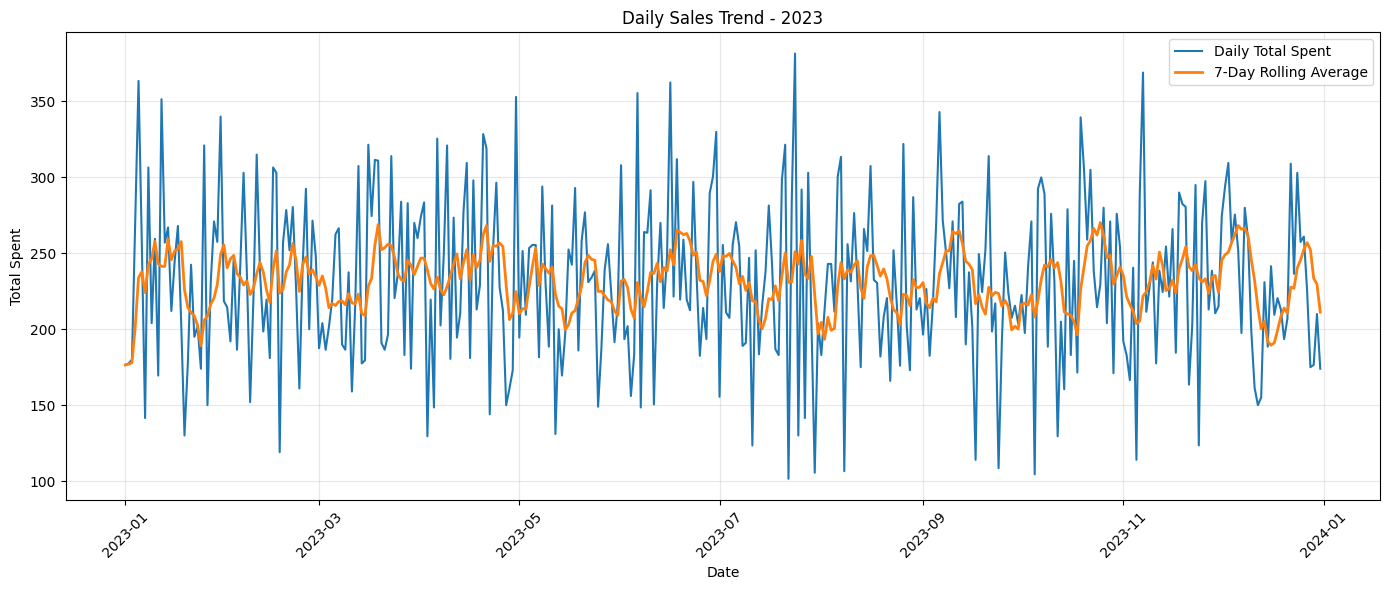

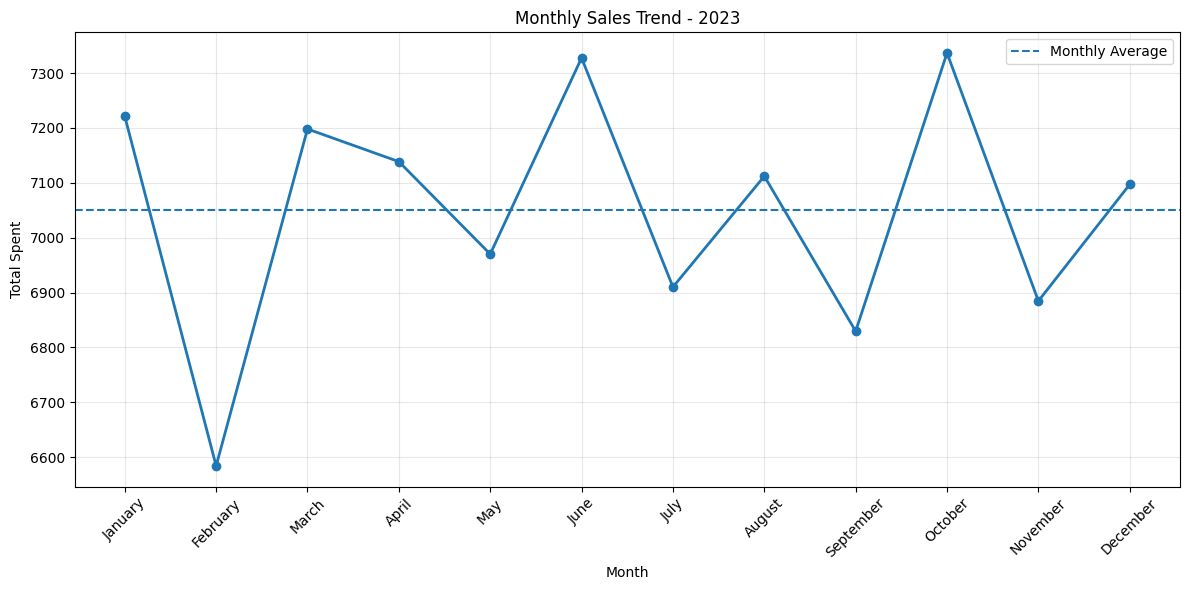

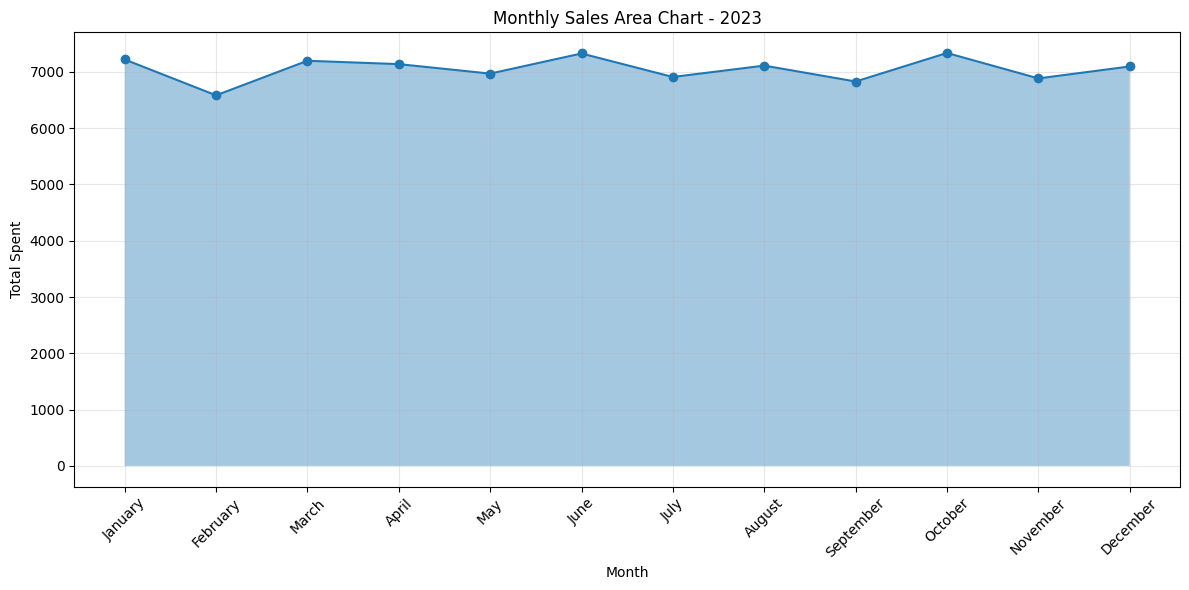

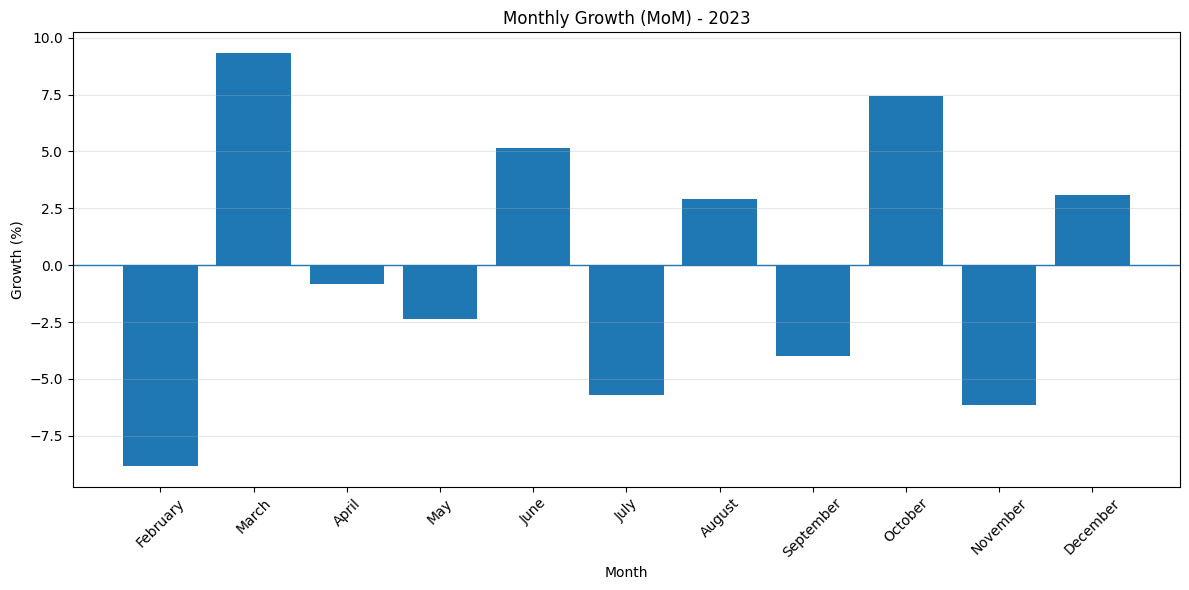


FINAL MONTHLY TREND TABLE


,Month,Transaction_Count,Total_Spent,MoM_Growth_%,Above_Monthly_Average
0,January,818,7221.0,NaN,Above Average
1,February,727,6584.0,-8.821493,Below Average
2,March,827,7198.0,9.325638,Above Average
3,April,774,7138.5,-0.826619,Above Average
4,May,777,6970.0,-2.360440,Below Average
5,June,818,7327.5,5.129125,Above Average
6,July,791,6910.0,-5.697714,Below Average
7,August,803,7112.0,2.923300,Above Average
8,September,788,6829.5,-3.972160,Below Average
9,October,838,7336.5,7.423677,Above Average



PDF BERHASIL DIBUAT
File: Trend_Analysis.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# WEEK 7 - HARI SENIN
# TREND ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from IPython.display import display
from google.colab import files

print("=" * 70)
print("WEEK 7 - HARI SENIN | TREND ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Persiapan Data
# ------------------------------------------------------------

# Pastikan tanggal menjadi datetime
df["Transaction_Date"] = pd.to_datetime(
    df["Transaction_Date"],
    errors="coerce"
)

# Pastikan Total_Spent numerik
df["Total_Spent"] = pd.to_numeric(
    df["Total_Spent"],
    errors="coerce"
)

# Cek missing tanggal
missing_date = df["Transaction_Date"].isna().sum()
valid_date = df["Transaction_Date"].notna().sum()

print(f"Total data                : {len(df):,}")
print(f"Tanggal tersedia          : {valid_date:,}")
print(f"Tanggal kosong            : {missing_date:,}")
print(f"Persentase tanggal kosong : {missing_date / len(df) * 100:.2f}%")

# ------------------------------------------------------------
# 2. Dataset untuk Analisis Temporal
# ------------------------------------------------------------

# Hanya transaksi dengan tanggal valid
df_time = df.dropna(
    subset=["Transaction_Date"]
).copy()

# Urutkan berdasarkan tanggal
df_time = df_time.sort_values("Transaction_Date")

print("\nDataset temporal:")
print(f"Jumlah transaksi          : {len(df_time):,}")
print(
    f"Periode                   : "
    f"{df_time['Transaction_Date'].min().date()} "
    f"sampai "
    f"{df_time['Transaction_Date'].max().date()}"
)

# ------------------------------------------------------------
# 3. DAILY TREND
# ------------------------------------------------------------

daily_trend = (
    df_time
    .groupby("Transaction_Date")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Spent=("Total_Spent", "sum")
    )
    .reset_index()
)

# Rolling average 7 hari
daily_trend["Rolling_7D_Total_Spent"] = (
    daily_trend["Total_Spent"]
    .rolling(window=7, min_periods=1)
    .mean()
)

print("\n" + "=" * 70)
print("DAILY TREND")
print("=" * 70)

display(daily_trend.head(10))

# ------------------------------------------------------------
# 4. MONTHLY TREND
# ------------------------------------------------------------

monthly_trend = (
    df_time
    .set_index("Transaction_Date")
    .resample("MS")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Spent=("Total_Spent", "sum")
    )
    .reset_index()
)

# Nama bulan
monthly_trend["Month"] = (
    monthly_trend["Transaction_Date"]
    .dt.strftime("%B")
)

# Pertumbuhan MoM
monthly_trend["MoM_Growth_%"] = (
    monthly_trend["Total_Spent"]
    .pct_change() * 100
)

print("\n" + "=" * 70)
print("MONTHLY TREND")
print("=" * 70)

display(
    monthly_trend[
        [
            "Month",
            "Transaction_Count",
            "Total_Spent",
            "MoM_Growth_%"
        ]
    ]
)

# ------------------------------------------------------------
# 5. ANALISIS PERTUMBUHAN
# ------------------------------------------------------------

highest_month = monthly_trend.loc[
    monthly_trend["Total_Spent"].idxmax()
]

lowest_month = monthly_trend.loc[
    monthly_trend["Total_Spent"].idxmin()
]

highest_growth = monthly_trend.loc[
    monthly_trend["MoM_Growth_%"].idxmax()
]

lowest_growth = monthly_trend.loc[
    monthly_trend["MoM_Growth_%"].idxmin()
]

jan_value = monthly_trend.iloc[0]["Total_Spent"]
dec_value = monthly_trend.iloc[-1]["Total_Spent"]

jan_dec_growth = (
    (dec_value - jan_value) / jan_value
) * 100

monthly_average = monthly_trend["Total_Spent"].mean()

monthly_trend["Above_Monthly_Average"] = np.where(
    monthly_trend["Total_Spent"] > monthly_average,
    "Above Average",
    "Below Average"
)

# ------------------------------------------------------------
# 6. PRINT HASIL ANALISIS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("HASIL ANALISIS TREND")
print("=" * 70)

print(
    f"\nBulan dengan Total_Spent tertinggi : "
    f"{highest_month['Month']} "
    f"(Rp {highest_month['Total_Spent']:,.2f})"
)

print(
    f"Bulan dengan Total_Spent terendah  : "
    f"{lowest_month['Month']} "
    f"(Rp {lowest_month['Total_Spent']:,.2f})"
)

print(
    f"\nPertumbuhan MoM tertinggi           : "
    f"{highest_growth['Month']} "
    f"({highest_growth['MoM_Growth_%']:+.2f}%)"
)

print(
    f"Pertumbuhan MoM terendah            : "
    f"{lowest_growth['Month']} "
    f"({lowest_growth['MoM_Growth_%']:+.2f}%)"
)

print(
    f"\nTotal Januari                       : "
    f"Rp {jan_value:,.2f}"
)

print(
    f"Total Desember                      : "
    f"Rp {dec_value:,.2f}"
)

print(
    f"Perubahan Januari → Desember       : "
    f"{jan_dec_growth:+.2f}%"
)

print(
    f"\nRata-rata Total_Spent bulanan       : "
    f"Rp {monthly_average:,.2f}"
)

# ------------------------------------------------------------
# 7. INSIGHT OTOMATIS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("INSIGHT TREND")
print("=" * 70)

insights = [
    (
        f"1. Total_Spent tertinggi terjadi pada "
        f"{highest_month['Month']} sebesar "
        f"Rp {highest_month['Total_Spent']:,.2f}."
    ),

    (
        f"2. Total_Spent terendah terjadi pada "
        f"{lowest_month['Month']} sebesar "
        f"Rp {lowest_month['Total_Spent']:,.2f}."
    ),

    (
        f"3. Pertumbuhan bulanan terbesar terjadi pada "
        f"{highest_growth['Month']} sebesar "
        f"{highest_growth['MoM_Growth_%']:+.2f}%."
    ),

    (
        f"4. Penurunan bulanan terbesar terjadi pada "
        f"{lowest_growth['Month']} sebesar "
        f"{lowest_growth['MoM_Growth_%']:+.2f}%."
    ),

    (
        f"5. Total_Spent Januari adalah "
        f"Rp {jan_value:,.2f}, sedangkan Desember "
        f"Rp {dec_value:,.2f}."
    ),

    (
        f"6. Perubahan Total_Spent dari Januari ke Desember "
        f"adalah {jan_dec_growth:+.2f}%."
    ),

    (
        f"7. Rata-rata Total_Spent bulanan adalah "
        f"Rp {monthly_average:,.2f}."
    ),

    (
        f"8. Pola penjualan sepanjang 2023 menunjukkan "
        f"fluktuasi antarbulan, bukan pertumbuhan yang konsisten."
    ),

    (
        f"9. Data temporal yang dapat dianalisis berjumlah "
        f"{valid_date:,} transaksi karena {missing_date:,} transaksi "
        f"tidak memiliki Transaction_Date."
    ),

    (
        f"10. Analisis ini menggambarkan pola bulanan selama 2023 "
        f"dan belum cukup untuk menyimpulkan tren jangka panjang "
        f"atau seasonality lintas tahun."
    )
]

for insight in insights:
    print(insight)

# ------------------------------------------------------------
# 8. VISUALISASI 1 - DAILY LINE CHART
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    daily_trend["Transaction_Date"],
    daily_trend["Total_Spent"],
    label="Daily Total Spent"
)

plt.plot(
    daily_trend["Transaction_Date"],
    daily_trend["Rolling_7D_Total_Spent"],
    linewidth=2,
    label="7-Day Rolling Average"
)

plt.title("Daily Sales Trend - 2023")
plt.xlabel("Date")
plt.ylabel("Total Spent")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. VISUALISASI 2 - MONTHLY LINE CHART
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_trend["Month"],
    monthly_trend["Total_Spent"],
    marker="o",
    linewidth=2
)

plt.axhline(
    monthly_average,
    linestyle="--",
    label="Monthly Average"
)

plt.title("Monthly Sales Trend - 2023")
plt.xlabel("Month")
plt.ylabel("Total Spent")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. VISUALISASI 3 - AREA CHART
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.fill_between(
    monthly_trend["Month"],
    monthly_trend["Total_Spent"],
    alpha=0.4
)

plt.plot(
    monthly_trend["Month"],
    monthly_trend["Total_Spent"],
    marker="o"
)

plt.title("Monthly Sales Area Chart - 2023")
plt.xlabel("Month")
plt.ylabel("Total Spent")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 11. VISUALISASI 4 - MOM GROWTH
# ------------------------------------------------------------

mom_plot = monthly_trend.dropna(
    subset=["MoM_Growth_%"]
)

plt.figure(figsize=(12, 6))

plt.bar(
    mom_plot["Month"],
    mom_plot["MoM_Growth_%"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Monthly Growth (MoM) - 2023")
plt.xlabel("Month")
plt.ylabel("Growth (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 12. FINAL TABLE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL MONTHLY TREND TABLE")
print("=" * 70)

final_table = monthly_trend[
    [
        "Month",
        "Transaction_Count",
        "Total_Spent",
        "MoM_Growth_%",
        "Above_Monthly_Average"
    ]
].copy()

display(final_table)

# ------------------------------------------------------------
# 13. EXPORT PDF
# ------------------------------------------------------------

pdf_filename = "Trend_Analysis.pdf"

with PdfPages(pdf_filename) as pdf:

    # COVER
    fig = plt.figure(figsize=(11.69, 8.27))
    fig.text(
        0.5,
        0.65,
        "WEEK 7 - EDA ADVANCED",
        ha="center",
        fontsize=24,
        fontweight="bold"
    )

    fig.text(
        0.5,
        0.55,
        "HARI SENIN",
        ha="center",
        fontsize=20
    )

    fig.text(
        0.5,
        0.45,
        "TREND ANALYSIS",
        ha="center",
        fontsize=28,
        fontweight="bold"
    )

    fig.text(
        0.5,
        0.32,
        "Final Clean Dataset",
        ha="center",
        fontsize=14
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # OVERVIEW
    fig = plt.figure(figsize=(11.69, 8.27))
    plt.axis("off")

    overview_text = f"""
TREND ANALYSIS - OVERVIEW

Dataset:
Final Clean Dataset.csv

Jumlah Baris:
{len(df):,}

Jumlah Kolom:
{len(df.columns)}

Periode Temporal:
2023-01-01 sampai 2023-12-31

Transaksi dengan tanggal valid:
{valid_date:,}

Transaksi tanpa tanggal:
{missing_date:,} ({missing_date / len(df) * 100:.2f}%)

Rata-rata Total_Spent bulanan:
Rp {monthly_average:,.2f}

Bulan tertinggi:
{highest_month['Month']} - Rp {highest_month['Total_Spent']:,.2f}

Bulan terendah:
{lowest_month['Month']} - Rp {lowest_month['Total_Spent']:,.2f}

Catatan:
Analisis temporal hanya menggunakan transaksi dengan
Transaction_Date yang valid. Dataset hanya mencakup
tahun 2023 sehingga interpretasi difokuskan pada
pola bulanan selama 2023.
"""

    fig.text(
        0.08,
        0.92,
        overview_text,
        fontsize=12,
        va="top",
        family="monospace"
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # DAILY TREND
    fig = plt.figure(figsize=(11.69, 8.27))

    plt.plot(
        daily_trend["Transaction_Date"],
        daily_trend["Total_Spent"],
        label="Daily Total Spent"
    )

    plt.plot(
        daily_trend["Transaction_Date"],
        daily_trend["Rolling_7D_Total_Spent"],
        linewidth=2,
        label="7-Day Rolling Average"
    )

    plt.title("Daily Sales Trend - 2023")
    plt.xlabel("Date")
    plt.ylabel("Total Spent")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()

    pdf.savefig(fig)
    plt.close(fig)

    # MONTHLY LINE
    fig = plt.figure(figsize=(11.69, 8.27))

    plt.plot(
        monthly_trend["Month"],
        monthly_trend["Total_Spent"],
        marker="o",
        linewidth=2
    )

    plt.axhline(
        monthly_average,
        linestyle="--",
        label="Monthly Average"
    )

    plt.title("Monthly Sales Trend - 2023")
    plt.xlabel("Month")
    plt.ylabel("Total Spent")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()

    pdf.savefig(fig)
    plt.close(fig)

    # AREA CHART
    fig = plt.figure(figsize=(11.69, 8.27))

    plt.fill_between(
        monthly_trend["Month"],
        monthly_trend["Total_Spent"],
        alpha=0.4
    )

    plt.plot(
        monthly_trend["Month"],
        monthly_trend["Total_Spent"],
        marker="o"
    )

    plt.title("Monthly Sales Area Chart - 2023")
    plt.xlabel("Month")
    plt.ylabel("Total Spent")
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    pdf.savefig(fig)
    plt.close(fig)

    # MOM
    fig = plt.figure(figsize=(11.69, 8.27))

    plt.bar(
        mom_plot["Month"],
        mom_plot["MoM_Growth_%"]
    )

    plt.axhline(0, linewidth=1)

    plt.title("Monthly Growth (MoM) - 2023")
    plt.xlabel("Month")
    plt.ylabel("Growth (%)")
    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    pdf.savefig(fig)
    plt.close(fig)

    # TABLE
    fig = plt.figure(figsize=(11.69, 8.27))
    plt.axis("off")

    table_data = final_table.copy()

    table_data["Total_Spent"] = table_data[
        "Total_Spent"
    ].map(lambda x: f"Rp {x:,.2f}")

    table_data["MoM_Growth_%"] = table_data[
        "MoM_Growth_%"
    ].map(
        lambda x: "-" if pd.isna(x) else f"{x:+.2f}%"
    )

    table = plt.table(
        cellText=table_data.values,
        colLabels=table_data.columns,
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)

    plt.title(
        "Monthly Trend Summary",
        fontsize=16,
        fontweight="bold",
        pad=20
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # INSIGHTS
    fig = plt.figure(figsize=(11.69, 8.27))
    plt.axis("off")

    insight_text = "TREND ANALYSIS - KEY INSIGHTS\n\n"

    insight_text += "\n".join(insights)

    insight_text += """

CONCLUSION

Pola Total_Spent selama 2023 menunjukkan fluktuasi
antarbulan. Tidak terdapat pola pertumbuhan yang
konsisten dari awal hingga akhir tahun.

Bulan dengan nilai tertinggi adalah bulan dengan
Total_Spent terbesar, sedangkan bulan dengan nilai
terendah menunjukkan periode dengan aktivitas penjualan
relatif lebih rendah.

Analisis ini dapat digunakan sebagai dasar untuk
melanjutkan analisis segmentasi, outlier, dan pola
bisnis pada hari berikutnya.
"""

    fig.text(
        0.07,
        0.94,
        insight_text,
        fontsize=11,
        va="top",
        family="monospace"
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

print("\n" + "=" * 70)
print("PDF BERHASIL DIBUAT")
print("=" * 70)

print(f"File: {pdf_filename}")

# Download PDF
files.download(pdf_filename)

WEEK 7 - HARI SELASA | SEGMENTASI DATA
File yang digunakan : Final Clean Dataset.csv
Jumlah baris        : 10,000
Jumlah kolom        : 10

Kolom segmentasi yang tersedia:
- Item
- Location
- Payment_Method

SEGMENTASI 1 — PRODUK / ITEM


,Item,Transaction_Count,Total_Quantity,Total_Spent,Average_Spent,Revenue_Share_%
5,SALAD,1148,3469.0,17021.0,14.826655,19.172219
6,SANDWICH,1131,3428.0,13484.0,11.922193,15.188191
4,JUICE,1504,4530.0,13449.0,8.942154,15.148767
7,SMOOTHIE,1096,3353.0,13132.0,11.981752,14.791703
0,CAKE,1139,3467.0,10341.0,9.079017,11.647959
1,COFFEE,1165,3551.0,7184.0,6.166524,8.091958
8,TEA,1089,3319.0,5119.5,4.701102,5.766534
2,COOKIE,1092,3249.0,3526.0,3.228938,3.971638
9,UNKNOWN,344,1006.0,2933.5,8.527616,3.304254
3,ERROR,292,899.0,2589.5,8.868151,2.916777



Produk dengan Total_Spent tertinggi : SALAD (Rp 17,021.00)
Produk dengan Total_Spent terendah  : ERROR (Rp 2,589.50)

SEGMENTASI 2 — LOKASI


,Location,Transaction_Count,Total_Quantity,Total_Spent,Average_Spent,Revenue_Share_%
2,TAKEAWAY,6287,19069.0,55645.0,8.850803,62.677758
1,IN-STORE,3017,9139.0,27090.0,8.979118,30.513801
0,ERROR,358,1100.0,3260.5,9.107542,3.672582
3,UNKNOWN,338,963.0,2784.0,8.236686,3.135859



Lokasi dengan Total_Spent tertinggi : TAKEAWAY (Rp 55,645.00)
Lokasi dengan Total_Spent terendah  : UNKNOWN (Rp 2,784.00)

SEGMENTASI 3 — PAYMENT METHOD


...

Payment_Method,CASH,CREDIT CARD,DIGITAL WALLET,ERROR,UNKNOWN
Item,,,,,
CAKE,276,253,530,41,39
COFFEE,244,242,614,36,29
COOKIE,245,253,528,35,31
ERROR,62,72,146,4,8
JUICE,340,357,717,44,46
SALAD,285,279,520,38,26
SANDWICH,253,256,564,25,33
SMOOTHIE,236,252,535,39,34
TEA,241,232,551,33,32



TOP SEGMENT COMBINATIONS

Top 10 kombinasi Produk × Lokasi:


,Item,Location,Transaction_Count,Total_Spent,Average_Spent
22,SALAD,TAKEAWAY,701,10330.0,14.736091
18,JUICE,TAKEAWAY,952,8621.5,9.056197
30,SMOOTHIE,TAKEAWAY,688,8408.0,12.220930
26,SANDWICH,TAKEAWAY,683,8108.0,11.871157
2,CAKE,TAKEAWAY,715,6474.0,9.054545
21,SALAD,IN-STORE,371,5565.0,15.000000
6,COFFEE,TAKEAWAY,766,4758.0,6.211488
25,SANDWICH,IN-STORE,370,4456.0,12.043243
17,JUICE,IN-STORE,470,4154.0,8.838298
29,SMOOTHIE,IN-STORE,322,3720.0,11.552795



Top 10 kombinasi Produk × Payment Method:


,Item,Payment_Method,Transaction_Count,Total_Spent,Average_Spent
27,SALAD,DIGITAL WALLET,520,7886.0,15.165385
32,SANDWICH,DIGITAL WALLET,564,6764.0,11.992908
22,JUICE,DIGITAL WALLET,717,6414.5,8.946304
37,SMOOTHIE,DIGITAL WALLET,535,6324.0,11.820561
2,CAKE,DIGITAL WALLET,530,4792.0,9.041509
25,SALAD,CASH,285,4163.0,14.607018
26,SALAD,CREDIT CARD,279,4110.0,14.731183
7,COFFEE,DIGITAL WALLET,614,3802.0,6.192182
21,JUICE,CREDIT CARD,357,3274.0,9.170868
30,SANDWICH,CASH,253,3096.0,12.237154


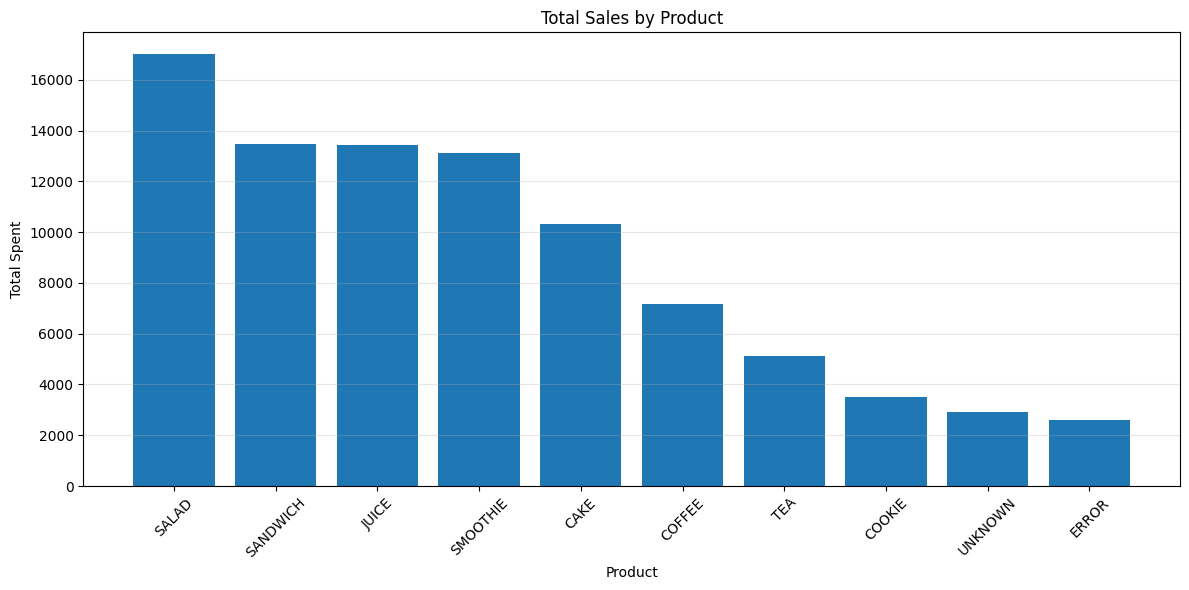

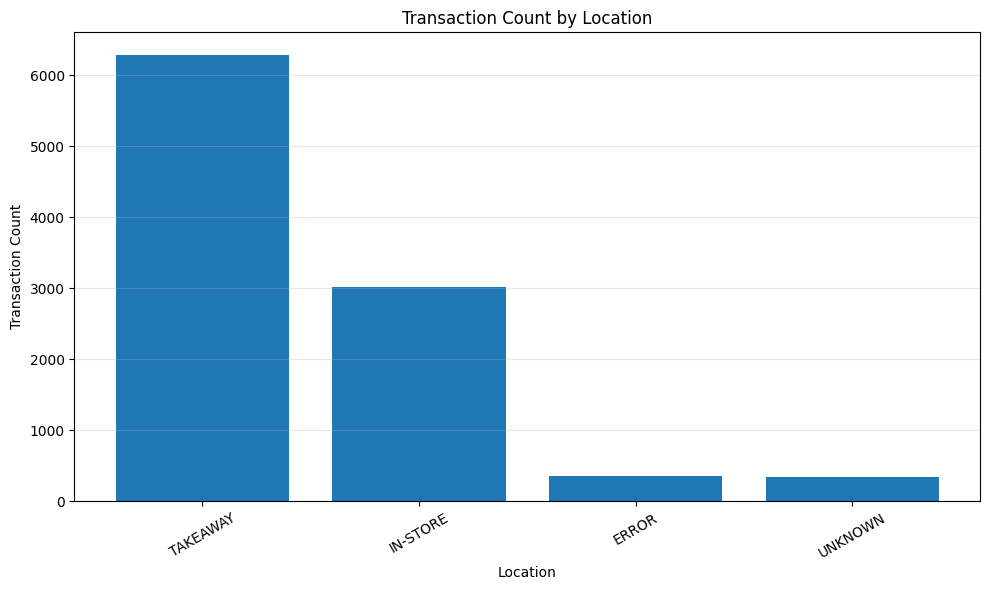

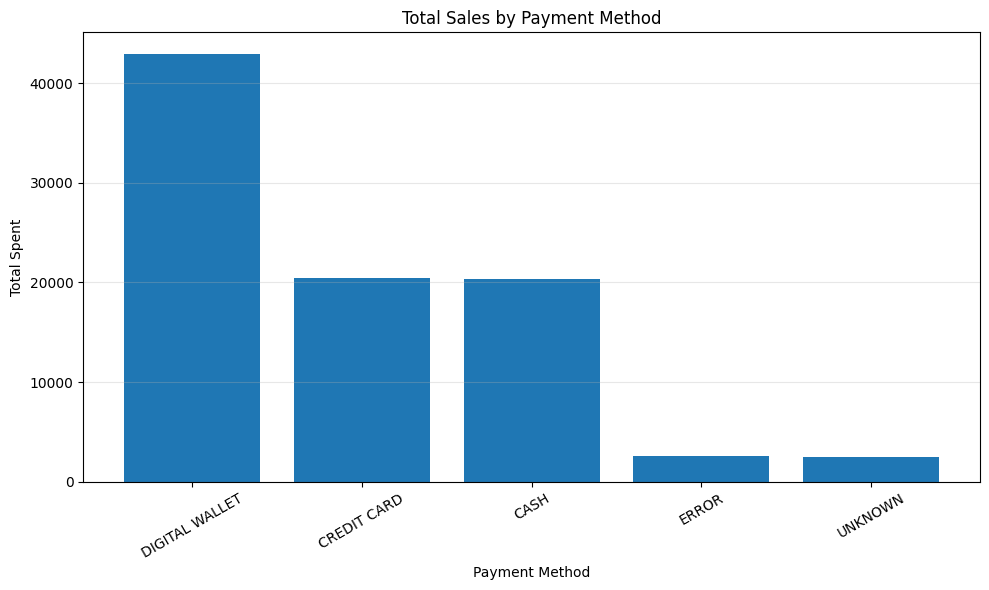

<Figure size 1400x700 with 0 Axes>

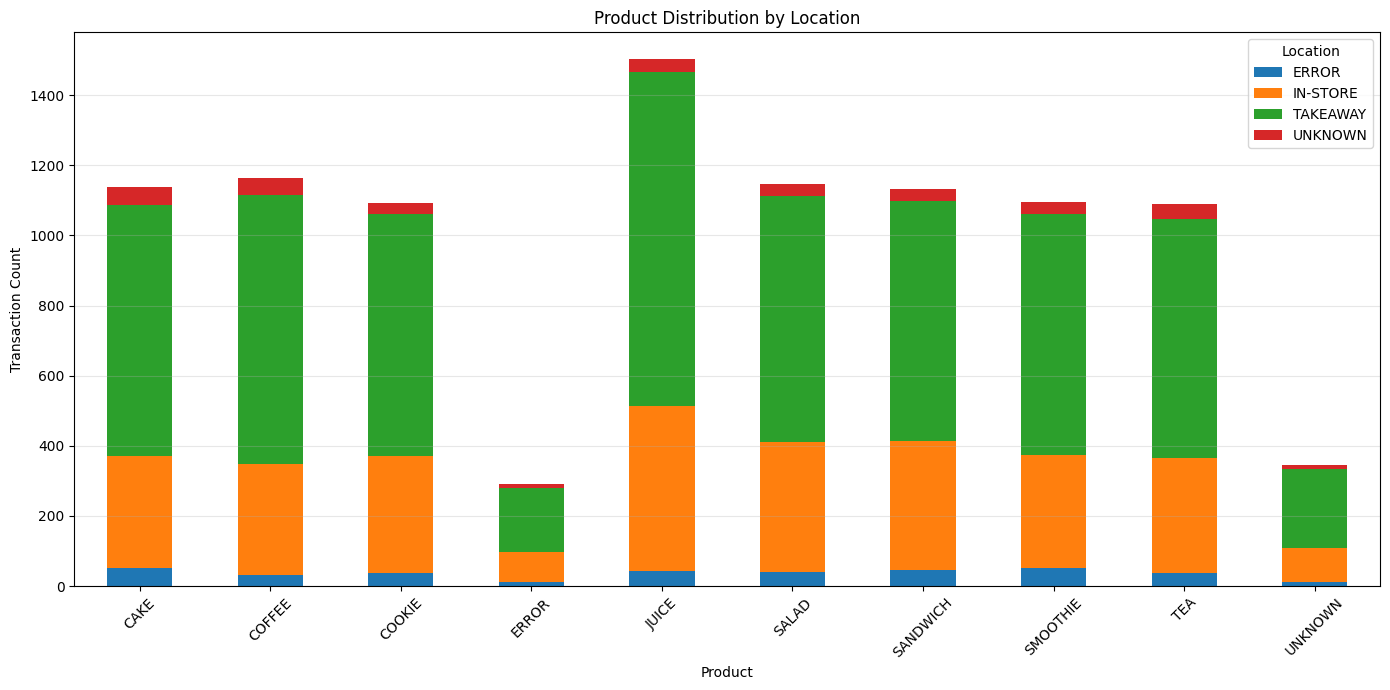

<Figure size 1400x700 with 0 Axes>

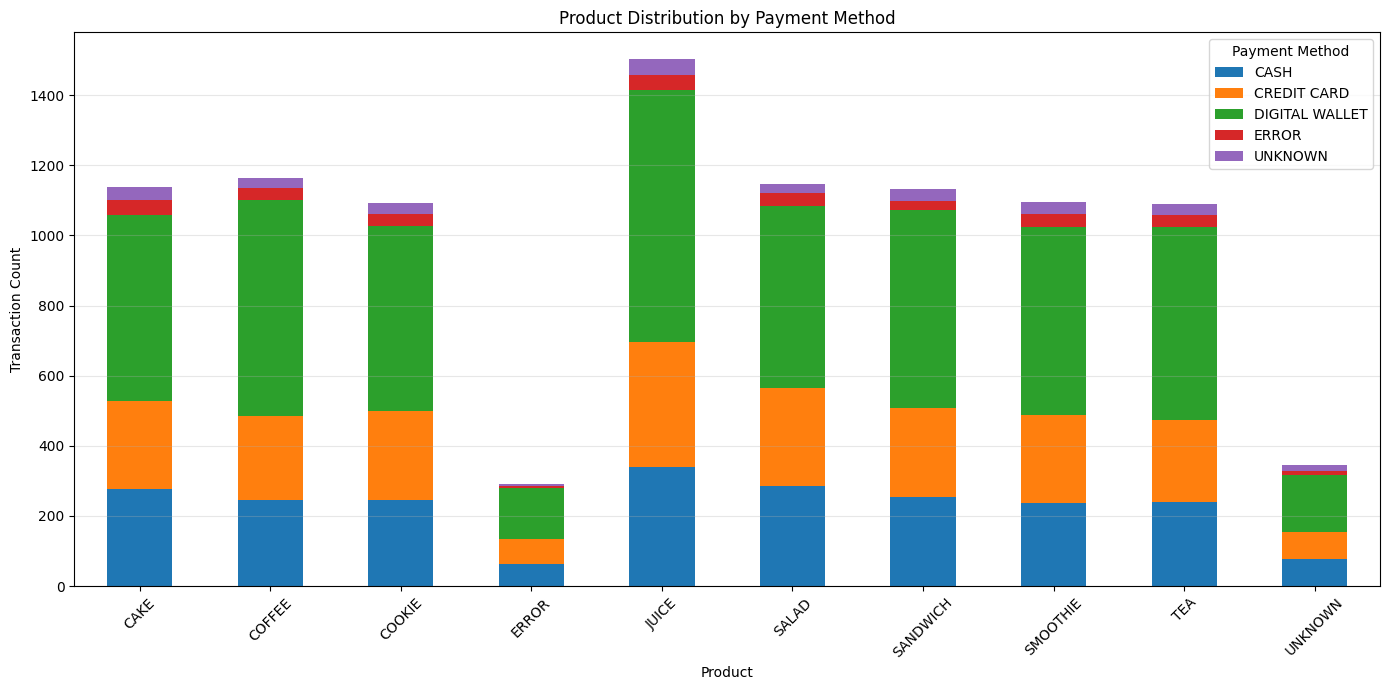

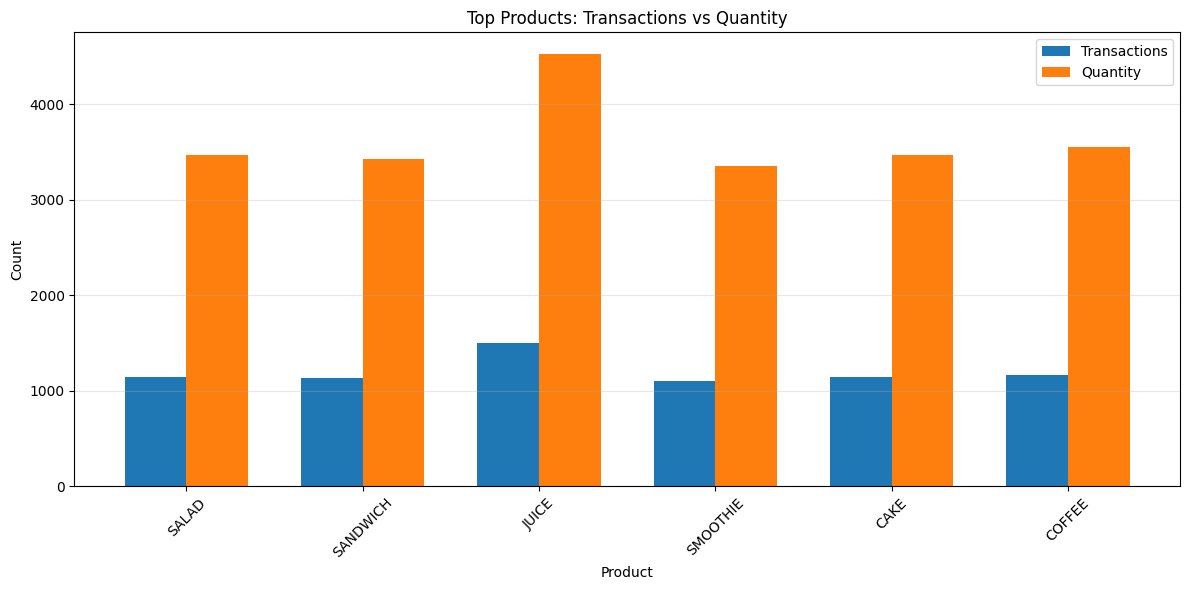

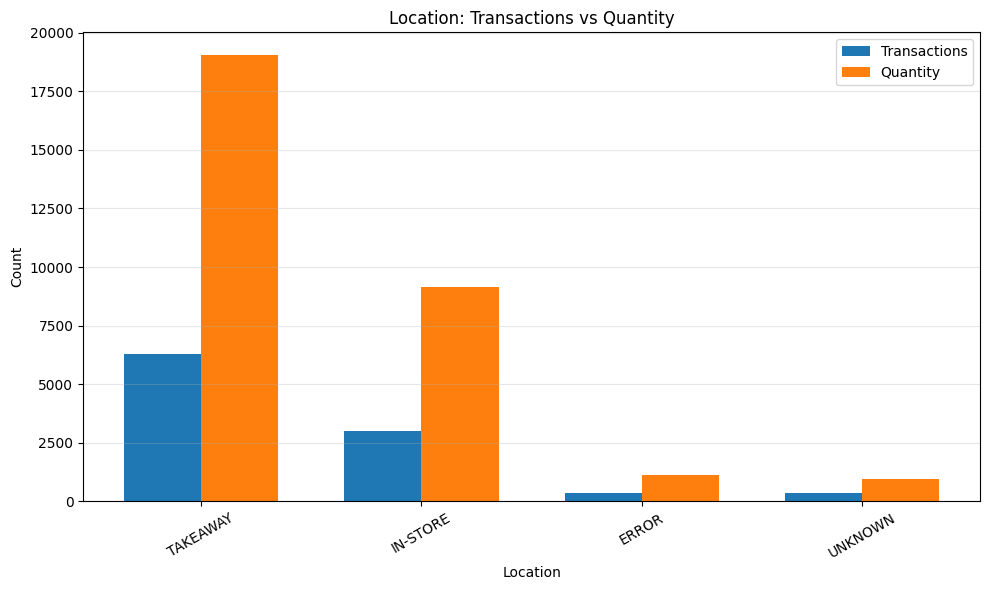


DATA QUALITY SEGMENT
Item_UNKNOWN        : 344
Item_ERROR          : 292
Payment_UNKNOWN     : 293
Payment_ERROR       : 306
Location_UNKNOWN    : 338
Location_ERROR      : 358

INSIGHT SEGMENTASI
1. Produk dengan Total_Spent terbesar adalah SALAD dengan nilai Rp 17,021.00.
2. Produk SALAD menyumbang sekitar 19.17% dari total Total_Spent.
3. Lokasi dengan Total_Spent terbesar adalah TAKEAWAY dengan nilai Rp 55,645.00.
4. Lokasi TAKEAWAY menyumbang sekitar 62.68% dari total Total_Spent.
5. Payment method dengan Total_Spent terbesar adalah DIGITAL WALLET dengan nilai Rp 42,948.00.
6. Payment method DIGITAL WALLET menyumbang sekitar 48.38% dari total Total_Spent.
7. Kombinasi Produk × Lokasi dengan Total_Spent terbesar adalah SALAD × TAKEAWAY sebesar Rp 10,330.00.
8. Kombinasi Produk × Payment Method dengan Total_Spent terbesar adalah SALAD × DIGITAL WALLET sebesar Rp 7,886.00.
9. Segmentasi menunjukkan bahwa performa penjualan tidak merata antarproduk, lokasi, maupun metode pembayaran.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# WEEK 7 - HARI SELASA
# SEGMENTASI DATA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from IPython.display import display
from google.colab import files

print("=" * 70)
print("WEEK 7 - HARI SELASA | SEGMENTASI DATA")
print("=" * 70)

# ============================================================
# 1. LOAD DATASET
# ============================================================

# Jika df dari hari Senin masih tersedia, gunakan df.
# Jika tidak, cari file CSV di folder Colab.

if "df" not in globals():

    import glob

    csv_files = glob.glob("*.csv")

    if not csv_files:
        print("File CSV belum ditemukan.")
        print("Silakan upload Final Clean Dataset.csv")

        uploaded = files.upload()

        csv_files = [
            filename
            for filename in uploaded.keys()
            if filename.lower().endswith(".csv")
        ]

        if not csv_files:
            raise FileNotFoundError(
                "Tidak ada file CSV yang berhasil di-upload."
            )

    file_path = csv_files[0]

    df = pd.read_csv(file_path)

else:
    file_path = "Final Clean Dataset.csv"

print(f"File yang digunakan : {file_path}")
print(f"Jumlah baris        : {len(df):,}")
print(f"Jumlah kolom        : {len(df.columns)}")

# ============================================================
# 2. DATA PREPARATION
# ============================================================

df["Total_Spent"] = pd.to_numeric(
    df["Total_Spent"],
    errors="coerce"
)

df["Quantity"] = pd.to_numeric(
    df["Quantity"],
    errors="coerce"
)

# Kolom yang digunakan
segment_columns = [
    "Item",
    "Location",
    "Payment_Method"
]

print("\nKolom segmentasi yang tersedia:")
for col in segment_columns:
    print(f"- {col}")

# ============================================================
# 3. SEGMENTASI 1 — PRODUK / ITEM
# ============================================================

print("\n" + "=" * 70)
print("SEGMENTASI 1 — PRODUK / ITEM")
print("=" * 70)

item_segment = (
    df.groupby("Item")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Quantity=("Quantity", "sum"),
        Total_Spent=("Total_Spent", "sum"),
        Average_Spent=("Total_Spent", "mean")
    )
    .reset_index()
    .sort_values("Total_Spent", ascending=False)
)

item_segment["Revenue_Share_%"] = (
    item_segment["Total_Spent"]
    / item_segment["Total_Spent"].sum()
    * 100
)

display(item_segment)

# Produk tertinggi dan terendah
top_item = item_segment.iloc[0]
bottom_item = item_segment.iloc[-1]

print(
    f"\nProduk dengan Total_Spent tertinggi : "
    f"{top_item['Item']} "
    f"(Rp {top_item['Total_Spent']:,.2f})"
)

print(
    f"Produk dengan Total_Spent terendah  : "
    f"{bottom_item['Item']} "
    f"(Rp {bottom_item['Total_Spent']:,.2f})"
)

# ============================================================
# 4. SEGMENTASI 2 — LOKASI
# ============================================================

print("\n" + "=" * 70)
print("SEGMENTASI 2 — LOKASI")
print("=" * 70)

location_segment = (
    df.groupby("Location")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Quantity=("Quantity", "sum"),
        Total_Spent=("Total_Spent", "sum"),
        Average_Spent=("Total_Spent", "mean")
    )
    .reset_index()
    .sort_values("Total_Spent", ascending=False)
)

location_segment["Revenue_Share_%"] = (
    location_segment["Total_Spent"]
    / location_segment["Total_Spent"].sum()
    * 100
)

display(location_segment)

top_location = location_segment.iloc[0]
bottom_location = location_segment.iloc[-1]

print(
    f"\nLokasi dengan Total_Spent tertinggi : "
    f"{top_location['Location']} "
    f"(Rp {top_location['Total_Spent']:,.2f})"
)

print(
    f"Lokasi dengan Total_Spent terendah  : "
    f"{bottom_location['Location']} "
    f"(Rp {bottom_location['Total_Spent']:,.2f})"
)

# ============================================================
# 5. SEGMENTASI 3 — PAYMENT METHOD
# ============================================================

print("\n" + "=" * 70)
print("SEGMENTASI 3 — PAYMENT METHOD")
print("=" * 70)

payment_segment = (
    df.groupby("Payment_Method")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Quantity=("Quantity", "sum"),
        Total_Spent=("Total_Spent", "sum"),
        Average_Spent=("Total_Spent", "mean")
    )
    .reset_index()
    .sort_values("Total_Spent", ascending=False)
)

payment_segment["Revenue_Share_%"] = (
    payment_segment["Total_Spent"]
    / payment_segment["Total_Spent"].sum()
    * 100
)

display(payment_segment)

top_payment = payment_segment.iloc[0]
bottom_payment = payment_segment.iloc[-1]

print(
    f"\nPayment method dengan Total_Spent tertinggi : "
    f"{top_payment['Payment_Method']} "
    f"(Rp {top_payment['Total_Spent']:,.2f})"
)

print(
    f"Payment method dengan Total_Spent terendah  : "
    f"{bottom_payment['Payment_Method']} "
    f"(Rp {bottom_payment['Total_Spent']:,.2f})"
)

# ============================================================
# 6. SEGMENTASI 4 — PRODUK × LOKASI
# ============================================================

print("\n" + "=" * 70)
print("SEGMENTASI 4 — PRODUK × LOKASI")
print("=" * 70)

item_location = pd.pivot_table(
    df,
    index="Item",
    columns="Location",
    values="Transaction_ID",
    aggfunc="count",
    fill_value=0
)

display(item_location)

# ============================================================
# 7. SEGMENTASI 5 — PRODUK × PAYMENT METHOD
# ============================================================

print("\n" + "=" * 70)
print("SEGMENTASI 5 — PRODUK × PAYMENT METHOD")
print("=" * 70)

item_payment = pd.pivot_table(
    df,
    index="Item",
    columns="Payment_Method",
    values="Transaction_ID",
    aggfunc="count",
    fill_value=0
)

display(item_payment)

# ============================================================
# 8. TOP COMBINATIONS
# ============================================================

print("\n" + "=" * 70)
print("TOP SEGMENT COMBINATIONS")
print("=" * 70)

item_location_revenue = (
    df.groupby(["Item", "Location"])
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Spent=("Total_Spent", "sum"),
        Average_Spent=("Total_Spent", "mean")
    )
    .reset_index()
    .sort_values("Total_Spent", ascending=False)
)

print("\nTop 10 kombinasi Produk × Lokasi:")
display(item_location_revenue.head(10))

item_payment_revenue = (
    df.groupby(["Item", "Payment_Method"])
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Spent=("Total_Spent", "sum"),
        Average_Spent=("Total_Spent", "mean")
    )
    .reset_index()
    .sort_values("Total_Spent", ascending=False)
)

print("\nTop 10 kombinasi Produk × Payment Method:")
display(item_payment_revenue.head(10))

# ============================================================
# 9. VISUALISASI 1 — TOTAL SPENT PER PRODUK
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    item_segment["Item"],
    item_segment["Total_Spent"]
)

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Spent")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 10. VISUALISASI 2 — TRANSACTION COUNT PER LOKASI
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    location_segment["Location"],
    location_segment["Transaction_Count"]
)

plt.title("Transaction Count by Location")
plt.xlabel("Location")
plt.ylabel("Transaction Count")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 11. VISUALISASI 3 — PAYMENT METHOD
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    payment_segment["Payment_Method"],
    payment_segment["Total_Spent"]
)

plt.title("Total Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Spent")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 12. VISUALISASI 4 — STACKED BAR
# PRODUK × LOKASI
# ============================================================

plt.figure(figsize=(14, 7))

item_location.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title("Product Distribution by Location")
plt.xlabel("Product")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.legend(title="Location")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 13. VISUALISASI 5 — STACKED BAR
# PRODUK × PAYMENT METHOD
# ============================================================

plt.figure(figsize=(14, 7))

item_payment.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title("Product Distribution by Payment Method")
plt.xlabel("Product")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.legend(title="Payment Method")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 14. VISUALISASI 6 — CLUSTERED BAR
# TOP PRODUCTS
# ============================================================

top_products = item_segment.head(6)

x = np.arange(len(top_products))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    top_products["Transaction_Count"],
    width,
    label="Transactions"
)

plt.bar(
    x + width / 2,
    top_products["Total_Quantity"],
    width,
    label="Quantity"
)

plt.xticks(
    x,
    top_products["Item"],
    rotation=45
)

plt.title("Top Products: Transactions vs Quantity")
plt.xlabel("Product")
plt.ylabel("Count")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 15. VISUALISASI 7 — CLUSTERED BAR
# LOCATION
# ============================================================

x = np.arange(len(location_segment))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    location_segment["Transaction_Count"],
    width,
    label="Transactions"
)

plt.bar(
    x + width / 2,
    location_segment["Total_Quantity"],
    width,
    label="Quantity"
)

plt.xticks(
    x,
    location_segment["Location"],
    rotation=30
)

plt.title("Location: Transactions vs Quantity")
plt.xlabel("Location")
plt.ylabel("Count")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 16. DATA QUALITY SEGMENTATION
# ============================================================

print("\n" + "=" * 70)
print("DATA QUALITY SEGMENT")
print("=" * 70)

quality_summary = {
    "Item_UNKNOWN": (df["Item"] == "UNKNOWN").sum(),
    "Item_ERROR": (df["Item"] == "ERROR").sum(),
    "Payment_UNKNOWN": (df["Payment_Method"] == "UNKNOWN").sum(),
    "Payment_ERROR": (df["Payment_Method"] == "ERROR").sum(),
    "Location_UNKNOWN": (df["Location"] == "UNKNOWN").sum(),
    "Location_ERROR": (df["Location"] == "ERROR").sum()
}

for key, value in quality_summary.items():
    print(f"{key:<20}: {value:,}")

# ============================================================
# 17. INSIGHT
# ============================================================

print("\n" + "=" * 70)
print("INSIGHT SEGMENTASI")
print("=" * 70)

total_sales = df["Total_Spent"].sum()

top_item_share = (
    top_item["Total_Spent"] / total_sales * 100
)

top_location_share = (
    top_location["Total_Spent"] / total_sales * 100
)

top_payment_share = (
    top_payment["Total_Spent"] / total_sales * 100
)

# Cari kombinasi produk-lokasi terbesar
top_item_location = item_location_revenue.iloc[0]

# Cari kombinasi produk-payment terbesar
top_item_payment = item_payment_revenue.iloc[0]

insights = [

    (
        f"1. Produk dengan Total_Spent terbesar adalah "
        f"{top_item['Item']} dengan nilai "
        f"Rp {top_item['Total_Spent']:,.2f}."
    ),

    (
        f"2. Produk {top_item['Item']} menyumbang sekitar "
        f"{top_item_share:.2f}% dari total Total_Spent."
    ),

    (
        f"3. Lokasi dengan Total_Spent terbesar adalah "
        f"{top_location['Location']} dengan nilai "
        f"Rp {top_location['Total_Spent']:,.2f}."
    ),

    (
        f"4. Lokasi {top_location['Location']} menyumbang sekitar "
        f"{top_location_share:.2f}% dari total Total_Spent."
    ),

    (
        f"5. Payment method dengan Total_Spent terbesar adalah "
        f"{top_payment['Payment_Method']} dengan nilai "
        f"Rp {top_payment['Total_Spent']:,.2f}."
    ),

    (
        f"6. Payment method {top_payment['Payment_Method']} "
        f"menyumbang sekitar {top_payment_share:.2f}% "
        f"dari total Total_Spent."
    ),

    (
        f"7. Kombinasi Produk × Lokasi dengan Total_Spent "
        f"terbesar adalah {top_item_location['Item']} × "
        f"{top_item_location['Location']} sebesar "
        f"Rp {top_item_location['Total_Spent']:,.2f}."
    ),

    (
        f"8. Kombinasi Produk × Payment Method dengan "
        f"Total_Spent terbesar adalah "
        f"{top_item_payment['Item']} × "
        f"{top_item_payment['Payment_Method']} sebesar "
        f"Rp {top_item_payment['Total_Spent']:,.2f}."
    ),

    (
        f"9. Segmentasi menunjukkan bahwa performa penjualan "
        f"tidak merata antarproduk, lokasi, maupun metode pembayaran."
    ),

    (
        f"10. Nilai UNKNOWN dan ERROR perlu diperlakukan sebagai "
        f"masalah kualitas data, bukan sebagai segmen bisnis."
    )
]

for insight in insights:
    print(insight)

# ============================================================
# 18. BUSINESS OBSERVATION
# ============================================================

print("\n" + "=" * 70)
print("BUSINESS OBSERVATION")
print("=" * 70)

print("""
1. Produk dengan kontribusi penjualan tinggi dapat menjadi
   prioritas dalam pengelolaan stok dan promosi.

2. Lokasi dengan aktivitas transaksi tinggi dapat menjadi
   fokus utama untuk evaluasi operasional.

3. Payment method dengan penggunaan tinggi dapat menjadi
   prioritas dalam menjaga kualitas layanan pembayaran.

4. Kombinasi produk dan lokasi dapat membantu menentukan
   produk yang paling relevan pada channel tertentu.

5. Data UNKNOWN dan ERROR perlu diperbaiki pada proses
   pencatatan transaksi agar segmentasi bisnis lebih akurat.
""")

# ============================================================
# 19. EXPORT PDF
# ============================================================

pdf_filename = "Segment_Analysis.pdf"

with PdfPages(pdf_filename) as pdf:

    # --------------------------------------------------------
    # COVER
    # --------------------------------------------------------

    fig = plt.figure(figsize=(11.69, 8.27))
    fig.text(
        0.5,
        0.65,
        "WEEK 7 - EDA ADVANCED",
        ha="center",
        fontsize=24,
        fontweight="bold"
    )

    fig.text(
        0.5,
        0.55,
        "HARI SELASA",
        ha="center",
        fontsize=20
    )

    fig.text(
        0.5,
        0.45,
        "SEGMENTASI DATA",
        ha="center",
        fontsize=28,
        fontweight="bold"
    )

    fig.text(
        0.5,
        0.32,
        "Final Clean Dataset",
        ha="center",
        fontsize=14
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # --------------------------------------------------------
    # OVERVIEW
    # --------------------------------------------------------

    fig = plt.figure(figsize=(11.69, 8.27))
    plt.axis("off")

    overview = f"""
SEGMENT ANALYSIS - OVERVIEW

Dataset:
Final Clean Dataset.csv

Jumlah transaksi:
{len(df):,}

Jumlah kolom:
{len(df.columns)}

Segmentasi utama:
1. Produk / Item
2. Location
3. Payment Method
4. Produk × Location
5. Produk × Payment Method

Total transaksi:
{len(df):,}

Total sales:
Rp {total_sales:,.2f}

Catatan:
UNKNOWN dan ERROR dipertahankan sebagai indikator
data quality dan tidak dianggap sebagai kategori
bisnis yang valid.
"""

    fig.text(
        0.08,
        0.92,
        overview,
        fontsize=12,
        va="top",
        family="monospace"
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # --------------------------------------------------------
    # PRODUCT CHART
    # --------------------------------------------------------

    fig = plt.figure(figsize=(11.69, 8.27))

    plt.bar(
        item_segment["Item"],
        item_segment["Total_Spent"]
    )

    plt.title("Total Sales by Product")
    plt.xlabel("Product")
    plt.ylabel("Total Spent")
    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    pdf.savefig(fig)
    plt.close(fig)

    # --------------------------------------------------------
    # LOCATION CHART
    # --------------------------------------------------------

    fig = plt.figure(figsize=(11.69, 8.27))

    plt.bar(
        location_segment["Location"],
        location_segment["Transaction_Count"]
    )

    plt.title("Transaction Count by Location")
    plt.xlabel("Location")
    plt.ylabel("Transaction Count")
    plt.xticks(rotation=30)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    pdf.savefig(fig)
    plt.close(fig)

    # --------------------------------------------------------
    # PAYMENT METHOD
    # --------------------------------------------------------

    fig = plt.figure(figsize=(11.69, 8.27))

    plt.bar(
        payment_segment["Payment_Method"],
        payment_segment["Total_Spent"]
    )

    plt.title("Total Sales by Payment Method")
    plt.xlabel("Payment Method")
    plt.ylabel("Total Spent")
    plt.xticks(rotation=30)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    pdf.savefig(fig)
    plt.close(fig)

    # --------------------------------------------------------
    # STACKED BAR PRODUCT × LOCATION
    # --------------------------------------------------------

    fig = plt.figure(figsize=(11.69, 8.27))

    item_location.plot(
        kind="bar",
        stacked=True,
        ax=plt.gca(),
        figsize=(11.69, 8.27)
    )

    plt.title("Product Distribution by Location")
    plt.xlabel("Product")
    plt.ylabel("Transaction Count")
    plt.xticks(rotation=45)
    plt.legend(title="Location")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    pdf.savefig(fig)
    plt.close(fig)

    # --------------------------------------------------------
    # STACKED BAR PRODUCT × PAYMENT
    # --------------------------------------------------------

    fig = plt.figure(figsize=(11.69, 8.27))

    item_payment.plot(
        kind="bar",
        stacked=True,
        ax=plt.gca(),
        figsize=(11.69, 8.27)
    )

    plt.title("Product Distribution by Payment Method")
    plt.xlabel("Product")
    plt.ylabel("Transaction Count")
    plt.xticks(rotation=45)
    plt.legend(title="Payment Method")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    pdf.savefig(fig)
    plt.close(fig)

    # --------------------------------------------------------
    # CLUSTERED BAR PRODUCTS
    # --------------------------------------------------------

    fig = plt.figure(figsize=(11.69, 8.27))

    x = np.arange(len(top_products))
    width = 0.35

    plt.bar(
        x - width / 2,
        top_products["Transaction_Count"],
        width,
        label="Transactions"
    )

    plt.bar(
        x + width / 2,
        top_products["Total_Quantity"],
        width,
        label="Quantity"
    )

    plt.xticks(
        x,
        top_products["Item"],
        rotation=45
    )

    plt.title("Top Products: Transactions vs Quantity")
    plt.xlabel("Product")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    pdf.savefig(fig)
    plt.close(fig)

    # --------------------------------------------------------
    # TABLE PRODUCT
    # --------------------------------------------------------

    fig = plt.figure(figsize=(11.69, 8.27))
    plt.axis("off")

    table_product = item_segment.copy()

    table_product["Total_Spent"] = (
        table_product["Total_Spent"]
        .map(lambda x: f"Rp {x:,.2f}")
    )

    table_product["Average_Spent"] = (
        table_product["Average_Spent"]
        .map(lambda x: f"Rp {x:,.2f}")
    )

    table_product["Revenue_Share_%"] = (
        table_product["Revenue_Share_%"]
        .map(lambda x: f"{x:.2f}%")
    )

    table_product = table_product[
        [
            "Item",
            "Transaction_Count",
            "Total_Quantity",
            "Total_Spent",
            "Average_Spent",
            "Revenue_Share_%"
        ]
    ]

    table = plt.table(
        cellText=table_product.values,
        colLabels=table_product.columns,
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.8)

    plt.title(
        "Product Segment Summary",
        fontsize=16,
        fontweight="bold",
        pad=20
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # --------------------------------------------------------
    # INSIGHTS
    # --------------------------------------------------------

    fig = plt.figure(figsize=(11.69, 8.27))
    plt.axis("off")

    insight_text = "SEGMENT ANALYSIS - KEY INSIGHTS\n\n"
    insight_text += "\n".join(insights)

    fig.text(
        0.07,
        0.94,
        insight_text,
        fontsize=11,
        va="top",
        family="monospace"
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # --------------------------------------------------------
    # CONCLUSION
    # --------------------------------------------------------

    fig = plt.figure(figsize=(11.69, 8.27))
    plt.axis("off")

    conclusion = """
CONCLUSION

Segmentasi data menunjukkan bahwa performa transaksi
berbeda antarproduk, lokasi, dan metode pembayaran.

Analisis Produk × Lokasi serta Produk × Payment Method
memberikan gambaran lebih detail mengenai distribusi
transaksi pada setiap kombinasi segmen.

Segmen dengan kontribusi tinggi dapat menjadi prioritas
untuk pengelolaan stok, evaluasi operasional, dan strategi
promosi.

Namun, nilai UNKNOWN dan ERROR menunjukkan masih terdapat
masalah kualitas data yang perlu diperbaiki agar analisis
bisnis berikutnya menjadi lebih akurat.
"""

    fig.text(
        0.08,
        0.90,
        conclusion,
        fontsize=13,
        va="top",
        family="monospace"
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

print("\n" + "=" * 70)
print("SEGMENT ANALYSIS SELESAI")
print("=" * 70)

print(f"PDF berhasil dibuat : {pdf_filename}")

# Download PDF
files.download(pdf_filename)

WEEK 7 - HARI RABU | OUTLIER & PATTERN ANALYSIS
File yang digunakan : Final Clean Dataset.csv
Jumlah baris        : 10,000
Jumlah kolom        : 10

Variabel numerik yang dianalisis:
- Quantity
- Price_Per_Unit
- Total_Spent

DISTRIBUTION SUMMARY


,Variable,Count,Mean,Median,Std,Min,Q1,Q3,Max
0,Quantity,10000,3.02710,3.0,1.384614,1.0,2.0,4.0,5.0
1,Price_Per_Unit,10000,2.95265,3.0,1.243960,1.0,2.0,4.0,5.0
2,Total_Spent,10000,8.87795,8.0,5.860590,1.0,4.0,12.0,25.0



OUTLIER DETECTION — IQR METHOD


,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_%
0,Quantity,2.0,4.0,2.0,-1.0,7.0,0,0.00
1,Price_Per_Unit,2.0,4.0,2.0,-1.0,7.0,0,0.00
2,Total_Spent,4.0,12.0,8.0,-8.0,24.0,259,2.59



OUTLIER DETAIL

Quantity
--------------------------------------------------
Tidak ditemukan outlier berdasarkan metode IQR.

Price_Per_Unit
--------------------------------------------------
Tidak ditemukan outlier berdasarkan metode IQR.

Total_Spent
--------------------------------------------------


,Transaction_ID,Item,Quantity,Price_Per_Unit,Total_Spent,Payment_Method,Location,Transaction_Date
9971,TXN_6120851,SALAD,5.0,5.0,25.0,CASH,TAKEAWAY,2023-02-04
10,TXN_2548360,SALAD,5.0,5.0,25.0,CASH,TAKEAWAY,2023-11-07
51,TXN_6342161,SALAD,5.0,5.0,25.0,ERROR,TAKEAWAY,2023-01-08
9352,TXN_1373048,SALAD,5.0,5.0,25.0,DIGITAL WALLET,IN-STORE,2023-08-31
9298,TXN_8740501,SALAD,5.0,5.0,25.0,DIGITAL WALLET,TAKEAWAY,2023-02-05
9291,TXN_3550177,SALAD,5.0,5.0,25.0,CASH,TAKEAWAY,2023-09-13
9282,TXN_1749930,SALAD,5.0,5.0,25.0,UNKNOWN,IN-STORE,2023-07-01
9172,TXN_4346813,SALAD,5.0,5.0,25.0,DIGITAL WALLET,ERROR,2023-07-07
9163,TXN_7172693,JUICE,5.0,5.0,25.0,CREDIT CARD,IN-STORE,2023-03-23
9148,TXN_4127927,SALAD,5.0,5.0,25.0,DIGITAL WALLET,TAKEAWAY,2023-08-04



BOXPLOT


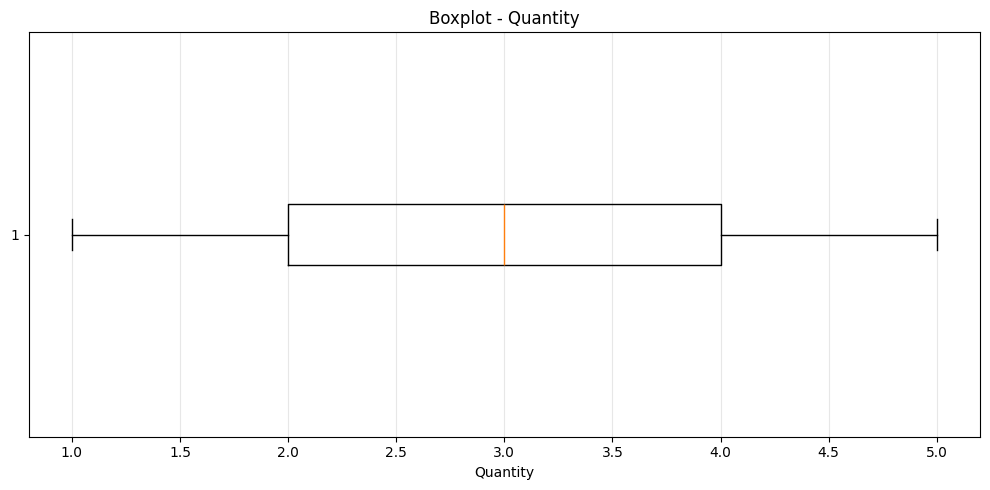

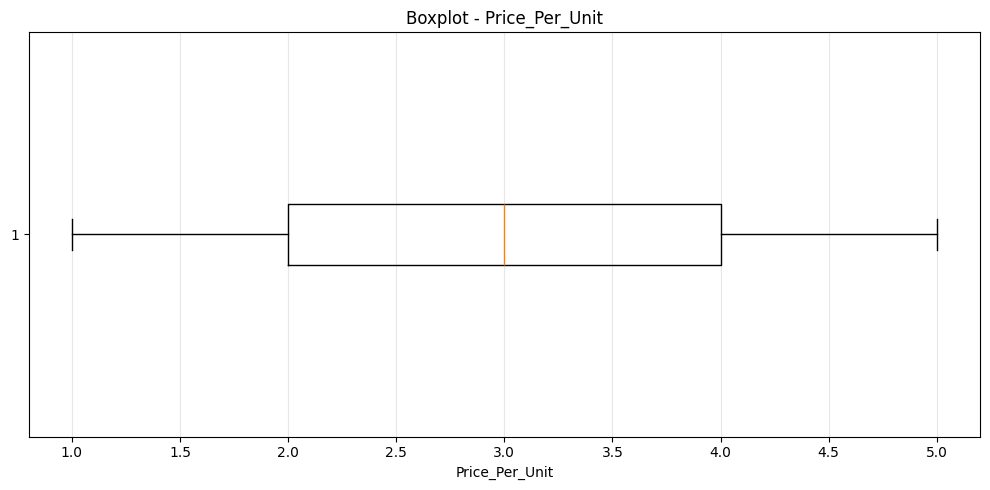

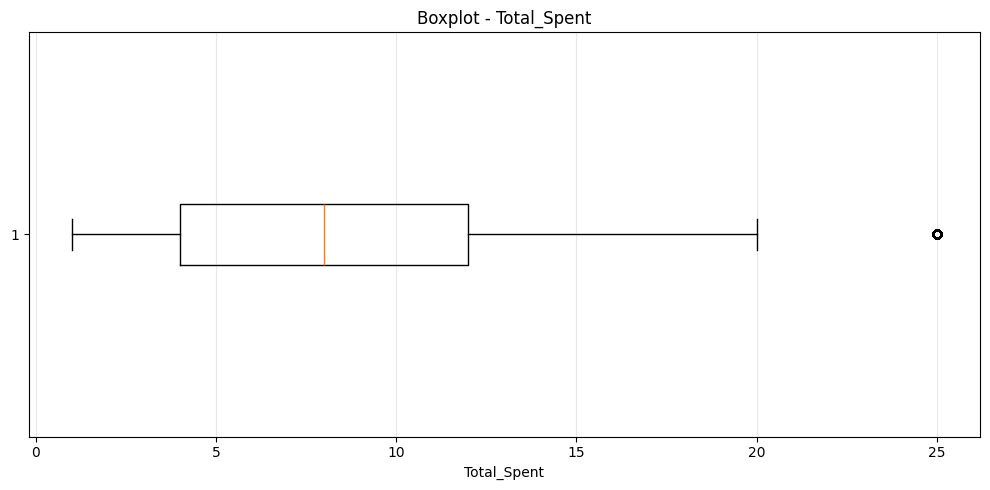


DISTRIBUTION PLOTS


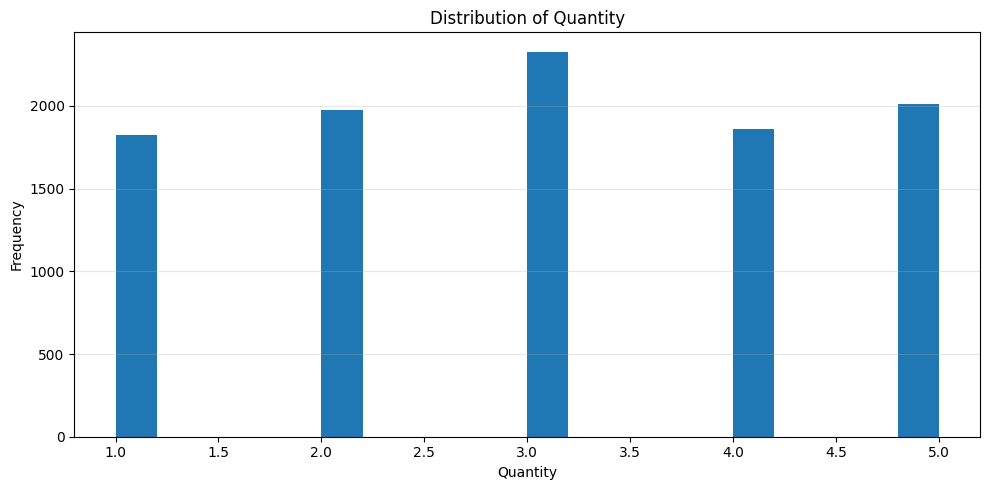

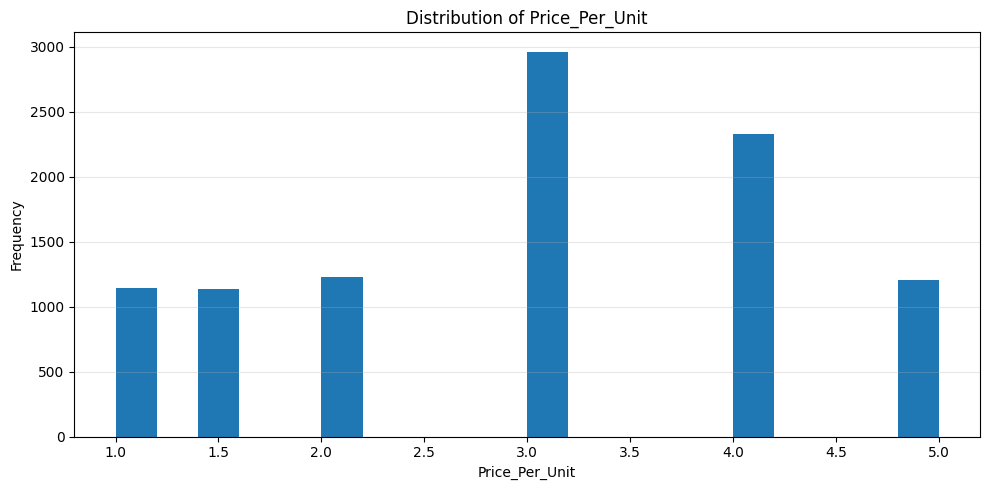

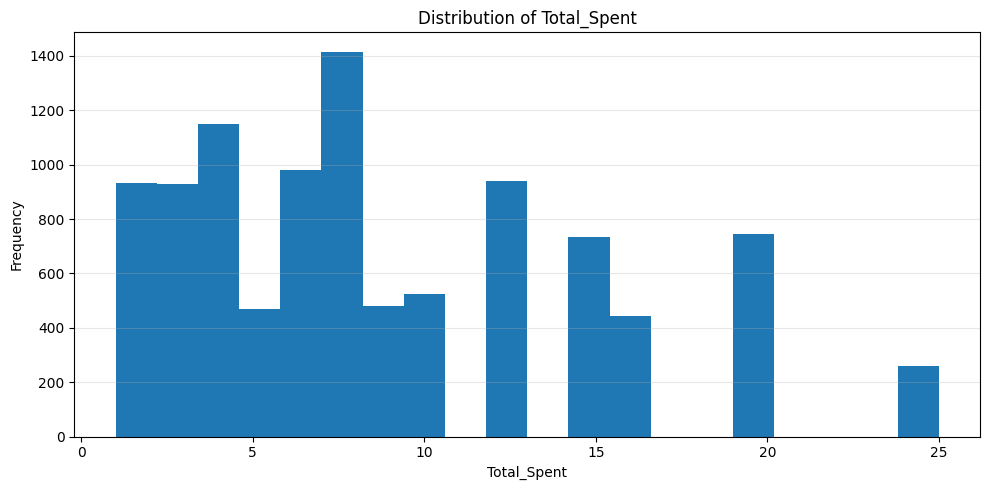

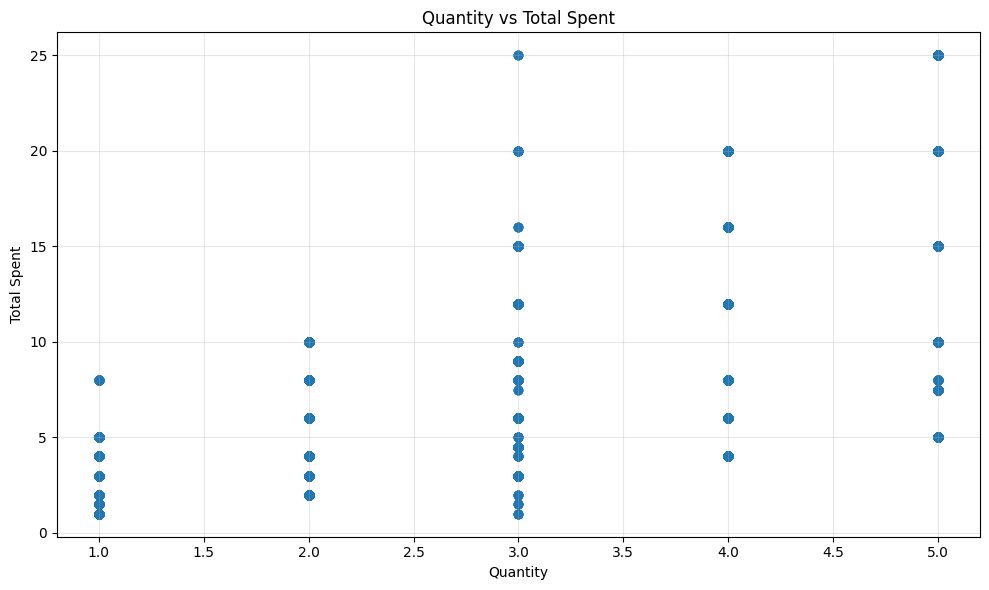

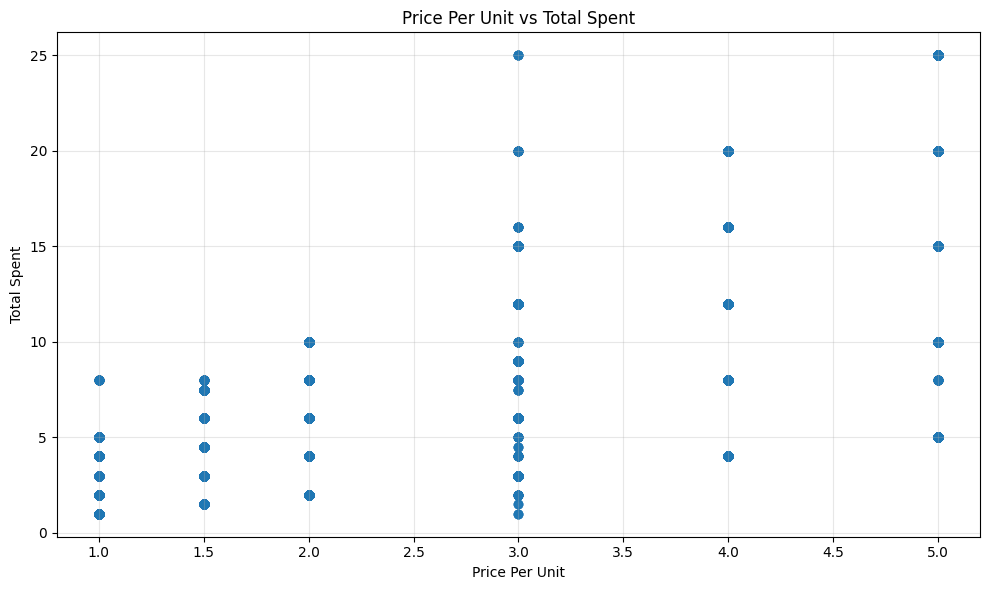


RELATIONSHIP ANALYSIS
Correlation Quantity vs Total_Spent       : 0.6688
Correlation Price_Per_Unit vs Total_Spent  : 0.6124

PATTERN ANALYSIS

Total_Spent berdasarkan Quantity:


,Quantity,Transaction_Count,Average_Spent,Total_Spent
0,1.0,1822,3.225302,5876.5
1,2.0,1974,5.895643,11638.0
2,3.0,2328,8.795533,20476.0
3,4.0,1863,11.548041,21514.0
4,5.0,2013,14.542971,29275.0



Total_Spent berdasarkan Price_Per_Unit:


,Price_Per_Unit,Transaction_Count,Average_Spent,Total_Spent
0,1.0,1143,3.241470,3705.0
1,1.5,1133,4.653133,5272.0
2,2.0,1227,6.184189,7588.0
3,3.0,2962,8.999831,26657.5
4,4.0,2331,11.914200,27772.0
5,5.0,1204,14.771595,17785.0



OUTLIER / HIGH VALUE TRANSACTION BY ITEM


...


HIGH VALUE TRANSACTIONS


,Transaction_ID,Item,Quantity,Price_Per_Unit,Total_Spent,Payment_Method,Location,Transaction_Date
9971,TXN_6120851,SALAD,5.0,5.0,25.0,CASH,TAKEAWAY,2023-02-04
3634,TXN_5677927,UNKNOWN,5.0,5.0,25.0,DIGITAL WALLET,TAKEAWAY,2023-12-20
8264,TXN_2244418,SALAD,5.0,5.0,25.0,CASH,TAKEAWAY,2023-10-15
1071,TXN_6057379,SALAD,5.0,5.0,25.0,CREDIT CARD,TAKEAWAY,2023-03-18
8152,TXN_4797429,SALAD,5.0,5.0,25.0,DIGITAL WALLET,IN-STORE,2023-11-07
8145,TXN_7647190,SALAD,3.0,5.0,25.0,CREDIT CARD,TAKEAWAY,2023-02-22
1000,TXN_5348445,SALAD,5.0,5.0,25.0,DIGITAL WALLET,IN-STORE,2023-11-15
8324,TXN_7153321,SALAD,5.0,5.0,25.0,CREDIT CARD,TAKEAWAY,2023-12-19
3823,TXN_5827969,SALAD,5.0,5.0,25.0,DIGITAL WALLET,TAKEAWAY,2023-07-03
3566,TXN_4726531,SALAD,5.0,5.0,25.0,CASH,TAKEAWAY,2023-09-09



OUTLIER VALIDITY CHECK

Quantity
Minimum : 1.0
Maximum : 5.0
Unique values : 5

Price_Per_Unit
Minimum : 1.0
Maximum : 5.0
Unique values : 6

Total_Spent
Minimum : 1.0
Maximum : 25.0
Unique values : 17

BUSINESS IMPACT
Total transaksi                    : 10,000
Outlier Total_Spent                : 259
Kontribusi outlier terhadap sales  : 7.29%

INSIGHT OUTLIER & PATTERN
1. Berdasarkan metode IQR, Quantity memiliki 0 outlier.
2. Price_Per_Unit memiliki 0 outlier berdasarkan metode IQR.
3. Total_Spent memiliki 259 outlier berdasarkan metode IQR.
4. Nilai Total_Spent maksimum adalah 25.00.
5. Nilai Quantity maksimum adalah 5.
6. Nilai Price_Per_Unit maksimum adalah 5.00.
7. Korelasi Quantity terhadap Total_Spent adalah 0.6688, menunjukkan hubungan positif antara jumlah item dan nilai transaksi.
8. Korelasi Price_Per_Unit terhadap Total_Spent adalah 0.6124, menunjukkan hubungan positif antara harga satuan dan nilai transaksi.
9. Outlier tidak langsung dianggap sebagai kesalahan. Nilai ek

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# WEEK 7 - HARI RABU
# OUTLIER & PATTERN ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from IPython.display import display
from google.colab import files

print("=" * 70)
print("WEEK 7 - HARI RABU | OUTLIER & PATTERN ANALYSIS")
print("=" * 70)

# ============================================================
# 1. LOAD DATASET
# ============================================================

if "df" not in globals():

    import glob

    csv_files = glob.glob("*.csv")

    if not csv_files:
        print("File CSV belum ditemukan.")
        print("Silakan upload Final Clean Dataset.csv")

        uploaded = files.upload()

        csv_files = [
            filename
            for filename in uploaded.keys()
            if filename.lower().endswith(".csv")
        ]

        if not csv_files:
            raise FileNotFoundError(
                "Tidak ada file CSV yang berhasil di-upload."
            )

    file_path = csv_files[0]
    df = pd.read_csv(file_path)

else:
    file_path = "Final Clean Dataset.csv"

print(f"File yang digunakan : {file_path}")
print(f"Jumlah baris        : {len(df):,}")
print(f"Jumlah kolom        : {len(df.columns)}")

# ============================================================
# 2. DATA PREPARATION
# ============================================================

numeric_columns = [
    "Quantity",
    "Price_Per_Unit",
    "Total_Spent"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

print("\nVariabel numerik yang dianalisis:")
for col in numeric_columns:
    print(f"- {col}")

# ============================================================
# 3. DISTRIBUTION SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("DISTRIBUTION SUMMARY")
print("=" * 70)

distribution_summary = []

for col in numeric_columns:

    series = df[col].dropna()

    distribution_summary.append({
        "Variable": col,
        "Count": series.count(),
        "Mean": series.mean(),
        "Median": series.median(),
        "Std": series.std(),
        "Min": series.min(),
        "Q1": series.quantile(0.25),
        "Q3": series.quantile(0.75),
        "Max": series.max()
    })

distribution_summary = pd.DataFrame(
    distribution_summary
)

display(distribution_summary)

# ============================================================
# 4. OUTLIER DETECTION — IQR
# ============================================================

print("\n" + "=" * 70)
print("OUTLIER DETECTION — IQR METHOD")
print("=" * 70)

outlier_results = []

outlier_indices = {}

for col in numeric_columns:

    series = df[col].dropna()

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    )

    outlier_count = mask.sum()

    outlier_percentage = (
        outlier_count / len(df) * 100
    )

    outlier_indices[col] = df.index[mask]

    outlier_results.append({
        "Variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outlier_count,
        "Outlier_%": outlier_percentage
    })

outlier_summary = pd.DataFrame(
    outlier_results
)

display(outlier_summary)

# ============================================================
# 5. DETAIL OUTLIER
# ============================================================

print("\n" + "=" * 70)
print("OUTLIER DETAIL")
print("=" * 70)

for col in numeric_columns:

    indices = outlier_indices[col]

    print(f"\n{col}")
    print("-" * 50)

    if len(indices) == 0:

        print("Tidak ditemukan outlier berdasarkan metode IQR.")

    else:

        outlier_data = df.loc[
            indices,
            [
                "Transaction_ID",
                "Item",
                "Quantity",
                "Price_Per_Unit",
                "Total_Spent",
                "Payment_Method",
                "Location",
                "Transaction_Date"
            ]
        ].sort_values(
            col,
            ascending=False
        )

        display(
            outlier_data.head(20)
        )

# ============================================================
# 6. BOXPLOT
# ============================================================

print("\n" + "=" * 70)
print("BOXPLOT")
print("=" * 70)

for col in numeric_columns:

    plt.figure(figsize=(10, 5))

    plt.boxplot(
        df[col].dropna(),
        vert=False
    )

    plt.title(
        f"Boxplot - {col}"
    )

    plt.xlabel(col)
    plt.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

# ============================================================
# 7. HISTOGRAM DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("DISTRIBUTION PLOTS")
print("=" * 70)

for col in numeric_columns:

    plt.figure(figsize=(10, 5))

    plt.hist(
        df[col].dropna(),
        bins=20
    )

    plt.title(
        f"Distribution of {col}"
    )

    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

# ============================================================
# 8. SCATTER PLOT
# QUANTITY × TOTAL_SPENT
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Quantity"],
    df["Total_Spent"],
    alpha=0.35
)

plt.title(
    "Quantity vs Total Spent"
)

plt.xlabel("Quantity")
plt.ylabel("Total Spent")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 9. SCATTER PLOT
# PRICE × TOTAL_SPENT
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Price_Per_Unit"],
    df["Total_Spent"],
    alpha=0.35
)

plt.title(
    "Price Per Unit vs Total Spent"
)

plt.xlabel("Price Per Unit")
plt.ylabel("Total Spent")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 10. RELATIONSHIP ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("RELATIONSHIP ANALYSIS")
print("=" * 70)

corr_quantity = df[
    ["Quantity", "Total_Spent"]
].corr().iloc[0, 1]

corr_price = df[
    ["Price_Per_Unit", "Total_Spent"]
].corr().iloc[0, 1]

print(
    f"Correlation Quantity vs Total_Spent       : "
    f"{corr_quantity:.4f}"
)

print(
    f"Correlation Price_Per_Unit vs Total_Spent  : "
    f"{corr_price:.4f}"
)

# ============================================================
# 11. PATTERN ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("PATTERN ANALYSIS")
print("=" * 70)

# Total spent berdasarkan quantity
quantity_pattern = (
    df.groupby("Quantity")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Average_Spent=("Total_Spent", "mean"),
        Total_Spent=("Total_Spent", "sum")
    )
    .reset_index()
)

print("\nTotal_Spent berdasarkan Quantity:")
display(quantity_pattern)

# Total spent berdasarkan price
price_pattern = (
    df.groupby("Price_Per_Unit")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Average_Spent=("Total_Spent", "mean"),
        Total_Spent=("Total_Spent", "sum")
    )
    .reset_index()
)

print("\nTotal_Spent berdasarkan Price_Per_Unit:")
display(price_pattern)

# ============================================================
# 12. OUTLIER BY ITEM
# ============================================================

print("\n" + "=" * 70)
print("OUTLIER / HIGH VALUE TRANSACTION BY ITEM")
print("=" * 70)

item_value_analysis = (
    df.groupby("Item")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Average_Spent=("Total_Spent", "mean"),
        Maximum_Spent=("Total_Spent", "max"),
        Total_Spent=("Total_Spent", "sum")
    )
    .reset_index()
    .sort_values(
        "Maximum_Spent",
        ascending=False
    )
)

display(item_value_analysis)

# ============================================================
# 13. HIGH VALUE TRANSACTIONS
# ============================================================

print("\n" + "=" * 70)
print("HIGH VALUE TRANSACTIONS")
print("=" * 70)

# Ambil transaksi dengan Total_Spent tertinggi
high_value = df[
    [
        "Transaction_ID",
        "Item",
        "Quantity",
        "Price_Per_Unit",
        "Total_Spent",
        "Payment_Method",
        "Location",
        "Transaction_Date"
    ]
].sort_values(
    "Total_Spent",
    ascending=False
)

display(
    high_value.head(20)
)

# ============================================================
# 14. VALIDITY CHECK
# ============================================================

print("\n" + "=" * 70)
print("OUTLIER VALIDITY CHECK")
print("=" * 70)

# Cek apakah nilai ekstrem masih berada dalam
# rentang nilai yang memang tersedia di dataset.

for col in numeric_columns:

    series = df[col].dropna()

    print(f"\n{col}")

    print(
        f"Minimum : {series.min()}"
    )

    print(
        f"Maximum : {series.max()}"
    )

    print(
        f"Unique values : "
        f"{series.nunique()}"
    )

# ============================================================
# 15. BUSINESS IMPACT
# ============================================================

print("\n" + "=" * 70)
print("BUSINESS IMPACT")
print("=" * 70)

total_transactions = len(df)

total_outlier_spent = 0

spent_outlier_indices = outlier_indices[
    "Total_Spent"
]

if len(spent_outlier_indices) > 0:

    total_outlier_spent = df.loc[
        spent_outlier_indices,
        "Total_Spent"
    ].sum()

outlier_spent_share = (
    total_outlier_spent
    / df["Total_Spent"].sum()
    * 100
)

print(
    f"Total transaksi                    : "
    f"{total_transactions:,}"
)

print(
    f"Outlier Total_Spent                : "
    f"{len(spent_outlier_indices):,}"
)

print(
    f"Kontribusi outlier terhadap sales  : "
    f"{outlier_spent_share:.2f}%"
)

# ============================================================
# 16. AUTOMATIC INSIGHTS
# ============================================================

print("\n" + "=" * 70)
print("INSIGHT OUTLIER & PATTERN")
print("=" * 70)

# Ambil informasi Total_Spent
spent_result = outlier_summary[
    outlier_summary["Variable"] == "Total_Spent"
].iloc[0]

quantity_result = outlier_summary[
    outlier_summary["Variable"] == "Quantity"
].iloc[0]

price_result = outlier_summary[
    outlier_summary["Variable"] == "Price_Per_Unit"
].iloc[0]

max_spent = df["Total_Spent"].max()
max_quantity = df["Quantity"].max()
max_price = df["Price_Per_Unit"].max()

insights = [

    (
        f"1. Berdasarkan metode IQR, "
        f"Quantity memiliki {int(quantity_result['Outlier_Count'])} "
        f"outlier."
    ),

    (
        f"2. Price_Per_Unit memiliki "
        f"{int(price_result['Outlier_Count'])} outlier "
        f"berdasarkan metode IQR."
    ),

    (
        f"3. Total_Spent memiliki "
        f"{int(spent_result['Outlier_Count'])} outlier "
        f"berdasarkan metode IQR."
    ),

    (
        f"4. Nilai Total_Spent maksimum adalah "
        f"{max_spent:.2f}."
    ),

    (
        f"5. Nilai Quantity maksimum adalah "
        f"{max_quantity:.0f}."
    ),

    (
        f"6. Nilai Price_Per_Unit maksimum adalah "
        f"{max_price:.2f}."
    ),

    (
        f"7. Korelasi Quantity terhadap Total_Spent "
        f"adalah {corr_quantity:.4f}, menunjukkan hubungan "
        f"positif antara jumlah item dan nilai transaksi."
    ),

    (
        f"8. Korelasi Price_Per_Unit terhadap Total_Spent "
        f"adalah {corr_price:.4f}, menunjukkan hubungan "
        f"positif antara harga satuan dan nilai transaksi."
    ),

    (
        f"9. Outlier tidak langsung dianggap sebagai kesalahan. "
        f"Nilai ekstrem perlu diperiksa berdasarkan konteks transaksi."
    ),

    (
        f"10. Data Total_Spent maksimum masih berada dalam "
        f"rentang nilai yang tersedia pada dataset, sehingga "
        f"belum cukup bukti untuk menyatakan transaksi ekstrem "
        f"sebagai kesalahan data."
    )
]

for insight in insights:
    print(insight)

# ============================================================
# 17. BUSINESS RECOMMENDATION AWAL
# ============================================================

print("\n" + "=" * 70)
print("REKOMENDASI AWAL")
print("=" * 70)

recommendations = [

    "1. Jangan menghapus outlier secara otomatis sebelum validasi transaksi.",

    "2. Transaksi dengan nilai ekstrem perlu dipantau karena dapat memengaruhi rata-rata Total_Spent.",

    "3. Gunakan median selain mean ketika menyajikan statistik transaksi yang memiliki outlier.",

    "4. Periksa transaksi ekstrem berdasarkan Item, Quantity, Price_Per_Unit, dan channel transaksi.",

    "5. Pertahankan outlier yang terbukti merupakan transaksi valid agar analisis bisnis tidak kehilangan informasi penting."
]

for recommendation in recommendations:
    print(recommendation)

# ============================================================
# 18. EXPORT PDF
# ============================================================

pdf_filename = "Outlier_Analysis.pdf"

with PdfPages(pdf_filename) as pdf:

    # --------------------------------------------------------
    # COVER
    # --------------------------------------------------------

    fig = plt.figure(figsize=(11.69, 8.27))

    fig.text(
        0.5,
        0.65,
        "WEEK 7 - EDA ADVANCED",
        ha="center",
        fontsize=24,
        fontweight="bold"
    )

    fig.text(
        0.5,
        0.55,
        "HARI RABU",
        ha="center",
        fontsize=20
    )

    fig.text(
        0.5,
        0.45,
        "OUTLIER & PATTERN ANALYSIS",
        ha="center",
        fontsize=24,
        fontweight="bold"
    )

    fig.text(
        0.5,
        0.32,
        "Final Clean Dataset",
        ha="center",
        fontsize=14
    )

    pdf.savefig(
        fig,
        bbox_inches="tight"
    )

    plt.close(fig)

    # --------------------------------------------------------
    # OVERVIEW
    # --------------------------------------------------------

    fig = plt.figure(figsize=(11.69, 8.27))
    plt.axis("off")

    overview = f"""
OUTLIER & PATTERN ANALYSIS

Dataset:
Final Clean Dataset.csv

Jumlah transaksi:
{len(df):,}

Variabel numerik:
Quantity
Price_Per_Unit
Total_Spent

Metode outlier:
IQR (Interquartile Range)

Total_Spent maksimum:
{max_spent:.2f}

Quantity maksimum:
{max_quantity:.0f}

Price_Per_Unit maksimum:
{max_price:.2f}

Outlier Total_Spent:
{int(spent_result['Outlier_Count']):,}
({spent_result['Outlier_%']:.2f}% dari data)

Catatan:
Outlier tidak otomatis dianggap sebagai kesalahan.
Validitas transaksi harus diperiksa berdasarkan konteks.
"""

    fig.text(
        0.08,
        0.92,
        overview,
        fontsize=12,
        va="top",
        family="monospace"
    )

    pdf.savefig(
        fig,
        bbox_inches="tight"
    )

    plt.close(fig)

    # --------------------------------------------------------
    # BOXPLOTS
    # --------------------------------------------------------

    for col in numeric_columns:

        fig = plt.figure(figsize=(11.69, 8.27))

        plt.boxplot(
            df[col].dropna(),
            vert=False
        )

        plt.title(
            f"Boxplot - {col}"
        )

        plt.xlabel(col)
        plt.grid(axis="x", alpha=0.3)

        plt.tight_layout()

        pdf.savefig(fig)

        plt.close(fig)

    # --------------------------------------------------------
    # HISTOGRAMS
    # --------------------------------------------------------

    for col in numeric_columns:

        fig = plt.figure(figsize=(11.69, 8.27))

        plt.hist(
            df[col].dropna(),
            bins=20
        )

        plt.title(
            f"Distribution of {col}"
        )

        plt.xlabel(col)
        plt.ylabel("Frequency")

        plt.grid(axis="y", alpha=0.3)

        plt.tight_layout()

        pdf.savefig(fig)

        plt.close(fig)

    # --------------------------------------------------------
    # SCATTER QUANTITY × TOTAL
    # --------------------------------------------------------

    fig = plt.figure(figsize=(11.69, 8.27))

    plt.scatter(
        df["Quantity"],
        df["Total_Spent"],
        alpha=0.35
    )

    plt.title(
        "Quantity vs Total Spent"
    )

    plt.xlabel("Quantity")
    plt.ylabel("Total Spent")

    plt.grid(alpha=0.3)

    plt.tight_layout()

    pdf.savefig(fig)

    plt.close(fig)

    # --------------------------------------------------------
    # SCATTER PRICE × TOTAL
    # --------------------------------------------------------

    fig = plt.figure(figsize=(11.69, 8.27))

    plt.scatter(
        df["Price_Per_Unit"],
        df["Total_Spent"],
        alpha=0.35
    )

    plt.title(
        "Price Per Unit vs Total Spent"
    )

    plt.xlabel("Price Per Unit")
    plt.ylabel("Total Spent")

    plt.grid(alpha=0.3)

    plt.tight_layout()

    pdf.savefig(fig)

    plt.close(fig)

    # --------------------------------------------------------
    # OUTLIER TABLE
    # --------------------------------------------------------

    fig = plt.figure(figsize=(11.69, 8.27))
    plt.axis("off")

    outlier_table = outlier_summary.copy()

    for col in [
        "Q1",
        "Q3",
        "IQR",
        "Lower_Bound",
        "Upper_Bound"
    ]:
        outlier_table[col] = (
            outlier_table[col]
            .map(lambda x: f"{x:.2f}")
        )

    outlier_table["Outlier_%"] = (
        outlier_table["Outlier_%"]
        .map(lambda x: f"{x:.2f}%")
    )

    table = plt.table(
        cellText=outlier_table.values,
        colLabels=outlier_table.columns,
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 2)

    plt.title(
        "IQR Outlier Summary",
        fontsize=16,
        fontweight="bold",
        pad=20
    )

    pdf.savefig(
        fig,
        bbox_inches="tight"
    )

    plt.close(fig)

    # --------------------------------------------------------
    # QUANTITY PATTERN
    # --------------------------------------------------------

    fig = plt.figure(figsize=(11.69, 8.27))

    plt.plot(
        quantity_pattern["Quantity"],
        quantity_pattern["Average_Spent"],
        marker="o"
    )

    plt.title(
        "Average Total Spent by Quantity"
    )

    plt.xlabel("Quantity")
    plt.ylabel("Average Total Spent")

    plt.grid(alpha=0.3)

    plt.tight_layout()

    pdf.savefig(fig)

    plt.close(fig)

    # --------------------------------------------------------
    # PRICE PATTERN
    # --------------------------------------------------------

    fig = plt.figure(figsize=(11.69, 8.27))

    plt.plot(
        price_pattern["Price_Per_Unit"],
        price_pattern["Average_Spent"],
        marker="o"
    )

    plt.title(
        "Average Total Spent by Price Per Unit"
    )

    plt.xlabel("Price Per Unit")
    plt.ylabel("Average Total Spent")

    plt.grid(alpha=0.3)

    plt.tight_layout()

    pdf.savefig(fig)

    plt.close(fig)

    # --------------------------------------------------------
    # INSIGHTS
    # --------------------------------------------------------

    fig = plt.figure(figsize=(11.69, 8.27))
    plt.axis("off")

    insight_text = (
        "OUTLIER & PATTERN ANALYSIS - KEY INSIGHTS\n\n"
        + "\n".join(insights)
    )

    fig.text(
        0.07,
        0.94,
        insight_text,
        fontsize=11,
        va="top",
        family="monospace"
    )

    pdf.savefig(
        fig,
        bbox_inches="tight"
    )

    plt.close(fig)

    # --------------------------------------------------------
    # RECOMMENDATIONS
    # --------------------------------------------------------

    fig = plt.figure(figsize=(11.69, 8.27))
    plt.axis("off")

    recommendation_text = (
        "REKOMENDASI AWAL\n\n"
        + "\n".join(recommendations)
    )

    fig.text(
        0.07,
        0.94,
        recommendation_text,
        fontsize=12,
        va="top",
        family="monospace"
    )

    pdf.savefig(
        fig,
        bbox_inches="tight"
    )

    plt.close(fig)

print("\n" + "=" * 70)
print("OUTLIER & PATTERN ANALYSIS SELESAI")
print("=" * 70)

print(f"PDF berhasil dibuat : {pdf_filename}")

files.download(pdf_filename)

In [ ]:
# ============================================================
# WEEK 7 - HARI KAMIS
# DASHBOARD SEDERHANA
# ============================================================

import pandas as pd
import numpy as np
import os
from google.colab import files

print("=" * 70)
print("WEEK 7 - HARI KAMIS | DASHBOARD SEDERHANA")
print("=" * 70)

# ============================================================
# 1. LOAD DATASET
# ============================================================

if "df" not in globals():

    csv_files = [
        f for f in os.listdir(".")
        if f.lower().endswith(".csv")
    ]

    if not csv_files:

        print("CSV belum ditemukan.")
        print("Silakan upload Final Clean Dataset.csv")

        uploaded = files.upload()

        csv_files = [
            f for f in uploaded.keys()
            if f.lower().endswith(".csv")
        ]

    if not csv_files:
        raise FileNotFoundError(
            "Dataset CSV tidak ditemukan."
        )

    file_path = csv_files[0]

    df = pd.read_csv(file_path)

else:

    file_path = "Final Clean Dataset.csv"

print(f"File yang digunakan : {file_path}")
print(f"Jumlah baris        : {len(df):,}")
print(f"Jumlah kolom        : {len(df.columns)}")

# ============================================================
# 2. DATA PREPARATION
# ============================================================

df["Transaction_Date"] = pd.to_datetime(
    df["Transaction_Date"],
    errors="coerce"
)

for col in [
    "Quantity",
    "Price_Per_Unit",
    "Total_Spent"
]:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

print("\nData preparation selesai.")

# ============================================================
# 3. KPI
# ============================================================

total_revenue = df["Total_Spent"].sum()

total_transactions = len(df)

average_transaction = (
    df["Total_Spent"].mean()
)

total_quantity = (
    df["Quantity"].sum()
)

print("\n" + "=" * 70)
print("KPI UTAMA")
print("=" * 70)

print(
    f"Total Revenue       : {total_revenue:,.2f}"
)

print(
    f"Total Transactions   : {total_transactions:,}"
)

print(
    f"Average Transaction  : {average_transaction:,.2f}"
)

print(
    f"Total Quantity       : {total_quantity:,.0f}"
)

# ============================================================
# 4. PRODUCT ANALYSIS
# ============================================================

product_analysis = (
    df.groupby("Item")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Quantity=("Quantity", "sum"),
        Total_Spent=("Total_Spent", "sum"),
        Average_Spent=("Total_Spent", "mean")
    )
    .reset_index()
)

product_analysis["Revenue_Share_%"] = (
    product_analysis["Total_Spent"]
    / product_analysis["Total_Spent"].sum()
    * 100
)

product_analysis = product_analysis.sort_values(
    "Total_Spent",
    ascending=False
)

print("\n" + "=" * 70)
print("PRODUCT ANALYSIS")
print("=" * 70)

display(product_analysis)

# ============================================================
# 5. LOCATION ANALYSIS
# ============================================================

location_analysis = (
    df.groupby("Location")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Quantity=("Quantity", "sum"),
        Total_Spent=("Total_Spent", "sum"),
        Average_Spent=("Total_Spent", "mean")
    )
    .reset_index()
)

location_analysis["Revenue_Share_%"] = (
    location_analysis["Total_Spent"]
    / location_analysis["Total_Spent"].sum()
    * 100
)

location_analysis = location_analysis.sort_values(
    "Total_Spent",
    ascending=False
)

print("\n" + "=" * 70)
print("LOCATION ANALYSIS")
print("=" * 70)

display(location_analysis)

# ============================================================
# 6. PAYMENT METHOD ANALYSIS
# ============================================================

payment_analysis = (
    df.groupby("Payment_Method")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Quantity=("Quantity", "sum"),
        Total_Spent=("Total_Spent", "sum"),
        Average_Spent=("Total_Spent", "mean")
    )
    .reset_index()
)

payment_analysis["Revenue_Share_%"] = (
    payment_analysis["Total_Spent"]
    / payment_analysis["Total_Spent"].sum()
    * 100
)

payment_analysis = payment_analysis.sort_values(
    "Total_Spent",
    ascending=False
)

print("\n" + "=" * 70)
print("PAYMENT METHOD ANALYSIS")
print("=" * 70)

display(payment_analysis)

# ============================================================
# 7. MONTHLY TREND
# ============================================================

monthly_df = df.dropna(
    subset=["Transaction_Date"]
).copy()

monthly_df["Month_Number"] = (
    monthly_df["Transaction_Date"]
    .dt.month
)

monthly_df["Month_Name"] = (
    monthly_df["Transaction_Date"]
    .dt.strftime("%B")
)

monthly_trend = (
    monthly_df.groupby(
        ["Month_Number", "Month_Name"]
    )
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Quantity=("Quantity", "sum"),
        Total_Spent=("Total_Spent", "sum"),
        Average_Spent=("Total_Spent", "mean")
    )
    .reset_index()
    .sort_values("Month_Number")
)

monthly_trend["MoM_Growth_%"] = (
    monthly_trend["Total_Spent"]
    .pct_change()
    * 100
)

print("\n" + "=" * 70)
print("MONTHLY TREND")
print("=" * 70)

display(monthly_trend)

# ============================================================
# 8. DATA QUALITY SUMMARY
# ============================================================

quality_summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Missing Transaction Date",
        "Item UNKNOWN",
        "Item ERROR",
        "Payment UNKNOWN",
        "Payment ERROR",
        "Location UNKNOWN",
        "Location ERROR",
        "Duplicate Rows"
    ],

    "Value": [
        len(df),
        len(df.columns),
        df["Transaction_Date"].isna().sum(),
        (df["Item"] == "UNKNOWN").sum(),
        (df["Item"] == "ERROR").sum(),
        (df["Payment_Method"] == "UNKNOWN").sum(),
        (df["Payment_Method"] == "ERROR").sum(),
        (df["Location"] == "UNKNOWN").sum(),
        (df["Location"] == "ERROR").sum(),
        df.duplicated().sum()
    ]
})

print("\n" + "=" * 70)
print("DATA QUALITY")
print("=" * 70)

display(quality_summary)

# ============================================================
# 9. PREPARE EXCEL FILE
# ============================================================

output_file = "Dashboard.xlsx"

with pd.ExcelWriter(
    output_file,
    engine="xlsxwriter"
) as writer:

    # --------------------------------------------------------
    # DATA
    # --------------------------------------------------------

    df.to_excel(
        writer,
        sheet_name="Data",
        index=False
    )

    # --------------------------------------------------------
    # PRODUCT
    # --------------------------------------------------------

    product_analysis.to_excel(
        writer,
        sheet_name="Product Analysis",
        index=False
    )

    # --------------------------------------------------------
    # LOCATION
    # --------------------------------------------------------

    location_analysis.to_excel(
        writer,
        sheet_name="Location Analysis",
        index=False
    )

    # --------------------------------------------------------
    # PAYMENT
    # --------------------------------------------------------

    payment_analysis.to_excel(
        writer,
        sheet_name="Payment Analysis",
        index=False
    )

    # --------------------------------------------------------
    # MONTHLY
    # --------------------------------------------------------

    monthly_trend.to_excel(
        writer,
        sheet_name="Monthly Trend",
        index=False
    )

    # --------------------------------------------------------
    # KPI SHEET
    # --------------------------------------------------------

    kpi_df = pd.DataFrame({
        "KPI": [
            "Total Revenue",
            "Total Transactions",
            "Average Transaction",
            "Total Quantity"
        ],

        "Value": [
            total_revenue,
            total_transactions,
            average_transaction,
            total_quantity
        ]
    })

    kpi_df.to_excel(
        writer,
        sheet_name="KPI",
        index=False
    )

    # --------------------------------------------------------
    # DATA QUALITY
    # --------------------------------------------------------

    quality_summary.to_excel(
        writer,
        sheet_name="Data Quality",
        index=False
    )

    # --------------------------------------------------------
    # DASHBOARD
    # --------------------------------------------------------

    workbook = writer.book

    dashboard = workbook.add_worksheet(
        "Dashboard"
    )

    # Format
    title_format = workbook.add_format({
        "bold": True,
        "font_size": 20,
        "align": "center",
        "valign": "vcenter"
    })

    section_format = workbook.add_format({
        "bold": True,
        "font_size": 14,
        "align": "center"
    })

    kpi_label_format = workbook.add_format({
        "bold": True,
        "font_size": 11,
        "align": "center"
    })

    kpi_value_format = workbook.add_format({
        "bold": True,
        "font_size": 16,
        "align": "center",
        "num_format": "#,##0.00"
    })

    number_format = workbook.add_format({
        "num_format": "#,##0.00"
    })

    percentage_format = workbook.add_format({
        "num_format": "0.00%"
    })

    # --------------------------------------------------------
    # DASHBOARD TITLE
    # --------------------------------------------------------

    dashboard.merge_range(
        "A1:N2",
        "COFFEE SHOP SALES DASHBOARD - 2023",
        title_format
    )

    dashboard.write(
        "A3",
        "Week 7 - Exploratory Data Analysis Advanced"
    )

    # --------------------------------------------------------
    # KPI CARDS
    # --------------------------------------------------------

    dashboard.merge_range(
        "A5:C5",
        "TOTAL REVENUE",
        kpi_label_format
    )

    dashboard.merge_range(
        "A6:C7",
        total_revenue,
        kpi_value_format
    )

    dashboard.merge_range(
        "D5:F5",
        "TOTAL TRANSACTIONS",
        kpi_label_format
    )

    dashboard.merge_range(
        "D6:F7",
        total_transactions,
        kpi_value_format
    )

    dashboard.merge_range(
        "G5:I5",
        "AVERAGE TRANSACTION",
        kpi_label_format
    )

    dashboard.merge_range(
        "G6:I7",
        average_transaction,
        kpi_value_format
    )

    dashboard.merge_range(
        "J5:L5",
        "TOTAL QUANTITY",
        kpi_label_format
    )

    dashboard.merge_range(
        "J6:L7",
        total_quantity,
        kpi_value_format
    )

    # --------------------------------------------------------
    # CHART DATA
    # --------------------------------------------------------

    # Product chart
    product_chart = workbook.add_chart({
        "type": "column"
    })

    product_chart.add_series({
        "name": "Total Revenue",
        "categories": [
            "Product Analysis",
            1,
            0,
            len(product_analysis),
            0
        ],
        "values": [
            "Product Analysis",
            1,
            3,
            len(product_analysis),
            3
        ]
    })

    product_chart.set_title({
        "name": "Revenue by Product"
    })

    product_chart.set_x_axis({
        "name": "Product"
    })

    product_chart.set_y_axis({
        "name": "Revenue"
    })

    product_chart.set_legend({
        "none": True
    })

    product_chart.set_size({
        "width": 650,
        "height": 350
    })

    dashboard.insert_chart(
        "A9",
        product_chart
    )

    # Location chart
    location_chart = workbook.add_chart({
        "type": "column"
    })

    location_chart.add_series({
        "name": "Total Revenue",
        "categories": [
            "Location Analysis",
            1,
            0,
            len(location_analysis),
            0
        ],
        "values": [
            "Location Analysis",
            1,
            3,
            len(location_analysis),
            3
        ]
    })

    location_chart.set_title({
        "name": "Revenue by Location"
    })

    location_chart.set_x_axis({
        "name": "Location"
    })

    location_chart.set_y_axis({
        "name": "Revenue"
    })

    location_chart.set_legend({
        "none": True
    })

    location_chart.set_size({
        "width": 650,
        "height": 350
    })

    dashboard.insert_chart(
        "H9",
        location_chart
    )

    # Payment chart
    payment_chart = workbook.add_chart({
        "type": "column"
    })

    payment_chart.add_series({
        "name": "Total Revenue",
        "categories": [
            "Payment Analysis",
            1,
            0,
            len(payment_analysis),
            0
        ],
        "values": [
            "Payment Analysis",
            1,
            3,
            len(payment_analysis),
            3
        ]
    })

    payment_chart.set_title({
        "name": "Revenue by Payment Method"
    })

    payment_chart.set_x_axis({
        "name": "Payment Method"
    })

    payment_chart.set_y_axis({
        "name": "Revenue"
    })

    payment_chart.set_legend({
        "none": True
    })

    payment_chart.set_size({
        "width": 650,
        "height": 350
    })

    dashboard.insert_chart(
        "A27",
        payment_chart
    )

    # Monthly chart
    monthly_chart = workbook.add_chart({
        "type": "line"
    })

    monthly_chart.add_series({
        "name": "Monthly Revenue",
        "categories": [
            "Monthly Trend",
            1,
            1,
            len(monthly_trend),
            1
        ],
        "values": [
            "Monthly Trend",
            1,
            4,
            len(monthly_trend),
            4
        ],
        "marker": {
            "type": "circle",
            "size": 6
        }
    })

    monthly_chart.set_title({
        "name": "Monthly Revenue Trend"
    })

    monthly_chart.set_x_axis({
        "name": "Month"
    })

    monthly_chart.set_y_axis({
        "name": "Revenue"
    })

    monthly_chart.set_size({
        "width": 650,
        "height": 350
    })

    dashboard.insert_chart(
        "H27",
        monthly_chart
    )

    # --------------------------------------------------------
    # DASHBOARD FOOTNOTE
    # --------------------------------------------------------

    dashboard.write(
        "A45",
        "Catatan:"
    )

    dashboard.write(
        "A46",
        "Nilai UNKNOWN dan ERROR merupakan placeholder "
        "kualitas data dan tidak dianggap sebagai kategori bisnis."
    )

    dashboard.write(
        "A47",
        "Analisis temporal menggunakan transaksi dengan "
        "Transaction_Date yang tersedia."
    )

    # --------------------------------------------------------
    # COLUMN WIDTH
    # --------------------------------------------------------

    dashboard.set_column(
        "A:N",
        14
    )

    dashboard.set_column(
        "A:A",
        18
    )

    dashboard.freeze_panes(
        8,
        0
    )

print("\n" + "=" * 70)
print("DASHBOARD SELESAI")
print("=" * 70)

print(
    f"File berhasil dibuat : {output_file}"
)

# ============================================================
# 10. DOWNLOAD
# ============================================================

files.download(output_file)

WEEK 7 - HARI KAMIS | DASHBOARD SEDERHANA
File yang digunakan : Final Clean Dataset.csv
Jumlah baris        : 10,000
Jumlah kolom        : 10

Data preparation selesai.

KPI UTAMA
Total Revenue       : 88,779.50
Total Transactions   : 10,000
Average Transaction  : 8.88
Total Quantity       : 30,271

PRODUCT ANALYSIS


,Item,Transaction_Count,Total_Quantity,Total_Spent,Average_Spent,Revenue_Share_%
5,SALAD,1148,3469.0,17021.0,14.826655,19.172219
6,SANDWICH,1131,3428.0,13484.0,11.922193,15.188191
4,JUICE,1504,4530.0,13449.0,8.942154,15.148767
7,SMOOTHIE,1096,3353.0,13132.0,11.981752,14.791703
0,CAKE,1139,3467.0,10341.0,9.079017,11.647959
1,COFFEE,1165,3551.0,7184.0,6.166524,8.091958
8,TEA,1089,3319.0,5119.5,4.701102,5.766534
2,COOKIE,1092,3249.0,3526.0,3.228938,3.971638
9,UNKNOWN,344,1006.0,2933.5,8.527616,3.304254
3,ERROR,292,899.0,2589.5,8.868151,2.916777



LOCATION ANALYSIS


,Location,Transaction_Count,Total_Quantity,Total_Spent,Average_Spent,Revenue_Share_%
2,TAKEAWAY,6287,19069.0,55645.0,8.850803,62.677758
1,IN-STORE,3017,9139.0,27090.0,8.979118,30.513801
0,ERROR,358,1100.0,3260.5,9.107542,3.672582
3,UNKNOWN,338,963.0,2784.0,8.236686,3.135859



PAYMENT METHOD ANALYSIS


...


MONTHLY TREND


,Month_Number,Month_Name,Transaction_Count,Total_Quantity,Total_Spent,Average_Spent,MoM_Growth_%
0,1,January,818,2463.0,7221.0,8.827628,NaN
1,2,February,727,2248.0,6584.0,9.056396,-8.821493
2,3,March,827,2480.0,7198.0,8.703748,9.325638
3,4,April,774,2387.0,7138.5,9.222868,-0.826619
4,5,May,777,2342.0,6970.0,8.970399,-2.360440
5,6,June,818,2471.0,7327.5,8.957824,5.129125
6,7,July,791,2361.0,6910.0,8.735777,-5.697714
7,8,August,803,2405.0,7112.0,8.856787,2.923300
8,9,September,788,2363.0,6829.5,8.666878,-3.972160
9,10,October,838,2535.0,7336.5,8.754773,7.423677



DATA QUALITY


,Metric,Value
0,Total Rows,10000
1,Total Columns,10
2,Missing Transaction Date,460
3,Item UNKNOWN,344
4,Item ERROR,292
5,Payment UNKNOWN,293
6,Payment ERROR,306
7,Location UNKNOWN,338
8,Location ERROR,358
9,Duplicate Rows,0


ModuleNotFoundError: No module named 'xlsxwriter'

In [ ]:
# ============================================================
# WEEK 7 - HARI KAMIS
# DASHBOARD SEDERHANA
# ============================================================

# Install dependency
!pip -q install openpyxl

# ============================================================
# IMPORT
# ============================================================

import pandas as pd
import numpy as np
import os

from google.colab import files

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.chart import BarChart, LineChart, Reference
from openpyxl.chart.label import DataLabelList
from openpyxl.utils import get_column_letter


print("=" * 70)
print("WEEK 7 - HARI KAMIS | DASHBOARD SEDERHANA")
print("=" * 70)


# ============================================================
# 1. LOAD DATASET
# ============================================================

csv_files = [
    f for f in os.listdir(".")
    if f.lower().endswith(".csv")
]

if not csv_files:

    print("Dataset CSV belum ditemukan.")
    print("Silakan upload Final Clean Dataset.csv")

    uploaded = files.upload()

    csv_files = [
        f for f in uploaded.keys()
        if f.lower().endswith(".csv")
    ]

if not csv_files:

    raise FileNotFoundError(
        "File CSV tidak ditemukan."
    )

# Cari dataset utama
preferred_files = [
    f for f in csv_files
    if "final clean dataset" in f.lower()
]

if preferred_files:
    file_path = preferred_files[0]
else:
    file_path = csv_files[0]


df = pd.read_csv(file_path)

print(f"File yang digunakan : {file_path}")
print(f"Jumlah baris        : {len(df):,}")
print(f"Jumlah kolom        : {len(df.columns)}")


# ============================================================
# 2. DATA PREPARATION
# ============================================================

df["Transaction_Date"] = pd.to_datetime(
    df["Transaction_Date"],
    errors="coerce"
)

numeric_columns = [
    "Quantity",
    "Price_Per_Unit",
    "Total_Spent"
]

for col in numeric_columns:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


print("\nData preparation selesai.")


# ============================================================
# 3. KPI
# ============================================================

total_revenue = df["Total_Spent"].sum()

total_transactions = len(df)

average_transaction = df["Total_Spent"].mean()

total_quantity = df["Quantity"].sum()


print("\n" + "=" * 70)
print("KPI UTAMA")
print("=" * 70)

print(
    f"Total Revenue       : {total_revenue:,.2f}"
)

print(
    f"Total Transactions   : {total_transactions:,}"
)

print(
    f"Average Transaction  : {average_transaction:,.2f}"
)

print(
    f"Total Quantity       : {total_quantity:,.0f}"
)


# ============================================================
# 4. PRODUCT ANALYSIS
# ============================================================

product_analysis = (
    df.groupby("Item")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Quantity=("Quantity", "sum"),
        Total_Spent=("Total_Spent", "sum"),
        Average_Spent=("Total_Spent", "mean")
    )
    .reset_index()
)

product_analysis["Revenue_Share_%"] = (
    product_analysis["Total_Spent"]
    / product_analysis["Total_Spent"].sum()
    * 100
)

product_analysis = product_analysis.sort_values(
    "Total_Spent",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 70)
print("PRODUCT ANALYSIS")
print("=" * 70)

display(product_analysis)


# ============================================================
# 5. LOCATION ANALYSIS
# ============================================================

location_analysis = (
    df.groupby("Location")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Quantity=("Quantity", "sum"),
        Total_Spent=("Total_Spent", "sum"),
        Average_Spent=("Total_Spent", "mean")
    )
    .reset_index()
)

location_analysis["Revenue_Share_%"] = (
    location_analysis["Total_Spent"]
    / location_analysis["Total_Spent"].sum()
    * 100
)

location_analysis = location_analysis.sort_values(
    "Total_Spent",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 70)
print("LOCATION ANALYSIS")
print("=" * 70)

display(location_analysis)


# ============================================================
# 6. PAYMENT METHOD ANALYSIS
# ============================================================

payment_analysis = (
    df.groupby("Payment_Method")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Quantity=("Quantity", "sum"),
        Total_Spent=("Total_Spent", "sum"),
        Average_Spent=("Total_Spent", "mean")
    )
    .reset_index()
)

payment_analysis["Revenue_Share_%"] = (
    payment_analysis["Total_Spent"]
    / payment_analysis["Total_Spent"].sum()
    * 100
)

payment_analysis = payment_analysis.sort_values(
    "Total_Spent",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 70)
print("PAYMENT METHOD ANALYSIS")
print("=" * 70)

display(payment_analysis)


# ============================================================
# 7. MONTHLY TREND
# ============================================================

monthly_df = df.dropna(
    subset=["Transaction_Date"]
).copy()

monthly_df["Month_Number"] = (
    monthly_df["Transaction_Date"].dt.month
)

monthly_df["Month_Name"] = (
    monthly_df["Transaction_Date"].dt.strftime("%B")
)

monthly_trend = (
    monthly_df
    .groupby(
        ["Month_Number", "Month_Name"]
    )
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Quantity=("Quantity", "sum"),
        Total_Spent=("Total_Spent", "sum"),
        Average_Spent=("Total_Spent", "mean")
    )
    .reset_index()
    .sort_values("Month_Number")
)

monthly_trend["MoM_Growth_%"] = (
    monthly_trend["Total_Spent"]
    .pct_change()
    * 100
)

monthly_trend = monthly_trend.reset_index(
    drop=True
)


print("\n" + "=" * 70)
print("MONTHLY TREND")
print("=" * 70)

display(monthly_trend)


# ============================================================
# 8. DATA QUALITY
# ============================================================

quality_summary = pd.DataFrame({

    "Metric": [
        "Total Rows",
        "Total Columns",
        "Missing Transaction Date",
        "Item UNKNOWN",
        "Item ERROR",
        "Payment UNKNOWN",
        "Payment ERROR",
        "Location UNKNOWN",
        "Location ERROR",
        "Duplicate Rows"
    ],

    "Value": [
        len(df),
        len(df.columns),
        df["Transaction_Date"].isna().sum(),
        (df["Item"] == "UNKNOWN").sum(),
        (df["Item"] == "ERROR").sum(),
        (df["Payment_Method"] == "UNKNOWN").sum(),
        (df["Payment_Method"] == "ERROR").sum(),
        (df["Location"] == "UNKNOWN").sum(),
        (df["Location"] == "ERROR").sum(),
        df.duplicated().sum()
    ]

})


print("\n" + "=" * 70)
print("DATA QUALITY")
print("=" * 70)

display(quality_summary)


# ============================================================
# 9. CREATE EXCEL WORKBOOK
# ============================================================

output_file = "Dashboard.xlsx"

wb = Workbook()


# ============================================================
# DELETE DEFAULT SHEET
# ============================================================

default_sheet = wb.active

wb.remove(default_sheet)


# ============================================================
# CREATE SHEETS
# ============================================================

ws_dashboard = wb.create_sheet(
    "Dashboard"
)

ws_data = wb.create_sheet(
    "Data"
)

ws_product = wb.create_sheet(
    "Product Analysis"
)

ws_location = wb.create_sheet(
    "Location Analysis"
)

ws_payment = wb.create_sheet(
    "Payment Analysis"
)

ws_monthly = wb.create_sheet(
    "Monthly Trend"
)

ws_kpi = wb.create_sheet(
    "KPI"
)

ws_quality = wb.create_sheet(
    "Data Quality"
)


# ============================================================
# STYLE DEFINITIONS
# ============================================================

title_fill = PatternFill(
    "solid",
    fgColor="1F4E78"
)

section_fill = PatternFill(
    "solid",
    fgColor="D9EAF7"
)

kpi_fill = PatternFill(
    "solid",
    fgColor="E2F0D9"
)

header_fill = PatternFill(
    "solid",
    fgColor="5B9BD5"
)

white_font = Font(
    color="FFFFFF",
    bold=True
)

title_font = Font(
    size=20,
    bold=True,
    color="FFFFFF"
)

section_font = Font(
    size=13,
    bold=True
)

normal_bold = Font(
    bold=True
)

thin_border = Border(
    left=Side(style="thin"),
    right=Side(style="thin"),
    top=Side(style="thin"),
    bottom=Side(style="thin")
)


# ============================================================
# HELPER FUNCTION
# ============================================================

def write_dataframe(
    worksheet,
    dataframe,
    start_row=1,
    start_col=1
):

    # Header
    for col_idx, column_name in enumerate(
        dataframe.columns,
        start=start_col
    ):

        cell = worksheet.cell(
            row=start_row,
            column=col_idx,
            value=column_name
        )

        cell.fill = header_fill
        cell.font = white_font
        cell.alignment = Alignment(
            horizontal="center"
        )
        cell.border = thin_border

    # Data
    for row_idx, row in enumerate(
        dataframe.itertuples(index=False),
        start=start_row + 1
    ):

        for col_idx, value in enumerate(
            row,
            start=start_col
        ):

            cell = worksheet.cell(
                row=row_idx,
                column=col_idx,
                value=value
            )

            cell.border = thin_border

    # Width
    for col_idx in range(
        start_col,
        start_col + len(dataframe.columns)
    ):

        max_length = 0

        column_letter = get_column_letter(
            col_idx
        )

        for cell in worksheet[column_letter]:

            if cell.value is not None:

                max_length = max(
                    max_length,
                    len(str(cell.value))
                )

        worksheet.column_dimensions[
            column_letter
        ].width = min(
            max_length + 2,
            30
        )


# ============================================================
# 10. WRITE DATA SHEET
# ============================================================

write_dataframe(
    ws_data,
    df
)

ws_data.freeze_panes = "A2"


# ============================================================
# 11. WRITE PRODUCT SHEET
# ============================================================

write_dataframe(
    ws_product,
    product_analysis
)

ws_product.freeze_panes = "A2"


# Format product numeric columns
for row in ws_product.iter_rows(
    min_row=2
):

    row[3].number_format = '#,##0.00'
    row[4].number_format = '#,##0.00'
    row[5].number_format = '0.00'


# ============================================================
# 12. WRITE LOCATION SHEET
# ============================================================

write_dataframe(
    ws_location,
    location_analysis
)

ws_location.freeze_panes = "A2"

for row in ws_location.iter_rows(
    min_row=2
):

    row[3].number_format = '#,##0.00'
    row[4].number_format = '#,##0.00'
    row[5].number_format = '0.00'


# ============================================================
# 13. WRITE PAYMENT SHEET
# ============================================================

write_dataframe(
    ws_payment,
    payment_analysis
)

ws_payment.freeze_panes = "A2"

for row in ws_payment.iter_rows(
    min_row=2
):

    row[3].number_format = '#,##0.00'
    row[4].number_format = '#,##0.00'
    row[5].number_format = '0.00'


# ============================================================
# 14. WRITE MONTHLY SHEET
# ============================================================

write_dataframe(
    ws_monthly,
    monthly_trend
)

ws_monthly.freeze_panes = "A2"

for row in ws_monthly.iter_rows(
    min_row=2
):

    row[3].number_format = '#,##0.00'
    row[4].number_format = '#,##0.00'
    row[5].number_format = '#,##0.00'
    row[6].number_format = '0.00'


# ============================================================
# 15. WRITE KPI SHEET
# ============================================================

kpi_data = [
    ["KPI", "Value"],
    ["Total Revenue", total_revenue],
    ["Total Transactions", total_transactions],
    ["Average Transaction", average_transaction],
    ["Total Quantity", total_quantity]
]

for r_idx, row in enumerate(
    kpi_data,
    start=1
):

    for c_idx, value in enumerate(
        row,
        start=1
    ):

        cell = ws_kpi.cell(
            row=r_idx,
            column=c_idx,
            value=value
        )

        cell.border = thin_border

        if r_idx == 1:

            cell.fill = header_fill
            cell.font = white_font
            cell.alignment = Alignment(
                horizontal="center"
            )

        else:

            if c_idx == 1:
                cell.font = normal_bold


ws_kpi.column_dimensions["A"].width = 25
ws_kpi.column_dimensions["B"].width = 20

ws_kpi["B2"].number_format = '#,##0.00'
ws_kpi["B3"].number_format = '#,##0'
ws_kpi["B4"].number_format = '#,##0.00'
ws_kpi["B5"].number_format = '#,##0'


# ============================================================
# 16. WRITE DATA QUALITY SHEET
# ============================================================

write_dataframe(
    ws_quality,
    quality_summary
)

ws_quality.freeze_panes = "A2"


# ============================================================
# 17. DASHBOARD TITLE
# ============================================================

ws_dashboard.merge_cells(
    "A1:N2"
)

ws_dashboard["A1"] = (
    "COFFEE SHOP SALES DASHBOARD - 2023"
)

ws_dashboard["A1"].fill = title_fill
ws_dashboard["A1"].font = title_font
ws_dashboard["A1"].alignment = Alignment(
    horizontal="center",
    vertical="center"
)

ws_dashboard.row_dimensions[1].height = 30
ws_dashboard.row_dimensions[2].height = 30


ws_dashboard.merge_cells(
    "A3:N3"
)

ws_dashboard["A3"] = (
    "Week 7 - Exploratory Data Analysis Advanced"
)

ws_dashboard["A3"].alignment = Alignment(
    horizontal="center"
)

ws_dashboard["A3"].font = Font(
    italic=True
)


# ============================================================
# 18. KPI CARDS
# ============================================================

kpi_cards = [
    (
        "A5:C5",
        "A6:C7",
        "TOTAL REVENUE",
        total_revenue,
        '#,##0.00'
    ),

    (
        "D5:F5",
        "D6:F7",
        "TOTAL TRANSACTIONS",
        total_transactions,
        '#,##0'
    ),

    (
        "G5:I5",
        "G6:I7",
        "AVERAGE TRANSACTION",
        average_transaction,
        '#,##0.00'
    ),

    (
        "J5:L5",
        "J6:L7",
        "TOTAL QUANTITY",
        total_quantity,
        '#,##0'
    )
]


for label_range, value_range, label, value, num_format in kpi_cards:

    ws_dashboard.merge_cells(
        label_range
    )

    ws_dashboard.merge_cells(
        value_range
    )

    label_cell = ws_dashboard[
        label_range.split(":")[0]
    ]

    value_cell = ws_dashboard[
        value_range.split(":")[0]
    ]

    label_cell.value = label
    value_cell.fill = section_fill
    label_cell.font = section_font
    label_cell.alignment = Alignment(
        horizontal="center",
        vertical="center"
    )

    value_cell.value = value
    value_cell.fill = kpi_fill
    value_cell.font = Font(
        size=16,
        bold=True
    )
    value_cell.alignment = Alignment(
        horizontal="center",
        vertical="center"
    )
    value_cell.number_format = num_format


# ============================================================
# 19. DASHBOARD INSIGHTS
# ============================================================

top_product = product_analysis.iloc[0]

top_location = location_analysis.iloc[0]

top_payment = payment_analysis.iloc[0]

highest_month = monthly_trend.loc[
    monthly_trend["Total_Spent"].idxmax()
]

lowest_month = monthly_trend.loc[
    monthly_trend["Total_Spent"].idxmin()
]


ws_dashboard.merge_cells(
    "M5:N5"
)

ws_dashboard["M5"] = "KEY INSIGHTS"
ws_dashboard["M5"].fill = section_fill
ws_dashboard["M5"].font = section_font
ws_dashboard["M5"].alignment = Alignment(
    horizontal="center"
)


insight_lines = [
    f"Top Product: {top_product['Item']}",
    f"Revenue: {top_product['Total_Spent']:,.2f}",
    "",
    f"Top Location: {top_location['Location']}",
    f"Revenue: {top_location['Total_Spent']:,.2f}",
    "",
    f"Top Payment: {top_payment['Payment_Method']}",
    f"Revenue: {top_payment['Total_Spent']:,.2f}",
    "",
    f"Highest Month: {highest_month['Month_Name']}",
    f"Revenue: {highest_month['Total_Spent']:,.2f}",
    "",
    f"Lowest Month: {lowest_month['Month_Name']}",
    f"Revenue: {lowest_month['Total_Spent']:,.2f}"
]


for idx, text in enumerate(
    insight_lines,
    start=6
):

    ws_dashboard.merge_cells(
        start_row=idx,
        start_column=13,
        end_row=idx,
        end_column=14
    )

    cell = ws_dashboard.cell(
        row=idx,
        column=13,
        value=text
    )

    cell.alignment = Alignment(
        horizontal="left",
        vertical="center"
    )


# ============================================================
# 20. PRODUCT CHART
# ============================================================

product_chart = BarChart()

product_chart.type = "col"

product_chart.style = 10

product_chart.title = (
    "Revenue by Product"
)

product_chart.y_axis.title = (
    "Total Revenue"
)

product_chart.x_axis.title = (
    "Product"
)

product_data = Reference(
    ws_product,
    min_col=4,
    min_row=1,
    max_row=len(product_analysis) + 1
)

product_categories = Reference(
    ws_product,
    min_col=1,
    min_row=2,
    max_row=len(product_analysis) + 1
)

product_chart.add_data(
    product_data,
    titles_from_data=True
)

product_chart.set_categories(
    product_categories
)

product_chart.height = 7
product_chart.width = 12

product_chart.legend = None

ws_dashboard.add_chart(
    product_chart,
    "A9"
)


# ============================================================
# 21. LOCATION CHART
# ============================================================

location_chart = BarChart()

location_chart.type = "col"

location_chart.style = 11

location_chart.title = (
    "Revenue by Location"
)

location_chart.y_axis.title = (
    "Total Revenue"
)

location_chart.x_axis.title = (
    "Location"
)

location_data = Reference(
    ws_location,
    min_col=4,
    min_row=1,
    max_row=len(location_analysis) + 1
)

location_categories = Reference(
    ws_location,
    min_col=1,
    min_row=2,
    max_row=len(location_analysis) + 1
)

location_chart.add_data(
    location_data,
    titles_from_data=True
)

location_chart.set_categories(
    location_categories
)

location_chart.height = 7
location_chart.width = 12

location_chart.legend = None

ws_dashboard.add_chart(
    location_chart,
    "H9"
)


# ============================================================
# 22. PAYMENT CHART
# ============================================================

payment_chart = BarChart()

payment_chart.type = "col"

payment_chart.style = 12

payment_chart.title = (
    "Revenue by Payment Method"
)

payment_chart.y_axis.title = (
    "Total Revenue"
)

payment_chart.x_axis.title = (
    "Payment Method"
)

payment_data = Reference(
    ws_payment,
    min_col=4,
    min_row=1,
    max_row=len(payment_analysis) + 1
)

payment_categories = Reference(
    ws_payment,
    min_col=1,
    min_row=2,
    max_row=len(payment_analysis) + 1
)

payment_chart.add_data(
    payment_data,
    titles_from_data=True
)

payment_chart.set_categories(
    payment_categories
)

payment_chart.height = 7
payment_chart.width = 12

payment_chart.legend = None

ws_dashboard.add_chart(
    payment_chart,
    "A25"
)


# ============================================================
# 23. MONTHLY TREND CHART
# ============================================================

monthly_chart = LineChart()

monthly_chart.style = 13

monthly_chart.title = (
    "Monthly Revenue Trend"
)

monthly_chart.y_axis.title = (
    "Total Revenue"
)

monthly_chart.x_axis.title = (
    "Month"
)

monthly_data = Reference(
    ws_monthly,
    min_col=5,
    min_row=1,
    max_row=len(monthly_trend) + 1
)

monthly_categories = Reference(
    ws_monthly,
    min_col=2,
    min_row=2,
    max_row=len(monthly_trend) + 1
)

monthly_chart.add_data(
    monthly_data,
    titles_from_data=True
)

monthly_chart.set_categories(
    monthly_categories
)

monthly_chart.height = 7
monthly_chart.width = 12

ws_dashboard.add_chart(
    monthly_chart,
    "H25"
)


# ============================================================
# 24. DASHBOARD FOOTNOTE
# ============================================================

ws_dashboard.merge_cells(
    "A41:N41"
)

ws_dashboard["A41"] = (
    "Catatan: UNKNOWN dan ERROR merupakan placeholder "
    "kualitas data, bukan kategori bisnis."
)

ws_dashboard["A41"].font = Font(
    italic=True
)

ws_dashboard["A41"].alignment = Alignment(
    horizontal="center"
)


ws_dashboard.merge_cells(
    "A42:N42"
)

ws_dashboard["A42"] = (
    "Analisis temporal menggunakan transaksi "
    "dengan Transaction_Date yang tersedia."
)

ws_dashboard["A42"].font = Font(
    italic=True
)

ws_dashboard["A42"].alignment = Alignment(
    horizontal="center"
)


# ============================================================
# 25. DASHBOARD COLUMN WIDTH
# ============================================================

for col in range(1, 15):

    ws_dashboard.column_dimensions[
        get_column_letter(col)
    ].width = 14


ws_dashboard.column_dimensions["A"].width = 16

ws_dashboard.column_dimensions["M"].width = 18
ws_dashboard.column_dimensions["N"].width = 18


# ============================================================
# 26. FREEZE PANES
# ============================================================

ws_dashboard.freeze_panes = "A5"


# ============================================================
# 27. PAGE SETUP
# ============================================================

ws_dashboard.sheet_view.showGridLines = False

ws_dashboard.page_setup.orientation = (
    "landscape"
)

ws_dashboard.page_setup.fitToWidth = 1

ws_dashboard.page_setup.fitToHeight = 1


# ============================================================
# 28. SAVE WORKBOOK
# ============================================================

wb.save(
    output_file
)


# ============================================================
# 29. VERIFY FILE
# ============================================================

if os.path.exists(output_file):

    file_size = os.path.getsize(
        output_file
    )

    print("\n" + "=" * 70)
    print("DASHBOARD SELESAI")
    print("=" * 70)

    print(
        f"File berhasil dibuat : {output_file}"
    )

    print(
        f"Ukuran file         : "
        f"{file_size / 1024:.2f} KB"
    )

else:

    raise FileNotFoundError(
        "Dashboard.xlsx gagal dibuat."
    )


# ============================================================
# 30. DOWNLOAD
# ============================================================

files.download(
    output_file
)

WEEK 7 - HARI KAMIS | DASHBOARD SEDERHANA
File yang digunakan : Final Clean Dataset.csv
Jumlah baris        : 10,000
Jumlah kolom        : 10

Data preparation selesai.

KPI UTAMA
Total Revenue       : 88,779.50
Total Transactions   : 10,000
Average Transaction  : 8.88
Total Quantity       : 30,271

PRODUCT ANALYSIS


,Item,Transaction_Count,Total_Quantity,Total_Spent,Average_Spent,Revenue_Share_%
0,SALAD,1148,3469.0,17021.0,14.826655,19.172219
1,SANDWICH,1131,3428.0,13484.0,11.922193,15.188191
2,JUICE,1504,4530.0,13449.0,8.942154,15.148767
3,SMOOTHIE,1096,3353.0,13132.0,11.981752,14.791703
4,CAKE,1139,3467.0,10341.0,9.079017,11.647959
5,COFFEE,1165,3551.0,7184.0,6.166524,8.091958
6,TEA,1089,3319.0,5119.5,4.701102,5.766534
7,COOKIE,1092,3249.0,3526.0,3.228938,3.971638
8,UNKNOWN,344,1006.0,2933.5,8.527616,3.304254
9,ERROR,292,899.0,2589.5,8.868151,2.916777



LOCATION ANALYSIS


,Location,Transaction_Count,Total_Quantity,Total_Spent,Average_Spent,Revenue_Share_%
0,TAKEAWAY,6287,19069.0,55645.0,8.850803,62.677758
1,IN-STORE,3017,9139.0,27090.0,8.979118,30.513801
2,ERROR,358,1100.0,3260.5,9.107542,3.672582
3,UNKNOWN,338,963.0,2784.0,8.236686,3.135859



PAYMENT METHOD ANALYSIS


...


DATA QUALITY


,Metric,Value
0,Total Rows,10000
1,Total Columns,10
2,Missing Transaction Date,460
3,Item UNKNOWN,344
4,Item ERROR,292
5,Payment UNKNOWN,293
6,Payment ERROR,306
7,Location UNKNOWN,338
8,Location ERROR,358
9,Duplicate Rows,0



DASHBOARD SELESAI
File berhasil dibuat : Dashboard.xlsx
Ukuran file         : 497.89 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 8.8 MB/s eta 0:00:00
WEEK 7 - HARI JUMAT | FINAL PROJECT EDA

Dataset berhasil dimuat.
File        : Final Clean Dataset.csv
Rows        : 10,000
Columns     : 10

DATASET PROFILE
Rows                    : 10,000
Columns                 : 10
Total missing cells     : 1,380
Duplicate rows          : 0
Missing Transaction Date: 460

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max,median,mode,range
Quantity,10000.0,3.02710,1.384614,1.0,2.0,3.0,4.0,5.0,3.0,3.0,4.0
Price_Per_Unit,10000.0,2.95265,1.243960,1.0,2.0,3.0,4.0,5.0,3.0,3.0,4.0
Total_Spent,10000.0,8.87795,5.860590,1.0,4.0,8.0,12.0,25.0,8.0,8.0,24.0



KPI
Total Revenue      : 88,779.50
Transactions       : 10,000
Average Transaction: 8.88
Median Transaction : 8.00
Total Quantity     : 30,271

FINAL EDA INSIGHTS
1. Total revenue dataset adalah 88,779.50.
2. Produk dengan revenue terbesar adalah SALAD sebesar 17,021.00 (19.17%).
3. Lokasi dengan revenue terbesar adalah TAKEAWAY sebesar 55,645.00 (62.68%).
4. Payment method dengan revenue terbesar adalah DIGITAL WALLET sebesar 42,948.00 (48.38%).
5. Bulan dengan revenue tertinggi adalah October sebesar 7,336.50.
6. Bulan dengan revenue terendah adalah February sebesar 6,584.00.
7. Korelasi Quantity terhadap Total_Spent adalah 0.6688.
8. Korelasi Price_Per_Unit terhadap Total_Spent adalah 0.6124.
9. Ditemukan 259 outlier pada Total_Spent berdasarkan metode IQR.
10. Terdapat 460 transaksi dengan Transaction_Date yang kosong.

Membuat visualisasi final...


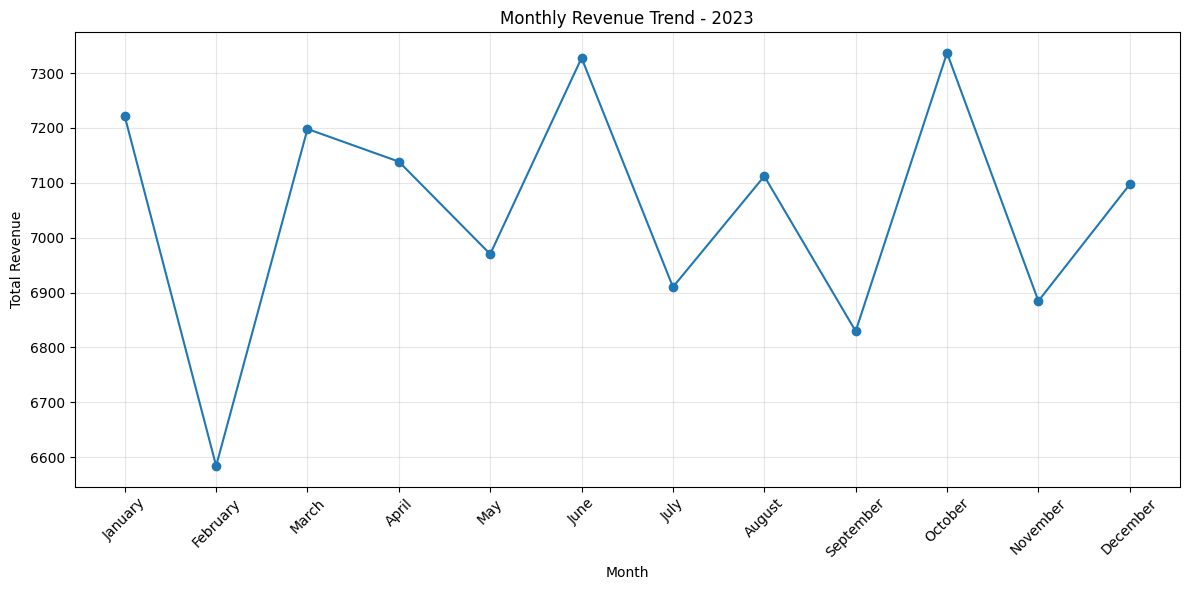

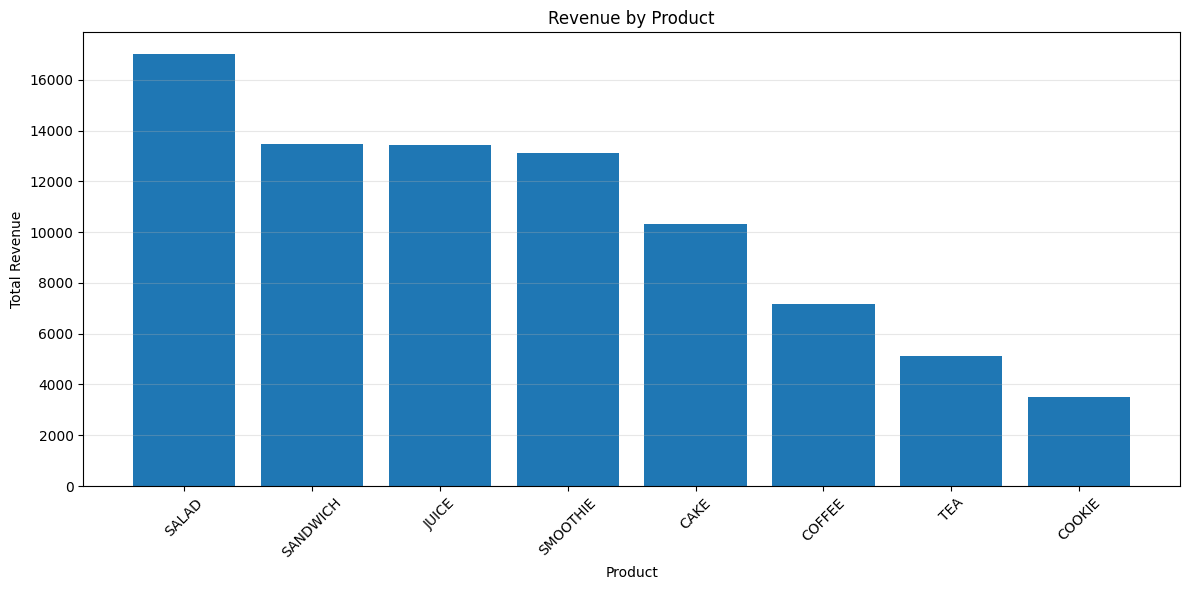

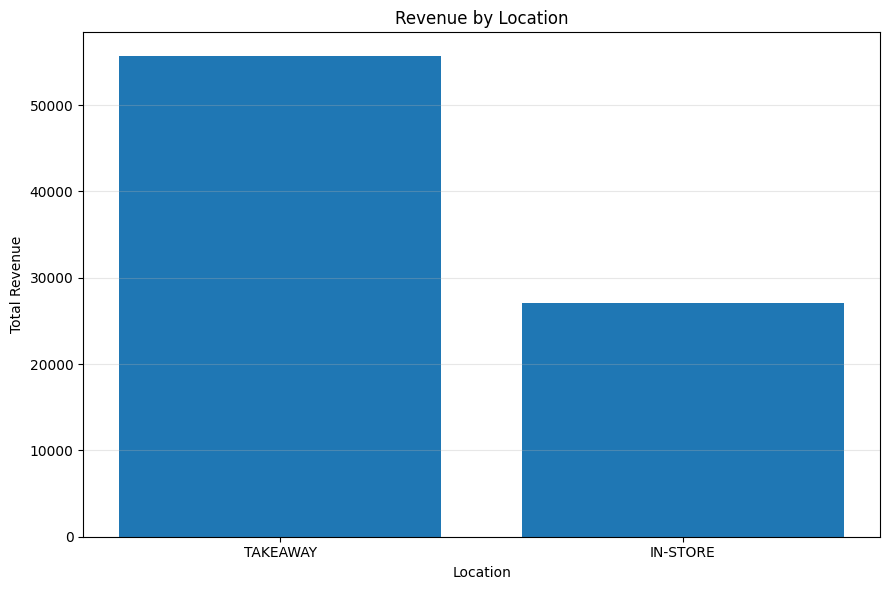

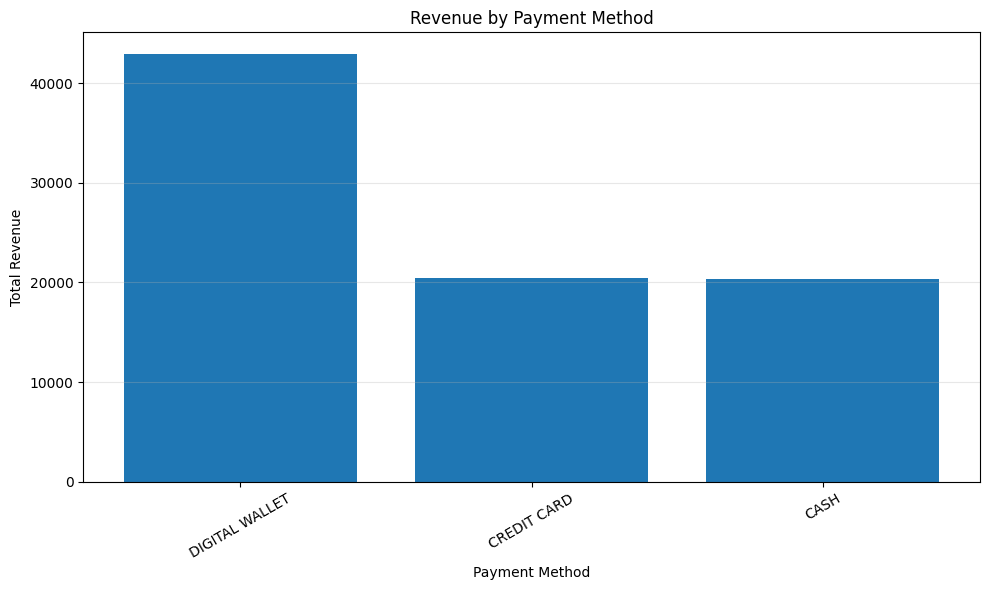

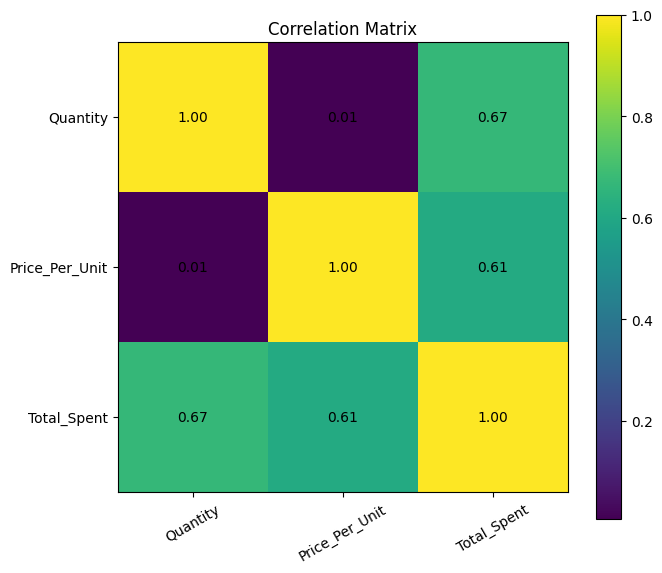

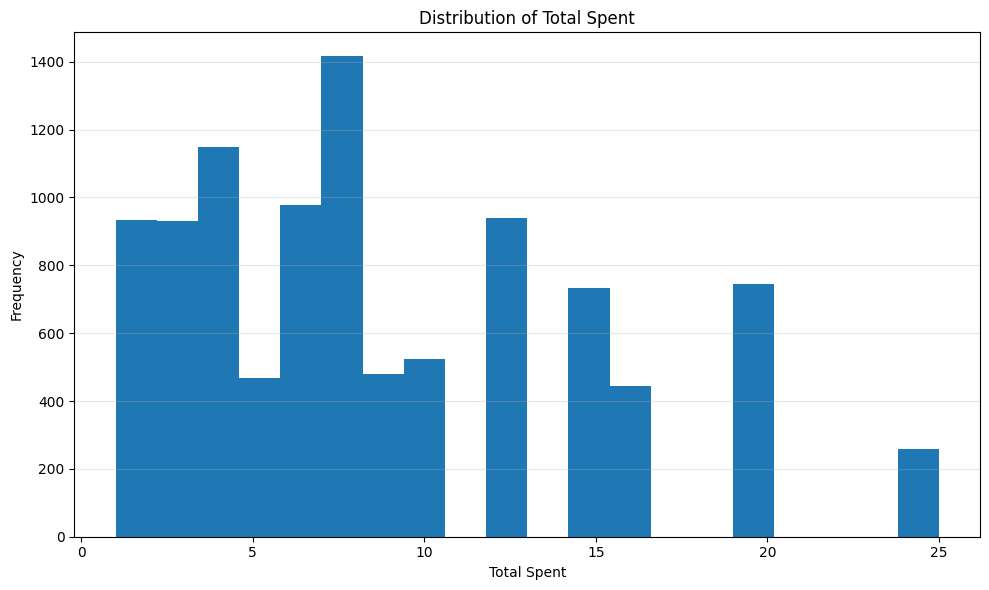


Insight Report berhasil dibuat: Insight_Report.pdf
Business Recommendation berhasil dibuat: Business_Recommendation.pdf

Final Presentation berhasil dibuat: Final_Presentation.pptx

FINAL PROJECT EDA SELESAI

FILE YANG BERHASIL DIBUAT:
✓ Insight_Report.pdf (528.46 KB)
✓ Business_Recommendation.pdf (4.31 KB)
✓ Final_Presentation.pptx (348.55 KB)

KEY FINAL INSIGHTS
Total Revenue        : 88,779.50
Total Transactions   : 10,000
Average Transaction  : 8.88
Top Product          : SALAD
Top Product Revenue  : 17,021.00
Top Location         : TAKEAWAY
Top Payment          : DIGITAL WALLET
Highest Month        : October
Lowest Month         : February
Quantity Correlation : 0.6688
Price Correlation    : 0.6124
Total_Spent Outlier  : 259
Missing Date         : 460

Memulai download file final...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Semua file final siap digunakan.


In [ ]:
# ============================================================
# WEEK 7 - HARI JUMAT
# FINAL PROJECT EDA
# ============================================================
#
# OUTPUT:
# 1. Insight_Report.pdf
# 2. Business_Recommendation.pdf
# 3. Final_Presentation.pptx
#
# Dataset:
# Final Clean Dataset.csv
# ============================================================


# ============================================================
# 0. INSTALL DEPENDENCIES
# ============================================================

!pip -q install reportlab python-pptx openpyxl


# ============================================================
# 1. IMPORT LIBRARY
# ============================================================

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER, TA_LEFT
from reportlab.lib.units import cm
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    PageBreak,
    Image
)

from pptx import Presentation
from pptx.util import Inches, Pt


print("=" * 70)
print("WEEK 7 - HARI JUMAT | FINAL PROJECT EDA")
print("=" * 70)


# ============================================================
# 2. LOAD DATASET
# ============================================================

csv_files = [
    f for f in os.listdir(".")
    if f.lower().endswith(".csv")
]

if not csv_files:

    print("Dataset CSV belum ditemukan.")
    print("Silakan upload Final Clean Dataset.csv")

    uploaded = files.upload()

    csv_files = [
        f for f in uploaded.keys()
        if f.lower().endswith(".csv")
    ]


if not csv_files:

    raise FileNotFoundError(
        "Dataset CSV tidak ditemukan."
    )


preferred_files = [
    f for f in csv_files
    if "final clean dataset" in f.lower()
]

if preferred_files:
    file_path = preferred_files[0]
else:
    file_path = csv_files[0]


df = pd.read_csv(file_path)


print("\nDataset berhasil dimuat.")
print(f"File        : {file_path}")
print(f"Rows        : {len(df):,}")
print(f"Columns     : {len(df.columns)}")


# ============================================================
# 3. DATA PREPARATION
# ============================================================

df["Transaction_Date"] = pd.to_datetime(
    df["Transaction_Date"],
    errors="coerce"
)

for col in [
    "Quantity",
    "Price_Per_Unit",
    "Total_Spent"
]:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# 4. DATASET PROFILE
# ============================================================

total_rows = len(df)

total_columns = len(df.columns)

missing_total = df.isna().sum().sum()

duplicate_total = df.duplicated().sum()

missing_date = df["Transaction_Date"].isna().sum()

date_available = df["Transaction_Date"].notna().sum()


print("\n" + "=" * 70)
print("DATASET PROFILE")
print("=" * 70)

print(f"Rows                    : {total_rows:,}")
print(f"Columns                 : {total_columns}")
print(f"Total missing cells     : {missing_total:,}")
print(f"Duplicate rows          : {duplicate_total:,}")
print(f"Missing Transaction Date: {missing_date:,}")


# ============================================================
# 5. DESCRIPTIVE STATISTICS
# ============================================================

numeric_cols = [
    "Quantity",
    "Price_Per_Unit",
    "Total_Spent"
]

desc = df[numeric_cols].describe().T

desc["median"] = df[numeric_cols].median()

desc["mode"] = [
    df[col].mode().iloc[0]
    for col in numeric_cols
]

desc["range"] = (
    desc["max"] -
    desc["min"]
)


print("\n" + "=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)

display(desc)


# ============================================================
# 6. KPI
# ============================================================

total_revenue = df["Total_Spent"].sum()

total_transactions = len(df)

average_transaction = df["Total_Spent"].mean()

median_transaction = df["Total_Spent"].median()

total_quantity = df["Quantity"].sum()


print("\n" + "=" * 70)
print("KPI")
print("=" * 70)

print(
    f"Total Revenue      : {total_revenue:,.2f}"
)

print(
    f"Transactions       : {total_transactions:,}"
)

print(
    f"Average Transaction: {average_transaction:,.2f}"
)

print(
    f"Median Transaction : {median_transaction:,.2f}"
)

print(
    f"Total Quantity     : {total_quantity:,.0f}"
)


# ============================================================
# 7. PRODUCT ANALYSIS
# ============================================================

product = (
    df.groupby("Item")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Quantity=("Quantity", "sum"),
        Total_Spent=("Total_Spent", "sum"),
        Average_Spent=("Total_Spent", "mean")
    )
    .reset_index()
)

product["Revenue_Share_%"] = (
    product["Total_Spent"]
    / product["Total_Spent"].sum()
    * 100
)

product = product.sort_values(
    "Total_Spent",
    ascending=False
).reset_index(drop=True)


# Ambil produk bisnis valid
valid_product = product[
    ~product["Item"].isin(
        ["UNKNOWN", "ERROR"]
    )
].copy()

valid_product = valid_product.sort_values(
    "Total_Spent",
    ascending=False
).reset_index(drop=True)


top_product = valid_product.iloc[0]

second_product = valid_product.iloc[1]

lowest_product = valid_product.iloc[-1]


# ============================================================
# 8. LOCATION ANALYSIS
# ============================================================

location = (
    df.groupby("Location")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Quantity=("Quantity", "sum"),
        Total_Spent=("Total_Spent", "sum"),
        Average_Spent=("Total_Spent", "mean")
    )
    .reset_index()
)

location["Revenue_Share_%"] = (
    location["Total_Spent"]
    / location["Total_Spent"].sum()
    * 100
)

location = location.sort_values(
    "Total_Spent",
    ascending=False
).reset_index(drop=True)


valid_location = location[
    ~location["Location"].isin(
        ["UNKNOWN", "ERROR"]
    )
].copy()

valid_location = valid_location.sort_values(
    "Total_Spent",
    ascending=False
).reset_index(drop=True)


top_location = valid_location.iloc[0]


# ============================================================
# 9. PAYMENT ANALYSIS
# ============================================================

payment = (
    df.groupby("Payment_Method")
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Quantity=("Quantity", "sum"),
        Total_Spent=("Total_Spent", "sum"),
        Average_Spent=("Total_Spent", "mean")
    )
    .reset_index()
)

payment["Revenue_Share_%"] = (
    payment["Total_Spent"]
    / payment["Total_Spent"].sum()
    * 100
)

payment = payment.sort_values(
    "Total_Spent",
    ascending=False
).reset_index(drop=True)


valid_payment = payment[
    ~payment["Payment_Method"].isin(
        ["UNKNOWN", "ERROR"]
    )
].copy()

valid_payment = valid_payment.sort_values(
    "Total_Spent",
    ascending=False
).reset_index(drop=True)


top_payment = valid_payment.iloc[0]


# ============================================================
# 10. MONTHLY TREND
# ============================================================

temporal = df.dropna(
    subset=["Transaction_Date"]
).copy()

temporal["Month_Number"] = (
    temporal["Transaction_Date"].dt.month
)

temporal["Month_Name"] = (
    temporal["Transaction_Date"].dt.strftime("%B")
)


monthly = (
    temporal
    .groupby(
        ["Month_Number", "Month_Name"]
    )
    .agg(
        Transaction_Count=("Transaction_ID", "count"),
        Total_Quantity=("Quantity", "sum"),
        Total_Spent=("Total_Spent", "sum"),
        Average_Spent=("Total_Spent", "mean")
    )
    .reset_index()
    .sort_values("Month_Number")
)

monthly["MoM_Growth_%"] = (
    monthly["Total_Spent"]
    .pct_change()
    * 100
)

monthly = monthly.reset_index(
    drop=True
)


highest_month = monthly.loc[
    monthly["Total_Spent"].idxmax()
]

lowest_month = monthly.loc[
    monthly["Total_Spent"].idxmin()
]


# ============================================================
# 11. CORRELATION
# ============================================================

corr = df[
    [
        "Quantity",
        "Price_Per_Unit",
        "Total_Spent"
    ]
].corr()


quantity_corr = corr.loc[
    "Quantity",
    "Total_Spent"
]

price_corr = corr.loc[
    "Price_Per_Unit",
    "Total_Spent"
]


# ============================================================
# 12. OUTLIER ANALYSIS
# ============================================================

def iqr_outlier_count(series):

    q1 = series.quantile(0.25)

    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr

    upper = q3 + 1.5 * iqr

    mask = (
        (series < lower) |
        (series > upper)
    )

    return mask.sum(), lower, upper


quantity_outliers, q_low, q_high = (
    iqr_outlier_count(
        df["Quantity"]
    )
)

price_outliers, p_low, p_high = (
    iqr_outlier_count(
        df["Price_Per_Unit"]
    )
)

spent_outliers, s_low, s_high = (
    iqr_outlier_count(
        df["Total_Spent"]
    )
)


outlier_revenue = df.loc[
    (
        df["Total_Spent"] < s_low
    ) |
    (
        df["Total_Spent"] > s_high
    ),
    "Total_Spent"
].sum()


outlier_revenue_share = (
    outlier_revenue /
    total_revenue *
    100
)


# ============================================================
# 13. DATA QUALITY
# ============================================================

quality = {
    "Missing Transaction Date": missing_date,
    "Item UNKNOWN": (
        df["Item"] == "UNKNOWN"
    ).sum(),
    "Item ERROR": (
        df["Item"] == "ERROR"
    ).sum(),
    "Payment UNKNOWN": (
        df["Payment_Method"] == "UNKNOWN"
    ).sum(),
    "Payment ERROR": (
        df["Payment_Method"] == "ERROR"
    ).sum(),
    "Location UNKNOWN": (
        df["Location"] == "UNKNOWN"
    ).sum(),
    "Location ERROR": (
        df["Location"] == "ERROR"
    ).sum(),
    "Duplicate Rows": duplicate_total
}


# ============================================================
# 14. PRINT FINAL INSIGHTS
# ============================================================

print("\n" + "=" * 70)
print("FINAL EDA INSIGHTS")
print("=" * 70)

print(
    f"1. Total revenue dataset adalah "
    f"{total_revenue:,.2f}."
)

print(
    f"2. Produk dengan revenue terbesar adalah "
    f"{top_product['Item']} sebesar "
    f"{top_product['Total_Spent']:,.2f} "
    f"({top_product['Revenue_Share_%']:.2f}%)."
)

print(
    f"3. Lokasi dengan revenue terbesar adalah "
    f"{top_location['Location']} sebesar "
    f"{top_location['Total_Spent']:,.2f} "
    f"({top_location['Revenue_Share_%']:.2f}%)."
)

print(
    f"4. Payment method dengan revenue terbesar adalah "
    f"{top_payment['Payment_Method']} sebesar "
    f"{top_payment['Total_Spent']:,.2f} "
    f"({top_payment['Revenue_Share_%']:.2f}%)."
)

print(
    f"5. Bulan dengan revenue tertinggi adalah "
    f"{highest_month['Month_Name']} sebesar "
    f"{highest_month['Total_Spent']:,.2f}."
)

print(
    f"6. Bulan dengan revenue terendah adalah "
    f"{lowest_month['Month_Name']} sebesar "
    f"{lowest_month['Total_Spent']:,.2f}."
)

print(
    f"7. Korelasi Quantity terhadap Total_Spent "
    f"adalah {quantity_corr:.4f}."
)

print(
    f"8. Korelasi Price_Per_Unit terhadap Total_Spent "
    f"adalah {price_corr:.4f}."
)

print(
    f"9. Ditemukan {spent_outliers} outlier "
    f"pada Total_Spent berdasarkan metode IQR."
)

print(
    f"10. Terdapat {missing_date} transaksi "
    f"dengan Transaction_Date yang kosong."
)


# ============================================================
# 15. CREATE VISUALIZATION FILES
# ============================================================

print("\nMembuat visualisasi final...")


# ------------------------------------------------------------
# Chart 1 - Monthly Revenue
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    monthly["Month_Name"],
    monthly["Total_Spent"],
    marker="o"
)

plt.title(
    "Monthly Revenue Trend - 2023"
)

plt.xlabel("Month")

plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

monthly_chart = (
    "final_monthly_trend.png"
)

plt.savefig(
    monthly_chart,
    dpi=180
)

plt.show()

plt.close()


# ------------------------------------------------------------
# Chart 2 - Product Revenue
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    valid_product["Item"],
    valid_product["Total_Spent"]
)

plt.title(
    "Revenue by Product"
)

plt.xlabel("Product")

plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

product_chart = (
    "final_product_revenue.png"
)

plt.savefig(
    product_chart,
    dpi=180
)

plt.show()

plt.close()


# ------------------------------------------------------------
# Chart 3 - Location Revenue
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.bar(
    valid_location["Location"],
    valid_location["Total_Spent"]
)

plt.title(
    "Revenue by Location"
)

plt.xlabel("Location")

plt.ylabel("Total Revenue")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

location_chart = (
    "final_location_revenue.png"
)

plt.savefig(
    location_chart,
    dpi=180
)

plt.show()

plt.close()


# ------------------------------------------------------------
# Chart 4 - Payment Revenue
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    valid_payment["Payment_Method"],
    valid_payment["Total_Spent"]
)

plt.title(
    "Revenue by Payment Method"
)

plt.xlabel("Payment Method")

plt.ylabel("Total Revenue")

plt.xticks(rotation=30)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

payment_chart = (
    "final_payment_revenue.png"
)

plt.savefig(
    payment_chart,
    dpi=180
)

plt.show()

plt.close()


# ------------------------------------------------------------
# Chart 5 - Correlation Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.imshow(
    corr,
    interpolation="nearest"
)

plt.title(
    "Correlation Matrix"
)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=30
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar()

for i in range(
    len(corr.columns)
):

    for j in range(
        len(corr.columns)
    ):

        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()

correlation_chart = (
    "final_correlation.png"
)

plt.savefig(
    correlation_chart,
    dpi=180
)

plt.show()

plt.close()


# ------------------------------------------------------------
# Chart 6 - Total Spent Distribution
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    df["Total_Spent"],
    bins=20
)

plt.title(
    "Distribution of Total Spent"
)

plt.xlabel(
    "Total Spent"
)

plt.ylabel(
    "Frequency"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

distribution_chart = (
    "final_distribution.png"
)

plt.savefig(
    distribution_chart,
    dpi=180
)

plt.show()

plt.close()


# ============================================================
# 16. PDF STYLE
# ============================================================

styles = getSampleStyleSheet()

title_style = ParagraphStyle(
    "CustomTitle",
    parent=styles["Title"],
    fontSize=20,
    leading=24,
    alignment=TA_CENTER,
    spaceAfter=15
)

subtitle_style = ParagraphStyle(
    "Subtitle",
    parent=styles["Normal"],
    fontSize=11,
    leading=16,
    alignment=TA_CENTER,
    spaceAfter=20
)

heading_style = ParagraphStyle(
    "Heading",
    parent=styles["Heading2"],
    fontSize=14,
    leading=18,
    spaceBefore=10,
    spaceAfter=8
)

body_style = ParagraphStyle(
    "Body",
    parent=styles["BodyText"],
    fontSize=10,
    leading=15,
    alignment=TA_LEFT,
    spaceAfter=7
)


# ============================================================
# 17. CREATE INSIGHT REPORT PDF
# ============================================================

insight_pdf = "Insight_Report.pdf"

doc = SimpleDocTemplate(
    insight_pdf,
    pagesize=A4,
    rightMargin=1.5 * cm,
    leftMargin=1.5 * cm,
    topMargin=1.5 * cm,
    bottomMargin=1.5 * cm
)

story = []


story.append(
    Paragraph(
        "INSIGHT REPORT",
        title_style
    )
)

story.append(
    Paragraph(
        "Week 7 - Final Project Exploratory Data Analysis",
        subtitle_style
    )
)


story.append(
    Paragraph(
        "1. Gambaran Dataset",
        heading_style
    )
)

story.append(
    Paragraph(
        f"Dataset yang digunakan adalah dataset transaksi "
        f"coffee shop tahun 2023 dengan {total_rows:,} "
        f"baris dan {total_columns} kolom. Dataset berisi "
        f"informasi transaksi, produk, jumlah pembelian, "
        f"harga satuan, total transaksi, metode pembayaran, "
        f"lokasi dan tanggal transaksi.",
        body_style
    )
)


dataset_table = [
    ["Metric", "Value"],
    ["Rows", f"{total_rows:,}"],
    ["Columns", f"{total_columns}"],
    ["Total Revenue", f"{total_revenue:,.2f}"],
    ["Average Transaction", f"{average_transaction:,.2f}"],
    ["Median Transaction", f"{median_transaction:,.2f}"],
    ["Total Quantity", f"{total_quantity:,.0f}"],
    ["Duplicate Rows", f"{duplicate_total:,}"],
    ["Missing Transaction Date", f"{missing_date:,}"]
]


table = Table(
    dataset_table,
    colWidths=[9 * cm, 7 * cm]
)

table.setStyle(
    TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#1F4E78")),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
        ("ALIGN", (0, 0), (-1, -1), "CENTER"),
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE")
    ])
)

story.append(table)

story.append(Spacer(1, 15))


# ============================================================
# STATISTICAL SUMMARY
# ============================================================

story.append(
    Paragraph(
        "2. Statistik Deskriptif",
        heading_style
    )
)

story.append(
    Paragraph(
        f"Rata-rata nilai transaksi adalah "
        f"{average_transaction:,.2f}, sedangkan median "
        f"sebesar {median_transaction:,.2f}. "
        f"Quantity memiliki rata-rata "
        f"{df['Quantity'].mean():.2f} item per transaksi "
        f"dan Price_Per_Unit memiliki rata-rata "
        f"{df['Price_Per_Unit'].mean():.2f}.",
        body_style
    )
)

story.append(
    Image(
        distribution_chart,
        width=16 * cm,
        height=9 * cm
    )
)


# ============================================================
# PRODUCT INSIGHT
# ============================================================

story.append(
    Paragraph(
        "3. Insight Produk",
        heading_style
    )
)

story.append(
    Paragraph(
        f"{top_product['Item']} merupakan produk dengan "
        f"kontribusi revenue terbesar, yaitu "
        f"{top_product['Total_Spent']:,.2f} atau "
        f"{top_product['Revenue_Share_%']:.2f}% dari "
        f"total revenue. Produk berikutnya adalah "
        f"{second_product['Item']} dengan revenue "
        f"{second_product['Total_Spent']:,.2f}.",
        body_style
    )
)

story.append(
    Image(
        product_chart,
        width=16 * cm,
        height=8 * cm
    )
)


# ============================================================
# LOCATION INSIGHT
# ============================================================

story.append(
    Paragraph(
        "4. Insight Lokasi",
        heading_style
    )
)

story.append(
    Paragraph(
        f"{top_location['Location']} merupakan lokasi "
        f"dengan kontribusi revenue terbesar sebesar "
        f"{top_location['Total_Spent']:,.2f}, atau "
        f"{top_location['Revenue_Share_%']:.2f}% dari "
        f"total revenue.",
        body_style
    )
)

story.append(
    Image(
        location_chart,
        width=16 * cm,
        height=8 * cm
    )
)


# ============================================================
# PAYMENT INSIGHT
# ============================================================

story.append(
    Paragraph(
        "5. Insight Metode Pembayaran",
        heading_style
    )
)

story.append(
    Paragraph(
        f"{top_payment['Payment_Method']} merupakan "
        f"metode pembayaran dengan revenue terbesar, "
        f"yaitu {top_payment['Total_Spent']:,.2f} atau "
        f"{top_payment['Revenue_Share_%']:.2f}% dari "
        f"total revenue.",
        body_style
    )
)

story.append(
    Image(
        payment_chart,
        width=16 * cm,
        height=8 * cm
    )
)


# ============================================================
# TREND INSIGHT
# ============================================================

story.append(
    Paragraph(
        "6. Insight Tren",
        heading_style
    )
)

story.append(
    Paragraph(
        f"Pada tahun 2023, revenue tertinggi terjadi pada "
        f"{highest_month['Month_Name']} sebesar "
        f"{highest_month['Total_Spent']:,.2f}, sedangkan "
        f"revenue terendah terjadi pada "
        f"{lowest_month['Month_Name']} sebesar "
        f"{lowest_month['Total_Spent']:,.2f}. "
        f"Pola bulanan menunjukkan fluktuasi dan belum "
        f"menunjukkan tren pertumbuhan jangka panjang "
        f"yang konsisten.",
        body_style
    )
)

story.append(
    Image(
        monthly_chart,
        width=16 * cm,
        height=8 * cm
    )
)


# ============================================================
# CORRELATION
# ============================================================

story.append(
    Paragraph(
        "7. Relationship Analysis",
        heading_style
    )
)

story.append(
    Paragraph(
        f"Quantity memiliki korelasi positif sebesar "
        f"{quantity_corr:.4f} terhadap Total_Spent. "
        f"Price_Per_Unit memiliki korelasi positif sebesar "
        f"{price_corr:.4f} terhadap Total_Spent. "
        f"Hasil ini menunjukkan hubungan linear positif, "
        f"namun korelasi tidak dapat digunakan untuk "
        f"menyimpulkan hubungan sebab-akibat.",
        body_style
    )
)

story.append(
    Image(
        correlation_chart,
        width=13 * cm,
        height=11 * cm
    )
)


# ============================================================
# OUTLIER
# ============================================================

story.append(
    Paragraph(
        "8. Outlier Analysis",
        heading_style
    )
)

story.append(
    Paragraph(
        f"Berdasarkan metode IQR, ditemukan "
        f"{quantity_outliers} outlier pada Quantity, "
        f"{price_outliers} outlier pada Price_Per_Unit, "
        f"dan {spent_outliers} outlier pada Total_Spent. "
        f"Nilai Total_Spent maksimum adalah "
        f"{df['Total_Spent'].max():,.2f}. "
        f"Outlier tidak langsung dianggap sebagai kesalahan "
        f"karena transaksi ekstrem dapat merupakan transaksi "
        f"yang valid.",
        body_style
    )
)


# ============================================================
# DATA QUALITY
# ============================================================

story.append(
    Paragraph(
        "9. Data Quality",
        heading_style
    )
)

story.append(
    Paragraph(
        f"Terdapat {missing_date} baris dengan "
        f"Transaction_Date yang kosong. Selain itu terdapat "
        f"nilai UNKNOWN dan ERROR pada Item, Payment_Method "
        f"dan Location. Tidak ditemukan duplicate rows. "
        f"UNKNOWN dan ERROR diperlakukan sebagai masalah "
        f"kualitas data, bukan sebagai kategori bisnis.",
        body_style
    )
)


# ============================================================
# EXECUTIVE SUMMARY
# ============================================================

story.append(
    Paragraph(
        "10. Executive Summary",
        heading_style
    )
)

summary_points = [
    f"Total revenue mencapai {total_revenue:,.2f}.",
    f"{top_product['Item']} menjadi produk dengan kontribusi revenue terbesar.",
    f"{top_location['Location']} menjadi channel/lokasi dengan revenue terbesar.",
    f"{top_payment['Payment_Method']} menjadi metode pembayaran dominan.",
    f"{highest_month['Month_Name']} merupakan bulan dengan revenue tertinggi.",
    f"Quantity memiliki korelasi positif paling kuat terhadap Total_Spent.",
    f"Outlier pada Total_Spent perlu divalidasi, bukan langsung dihapus.",
    f"Data quality perlu diperbaiki terutama pada tanggal dan placeholder UNKNOWN/ERROR."
]


for point in summary_points:

    story.append(
        Paragraph(
            "• " + point,
            body_style
        )
    )


doc.build(story)


print(
    f"\nInsight Report berhasil dibuat: {insight_pdf}"
)


# ============================================================
# 18. CREATE BUSINESS RECOMMENDATION PDF
# ============================================================

recommendation_pdf = (
    "Business_Recommendation.pdf"
)

doc = SimpleDocTemplate(
    recommendation_pdf,
    pagesize=A4,
    rightMargin=1.5 * cm,
    leftMargin=1.5 * cm,
    topMargin=1.5 * cm,
    bottomMargin=1.5 * cm
)

story = []


story.append(
    Paragraph(
        "BUSINESS RECOMMENDATION",
        title_style
    )
)

story.append(
    Paragraph(
        "Final Project - Week 7 EDA",
        subtitle_style
    )
)


# ------------------------------------------------------------
# Recommendation 1
# ------------------------------------------------------------

story.append(
    Paragraph(
        "1. Prioritaskan Produk dengan Revenue Tinggi",
        heading_style
    )
)

story.append(
    Paragraph(
        f"{top_product['Item']} menghasilkan revenue "
        f"terbesar sebesar {top_product['Total_Spent']:,.2f}. "
        f"Manajemen dapat menjadikan produk tersebut "
        f"sebagai prioritas dalam pengelolaan stok, "
        f"ketersediaan bahan dan promosi.",
        body_style
    )
)


# ------------------------------------------------------------
# Recommendation 2
# ------------------------------------------------------------

story.append(
    Paragraph(
        "2. Optimalkan Channel TAKEAWAY",
        heading_style
    )
)

story.append(
    Paragraph(
        f"Channel/lokasi {top_location['Location']} "
        f"menyumbang {top_location['Revenue_Share_%']:.2f}% "
        f"revenue. Operasional pada channel tersebut "
        f"perlu dijaga agar kapasitas pelayanan tetap "
        f"mampu menangani volume transaksi.",
        body_style
    )
)


# ------------------------------------------------------------
# Recommendation 3
# ------------------------------------------------------------

story.append(
    Paragraph(
        "3. Pertahankan Kualitas Layanan Digital Wallet",
        heading_style
    )
)

story.append(
    Paragraph(
        f"{top_payment['Payment_Method']} menghasilkan "
        f"revenue {top_payment['Total_Spent']:,.2f}. "
        f"Karena merupakan metode pembayaran dominan, "
        f"ketersediaan dan keandalan sistem pembayaran "
        f"tersebut perlu dijaga.",
        body_style
    )
)


# ------------------------------------------------------------
# Recommendation 4
# ------------------------------------------------------------

story.append(
    Paragraph(
        "4. Evaluasi Performa Bulanan",
        heading_style
    )
)

story.append(
    Paragraph(
        f"{highest_month['Month_Name']} menghasilkan "
        f"revenue tertinggi sebesar "
        f"{highest_month['Total_Spent']:,.2f}, sedangkan "
        f"{lowest_month['Month_Name']} menjadi bulan "
        f"terendah dengan revenue "
        f"{lowest_month['Total_Spent']:,.2f}. "
        f"Perbedaan ini dapat digunakan sebagai dasar "
        f"untuk mengevaluasi aktivitas promosi dan "
        f"operasional pada bulan dengan performa rendah.",
        body_style
    )
)


# ------------------------------------------------------------
# Recommendation 5
# ------------------------------------------------------------

story.append(
    Paragraph(
        "5. Gunakan Median untuk Monitoring Transaksi",
        heading_style
    )
)

story.append(
    Paragraph(
        f"Karena terdapat outlier pada Total_Spent, "
        f"median sebesar {median_transaction:,.2f} "
        f"sebaiknya digunakan bersama mean sebesar "
        f"{average_transaction:,.2f} ketika melakukan "
        f"monitoring nilai transaksi.",
        body_style
    )
)


# ------------------------------------------------------------
# Recommendation 6
# ------------------------------------------------------------

story.append(
    Paragraph(
        "6. Perbaiki Data Quality",
        heading_style
    )
)

story.append(
    Paragraph(
        f"Terdapat {missing_date} transaksi tanpa "
        f"Transaction_Date serta sejumlah nilai UNKNOWN "
        f"dan ERROR. Sistem pencatatan transaksi perlu "
        f"menggunakan validasi input agar data yang masuk "
        f"lebih konsisten.",
        body_style
    )
)


# ------------------------------------------------------------
# Recommendation 7
# ------------------------------------------------------------

story.append(
    Paragraph(
        "7. Validasi Outlier sebelum Penghapusan",
        heading_style
    )
)

story.append(
    Paragraph(
        f"Terdapat {spent_outliers} outlier pada "
        f"Total_Spent berdasarkan metode IQR. "
        f"Outlier sebaiknya diperiksa berdasarkan "
        f"Quantity, Price_Per_Unit dan Item sebelum "
        f"diputuskan untuk dipertahankan atau diperbaiki.",
        body_style
    )
)


# ------------------------------------------------------------
# Opportunity
# ------------------------------------------------------------

story.append(
    Paragraph(
        "8. Peluang Bisnis",
        heading_style
    )
)

opportunities = [
    "Membuat promosi khusus untuk produk dengan revenue tinggi.",
    "Membuat bundling produk untuk meningkatkan nilai transaksi.",
    "Mengoptimalkan pelayanan TAKEAWAY pada jam operasional sibuk.",
    "Mempertahankan kemudahan pembayaran melalui DIGITAL WALLET.",
    "Melakukan evaluasi promosi pada bulan dengan revenue rendah.",
    "Mengembangkan dashboard monitoring penjualan secara berkala."
]


for item in opportunities:

    story.append(
        Paragraph(
            "• " + item,
            body_style
        )
    )


# ------------------------------------------------------------
# Priority Matrix
# ------------------------------------------------------------

story.append(
    Paragraph(
        "9. Prioritas Implementasi",
        heading_style
    )
)

priority_table = [
    [
        "Prioritas",
        "Action",
        "Impact"
    ],
    [
        "High",
        "Perbaikan data quality",
        "High"
    ],
    [
        "High",
        "Optimasi produk revenue tinggi",
        "High"
    ],
    [
        "High",
        "Menjaga channel TAKEAWAY",
        "High"
    ],
    [
        "Medium",
        "Optimasi DIGITAL WALLET",
        "Medium"
    ],
    [
        "Medium",
        "Evaluasi bulan revenue rendah",
        "Medium"
    ],
    [
        "Low",
        "Eksplorasi segmentasi lanjutan",
        "Medium"
    ]
]


priority = Table(
    priority_table,
    colWidths=[
        3 * cm,
        9 * cm,
        4 * cm
    ]
)

priority.setStyle(
    TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#1F4E78")),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
        ("ALIGN", (0, 0), (-1, -1), "CENTER"),
        ("VALIGN", (0, 0), (-1, -1), "MIDDLE")
    ])
)

story.append(priority)

story.append(Spacer(1, 15))


story.append(
    Paragraph(
        "Kesimpulan",
        heading_style
    )
)

story.append(
    Paragraph(
        "Hasil EDA menunjukkan bahwa performa penjualan "
        "dipengaruhi oleh kombinasi produk, channel transaksi "
        "dan metode pembayaran. Fokus utama bisnis sebaiknya "
        "diarahkan pada mempertahankan produk dan channel "
        "dengan kontribusi tinggi, meningkatkan kualitas data, "
        "serta melakukan monitoring tren penjualan secara "
        "berkala.",
        body_style
    )
)


doc.build(story)


print(
    f"Business Recommendation berhasil dibuat: "
    f"{recommendation_pdf}"
)


# ============================================================
# 19. CREATE FINAL PRESENTATION
# ============================================================

ppt_file = (
    "Final_Presentation.pptx"
)

prs = Presentation()

prs.slide_width = Inches(13.333)

prs.slide_height = Inches(7.5)


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def add_title(
    slide,
    title,
    subtitle=None
):

    title_box = slide.shapes.add_textbox(
        Inches(0.6),
        Inches(0.3),
        Inches(12),
        Inches(0.7)
    )

    title_frame = title_box.text_frame

    title_frame.text = title

    title_frame.paragraphs[0].font.size = Pt(28)

    title_frame.paragraphs[0].font.bold = True


    if subtitle:

        sub_box = slide.shapes.add_textbox(
            Inches(0.6),
            Inches(1.0),
            Inches(12),
            Inches(0.5)
        )

        sub_box.text_frame.text = subtitle

        sub_box.text_frame.paragraphs[0].font.size = Pt(14)


def add_bullets(
    slide,
    bullets,
    x=0.8,
    y=1.5,
    width=11.5,
    height=5
):

    box = slide.shapes.add_textbox(
        Inches(x),
        Inches(y),
        Inches(width),
        Inches(height)
    )

    tf = box.text_frame

    tf.word_wrap = True

    tf.clear()

    for i, bullet in enumerate(bullets):

        if i == 0:

            p = tf.paragraphs[0]

        else:

            p = tf.add_paragraph()

        p.text = bullet

        p.font.size = Pt(18)

        p.space_after = Pt(12)

        p.level = 0


def add_picture_slide(
    title,
    image_path,
    caption=None
):

    slide = prs.slides.add_slide(
        prs.slide_layouts[6]
    )

    add_title(
        slide,
        title,
        caption
    )

    slide.shapes.add_picture(
        image_path,
        Inches(1.0),
        Inches(1.3),
        width=Inches(11.3)
    )

    return slide


# ============================================================
# SLIDE 1
# ============================================================

slide = prs.slides.add_slide(
    prs.slide_layouts[6]
)

add_title(
    slide,
    "FINAL PROJECT EDA",
    "Coffee Shop Sales Dataset - 2023"
)

add_bullets(
    slide,
    [
        "Week 7 - Exploratory Data Analysis Advanced",
        f"Dataset: {total_rows:,} transaksi",
        f"Total Revenue: {total_revenue:,.2f}",
        "Junior Data Analyst Simulation"
    ],
    y=1.8
)


# ============================================================
# SLIDE 2
# ============================================================

slide = prs.slides.add_slide(
    prs.slide_layouts[6]
)

add_title(
    slide,
    "1. Gambaran Dataset"
)

add_bullets(
    slide,
    [
        f"Jumlah data: {total_rows:,} baris dan {total_columns} kolom.",
        "Dataset berisi transaksi coffee shop tahun 2023.",
        "Variabel utama: Item, Quantity, Price_Per_Unit, Total_Spent.",
        "Dimensi tambahan: Payment_Method, Location, Transaction_Date.",
        f"Duplicate rows: {duplicate_total}.",
        f"Missing Transaction_Date: {missing_date} baris."
    ]
)


# ============================================================
# SLIDE 3
# ============================================================

slide = prs.slides.add_slide(
    prs.slide_layouts[6]
)

add_title(
    slide,
    "2. Statistik Deskriptif"
)

add_bullets(
    slide,
    [
        f"Mean Total_Spent: {average_transaction:,.2f}.",
        f"Median Total_Spent: {median_transaction:,.2f}.",
        f"Mean Quantity: {df['Quantity'].mean():.2f}.",
        f"Mean Price_Per_Unit: {df['Price_Per_Unit'].mean():.2f}.",
        f"Total Quantity: {total_quantity:,.0f}.",
        "Median digunakan bersama mean karena terdapat outlier."
    ]
)


# ============================================================
# SLIDE 4
# ============================================================

add_picture_slide(
    "3. Tren Penjualan 2023",
    monthly_chart,
    "Revenue bulanan menunjukkan pola fluktuatif."
)


# ============================================================
# SLIDE 5
# ============================================================

add_picture_slide(
    "4. Revenue berdasarkan Produk",
    product_chart,
    (
        f"Produk tertinggi: {top_product['Item']} "
        f"({top_product['Total_Spent']:,.2f})"
    )
)


# ============================================================
# SLIDE 6
# ============================================================

add_picture_slide(
    "5. Revenue berdasarkan Lokasi",
    location_chart,
    (
        f"Lokasi tertinggi: {top_location['Location']} "
        f"({top_location['Revenue_Share_%']:.2f}% revenue)"
    )
)


# ============================================================
# SLIDE 7
# ============================================================

add_picture_slide(
    "6. Revenue berdasarkan Payment Method",
    payment_chart,
    (
        f"Payment method dominan: "
        f"{top_payment['Payment_Method']} "
        f"({top_payment['Revenue_Share_%']:.2f}%)"
    )
)


# ============================================================
# SLIDE 8
# ============================================================

add_picture_slide(
    "7. Correlation Analysis",
    correlation_chart,
    (
        f"Quantity vs Total_Spent: r={quantity_corr:.4f} | "
        f"Price vs Total_Spent: r={price_corr:.4f}"
    )
)


# ============================================================
# SLIDE 9
# ============================================================

slide = prs.slides.add_slide(
    prs.slide_layouts[6]
)

add_title(
    slide,
    "8. Insight Penting"
)

add_bullets(
    slide,
    [
        f"{top_product['Item']} menjadi produk dengan revenue terbesar.",
        f"{top_location['Location']} menjadi lokasi dengan revenue terbesar.",
        f"{top_payment['Payment_Method']} menjadi payment method dominan.",
        f"{highest_month['Month_Name']} menjadi bulan revenue tertinggi.",
        f"{lowest_month['Month_Name']} menjadi bulan revenue terendah.",
        f"Quantity memiliki korelasi positif sebesar {quantity_corr:.4f} terhadap Total_Spent."
    ]
)


# ============================================================
# SLIDE 10
# ============================================================

slide = prs.slides.add_slide(
    prs.slide_layouts[6]
)

add_title(
    slide,
    "9. Permasalahan Data"
)

add_bullets(
    slide,
    [
        f"{missing_date} transaksi memiliki Transaction_Date kosong.",
        f"{quality['Item UNKNOWN']} Item bernilai UNKNOWN.",
        f"{quality['Item ERROR']} Item bernilai ERROR.",
        f"{quality['Payment UNKNOWN']} Payment Method UNKNOWN.",
        f"{quality['Payment ERROR']} Payment Method ERROR.",
        f"{quality['Location UNKNOWN']} Location UNKNOWN.",
        f"{quality['Location ERROR']} Location ERROR.",
        "UNKNOWN dan ERROR bukan kategori bisnis."
    ]
)


# ============================================================
# SLIDE 11
# ============================================================

slide = prs.slides.add_slide(
    prs.slide_layouts[6]
)

add_title(
    slide,
    "10. Outlier Analysis"
)

add_bullets(
    slide,
    [
        f"Quantity outlier: {quantity_outliers}.",
        f"Price_Per_Unit outlier: {price_outliers}.",
        f"Total_Spent outlier: {spent_outliers}.",
        f"Maximum Total_Spent: {df['Total_Spent'].max():,.2f}.",
        "Outlier tidak otomatis berarti kesalahan.",
        "Transaksi ekstrem perlu divalidasi berdasarkan konteks."
    ]
)


# ============================================================
# SLIDE 12
# ============================================================

slide = prs.slides.add_slide(
    prs.slide_layouts[6]
)

add_title(
    slide,
    "11. Peluang Bisnis"
)

add_bullets(
    slide,
    [
        f"Optimasi produk {top_product['Item']} sebagai produk prioritas.",
        "Pengembangan bundling untuk meningkatkan nilai transaksi.",
        f"Optimasi operasional channel {top_location['Location']}.",
        f"Pertahankan kemudahan pembayaran {top_payment['Payment_Method']}.",
        f"Evaluasi strategi pada bulan {lowest_month['Month_Name']}.",
        "Monitoring penjualan melalui dashboard secara berkala."
    ]
)


# ============================================================
# SLIDE 13
# ============================================================

slide = prs.slides.add_slide(
    prs.slide_layouts[6]
)

add_title(
    slide,
    "12. Business Recommendation"
)

add_bullets(
    slide,
    [
        "1. Prioritaskan stok dan promosi produk dengan revenue tinggi.",
        "2. Jaga kapasitas operasional channel dengan volume tinggi.",
        "3. Pastikan sistem pembayaran digital tetap reliable.",
        "4. Gunakan median bersama mean untuk monitoring.",
        "5. Validasi outlier sebelum melakukan penghapusan.",
        "6. Perbaiki validasi data untuk mengurangi UNKNOWN/ERROR.",
        "7. Bangun monitoring dashboard secara berkala."
    ]
)


# ============================================================
# SLIDE 14
# ============================================================

slide = prs.slides.add_slide(
    prs.slide_layouts[6]
)

add_title(
    slide,
    "13. Kesimpulan"
)

add_bullets(
    slide,
    [
        f"Total revenue dataset: {total_revenue:,.2f}.",
        f"Produk utama: {top_product['Item']}.",
        f"Channel utama: {top_location['Location']}.",
        f"Payment method utama: {top_payment['Payment_Method']}.",
        "Penjualan bulanan bersifat fluktuatif.",
        "Quantity dan Price_Per_Unit memiliki hubungan positif dengan Total_Spent.",
        "Peningkatan kualitas data merupakan prioritas penting."
    ]
)


# ============================================================
# SLIDE 15
# ============================================================

slide = prs.slides.add_slide(
    prs.slide_layouts[6]
)

add_title(
    slide,
    "Terima Kasih",
    "Final Project - Exploratory Data Analysis"
)

add_bullets(
    slide,
    [
        "Questions & Discussion"
    ],
    y=2.8
)


# ============================================================
# SAVE PRESENTATION
# ============================================================

prs.save(
    ppt_file
)


print(
    f"\nFinal Presentation berhasil dibuat: "
    f"{ppt_file}"
)


# ============================================================
# 20. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL PROJECT EDA SELESAI")
print("=" * 70)

print("\nFILE YANG BERHASIL DIBUAT:")

for output in [
    insight_pdf,
    recommendation_pdf,
    ppt_file
]:

    if os.path.exists(output):

        size = os.path.getsize(output)

        print(
            f"✓ {output} "
            f"({size / 1024:.2f} KB)"
        )

    else:

        print(
            f"✗ {output} TIDAK DITEMUKAN"
        )


print("\n" + "=" * 70)
print("KEY FINAL INSIGHTS")
print("=" * 70)

print(
    f"Total Revenue        : {total_revenue:,.2f}"
)

print(
    f"Total Transactions   : {total_transactions:,}"
)

print(
    f"Average Transaction  : {average_transaction:,.2f}"
)

print(
    f"Top Product          : {top_product['Item']}"
)

print(
    f"Top Product Revenue  : "
    f"{top_product['Total_Spent']:,.2f}"
)

print(
    f"Top Location         : {top_location['Location']}"
)

print(
    f"Top Payment          : "
    f"{top_payment['Payment_Method']}"
)

print(
    f"Highest Month        : "
    f"{highest_month['Month_Name']}"
)

print(
    f"Lowest Month         : "
    f"{lowest_month['Month_Name']}"
)

print(
    f"Quantity Correlation : "
    f"{quantity_corr:.4f}"
)

print(
    f"Price Correlation    : "
    f"{price_corr:.4f}"
)

print(
    f"Total_Spent Outlier  : "
    f"{spent_outliers}"
)

print(
    f"Missing Date         : "
    f"{missing_date}"
)


# ============================================================
# 21. DOWNLOAD ALL FINAL FILES
# ============================================================

print("\nMemulai download file final...")

files.download(
    insight_pdf
)

files.download(
    recommendation_pdf
)

files.download(
    ppt_file
)

print("\nSemua file final siap digunakan.")